In [1]:
#加载各类需要用到的程序包
import os
import pywt
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签SimHei
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号
from pandas import DataFrame
from pandas import concat#相空间重构用到的包
import seaborn as sns
from scipy.stats import pearsonr
from datetime import datetime
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout
from PyEMD import CEEMDAN
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error

In [2]:
#导入文件
data = pd.read_excel(r'D:\article\wind power_99MW.xlsx', sheet_name=None)
df = pd.concat(data.values(), ignore_index=True)
df

,windspeed,wind_direction,temperature,atmosphere,humidity,power
0,1.26267,342.57900,26.460,973.217,19.3956,43.2519
1,4.96200,322.46400,26.460,973.068,20.3517,42.9045
2,4.45067,6.72918,26.460,972.795,20.5566,35.8769
3,3.68367,1.46286,26.460,972.807,20.4883,28.7459
4,2.54100,346.11400,26.460,972.797,21.5810,30.7079
...,...,...,...,...,...,...
11803,6.92400,168.60000,5.419,975.557,53.9028,18.7255
11804,6.23400,170.70000,5.551,975.505,54.0395,18.5703
11805,6.53700,166.20000,5.305,975.461,54.9988,18.8991
11806,6.84000,167.50000,5.267,975.330,55.5784,20.1480


In [3]:
import pandas as pd
# 定义一个函数来根据索引范围划分季节
def split_season(df, spring_start, spring_end, summer_start, summer_end, autumn_start, autumn_end, winter_start, winter_end):
    # 春季数据
    spring = df.iloc[spring_start:spring_end + 1]  # +1是因为Python的切片是左闭右开的
    # 夏季数据
    summer = df.iloc[summer_start:summer_end + 1]
    # 秋季数据
    autumn = df.iloc[autumn_start:autumn_end + 1]
    # 冬季数据
    winter = df.iloc[winter_start:winter_end + 1]
    return spring, summer, autumn, winter

# 使用定义好的函数划分季节
spring_df, summer_df, autumn_df, winter_df = split_season(df, 0, 2878, 2879, 5855, 5856, 8831, 8832, 11807)

# 打印每个季节的数据框的大小，以确认划分是否正确
print(f"Spring DataFrame size: {spring_df.shape}")
print(f"Summer DataFrame size: {summer_df.shape}")
print(f"Autumn DataFrame size: {autumn_df.shape}")
print(f"Winter DataFrame size: {winter_df.shape}")

Spring DataFrame size: (2879, 6)
Summer DataFrame size: (2977, 6)
Autumn DataFrame size: (2976, 6)
Winter DataFrame size: (2976, 6)


In [4]:
#平稳性检验
from statsmodels.tsa.stattools import adfuller
seasonal_dfs = {
    'spring': spring_df,
    'summer': summer_df,
    'autumn': autumn_df,
    'winter': winter_df
}

# 定义要检验的变量列表
variables = ['windspeed', 'wind_direction', 'atmosphere ','humidity ', 'power ']

# 函数用于执行ADF检验并打印结果
def perform_adf_test(df, variable):
    result = adfuller(df[variable])
    print(f"Variable: {variable}")
    print(f"  ADF Statistic: {result[0]}")
    print(f"  p-value: {result[1]}")
    print(f"  Used lags: {result[2]}")
    print(f"  Significance level: {result[3]}")
    print(f"  Critical Values: {result[4]}")
    print("  Conclusion: ", end="")
    if result[1] > 0.05:
        print("The time series is not stationary.")
    else:
        print("The time series is stationary.")
    print()  # 打印空行以分隔不同变量的结果

# 循环遍历每个季节的数据框和每个变量
for season, df in seasonal_dfs.items():
    print(f"Season: {season}")
    for var in variables:
        if var in df.columns:
            perform_adf_test(df, var)
        else:
            print(f"  Variable '{var}' does not exist in the DataFrame.")
    print()  # 打印空行以分隔不同季节的结果

Season: spring
Variable: windspeed
  ADF Statistic: -7.016118972553158
  p-value: 6.725986681471667e-10
  Used lags: 9
  Significance level: 2869
  Critical Values: {'1%': -3.4326313386090552, '5%': -2.8625479402718623, '10%': -2.5673065559730883}
  Conclusion: The time series is stationary.

Variable: wind_direction
  ADF Statistic: -8.198302635175063
  p-value: 7.34678211763961e-13
  Used lags: 10
  Significance level: 2868
  Critical Values: {'1%': -3.43263213476853, '5%': -2.862548291896071, '10%': -2.5673067431757923}
  Conclusion: The time series is stationary.

Variable: atmosphere 
  ADF Statistic: -20.07177143808783
  p-value: 0.0
  Used lags: 5
  Significance level: 2873
  Critical Values: {'1%': -3.4326281595184787, '5%': -2.862546536224071, '10%': -2.567305808466284}
  Conclusion: The time series is stationary.

Variable: humidity 
  ADF Statistic: -4.149510584207083
  p-value: 0.0008012749492435934
  Used lags: 28
  Significance level: 2850
  Critical Values: {'1%': -3.432

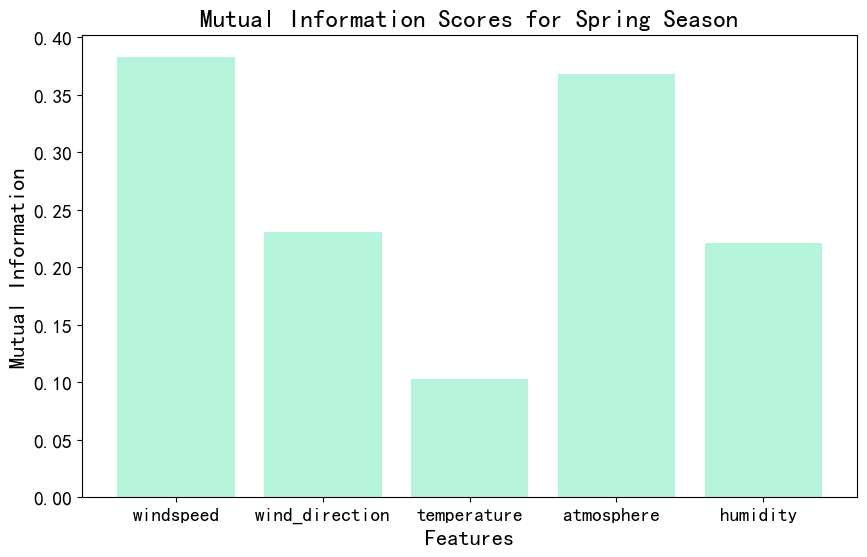

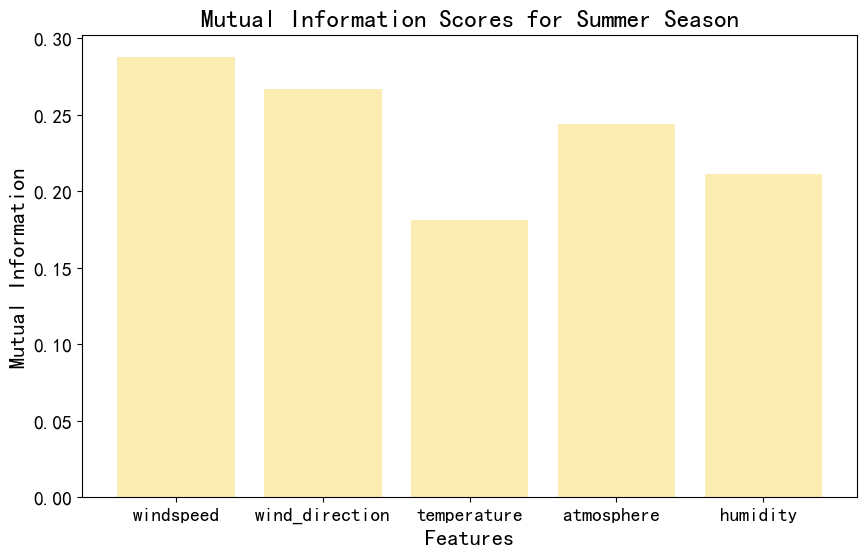

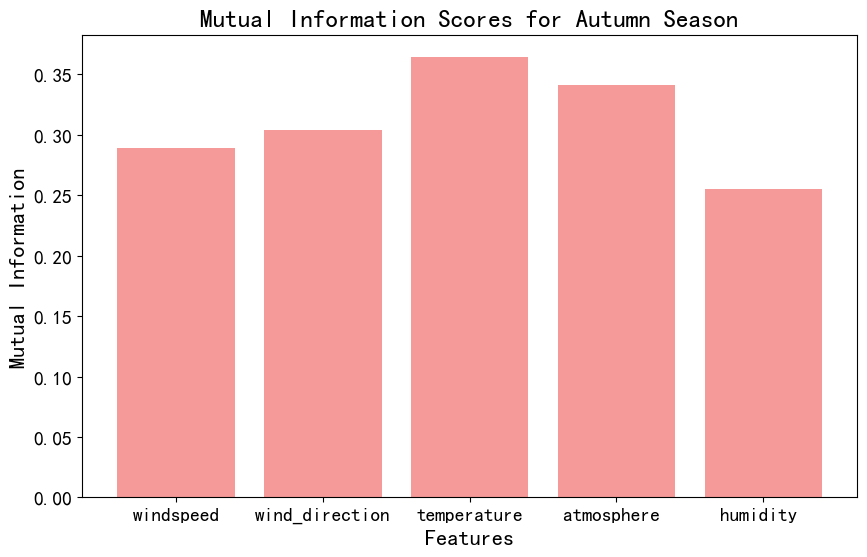

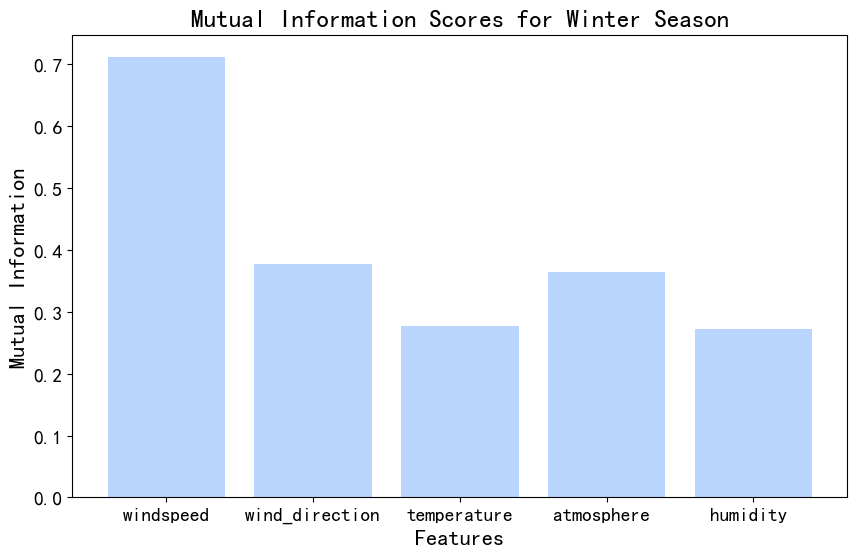

In [36]:
#互信息可视化
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# 定义一个函数来计算互信息并绘制条形图
def plot_mi_scores(df, season_name, color):
    # 分离目标变量和特征
    X = df[['windspeed', 'wind_direction', 'temperature', 'atmosphere ','humidity ']]
    y = df[ 'power ']
    
    # 计算每个特征与目标变量之间的互信息
    mi_scores = mutual_info_regression(X, y)
    
    # 将互信息分数转换为数据框，以便更好地查看和分析
    mi_df = pd.DataFrame(mi_scores, index=X.columns, columns=[f'MI_{season_name}'])
    
    # 可视化互信息分数
    plt.figure(figsize=(10, 6))  # 设置图形大小
    plt.bar(mi_df.index, mi_df[f'MI_{season_name}'], color=color)
    plt.xlabel('Features', fontsize=16)
    plt.ylabel('Mutual Information', fontsize=16)
    plt.title(f'Mutual Information Scores for {season_name} Season', fontsize=18)
    # 放大坐标轴刻度字体
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    # ================== 只有春天保存高清图 ==================
    if season_name == "Spring":
        plt.savefig("风电场1互信息.png", dpi=500, bbox_inches='tight')
    
    plt.show()

ct="#B5F4DA"
xt="#FBECB4"
qt="#F69999"
dt="#B9D5FD"

# 为每个季节调用函数并指定不同的配色
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
colors = [ct, xt, qt, dt]

for season, color in zip(seasons, colors):
    plot_mi_scores(eval(f'{season.lower()}_df'), season, color)


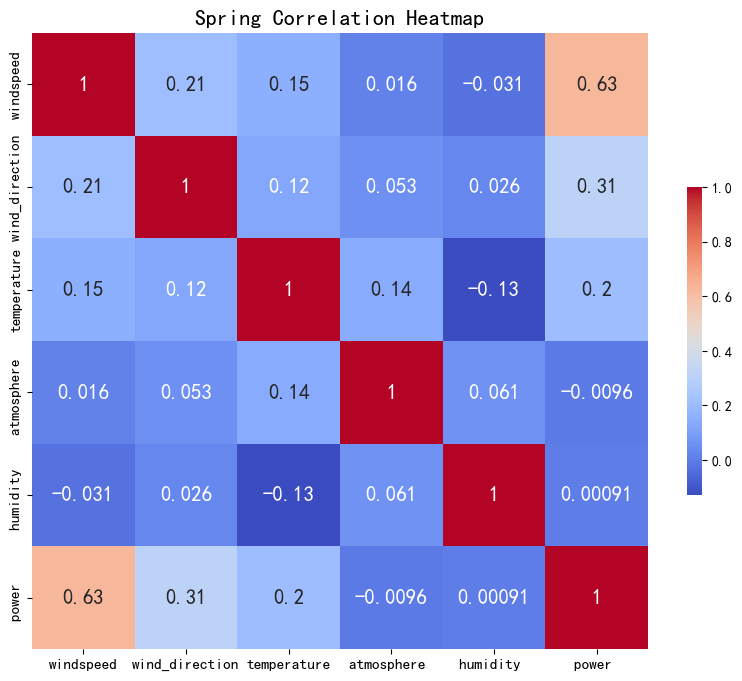

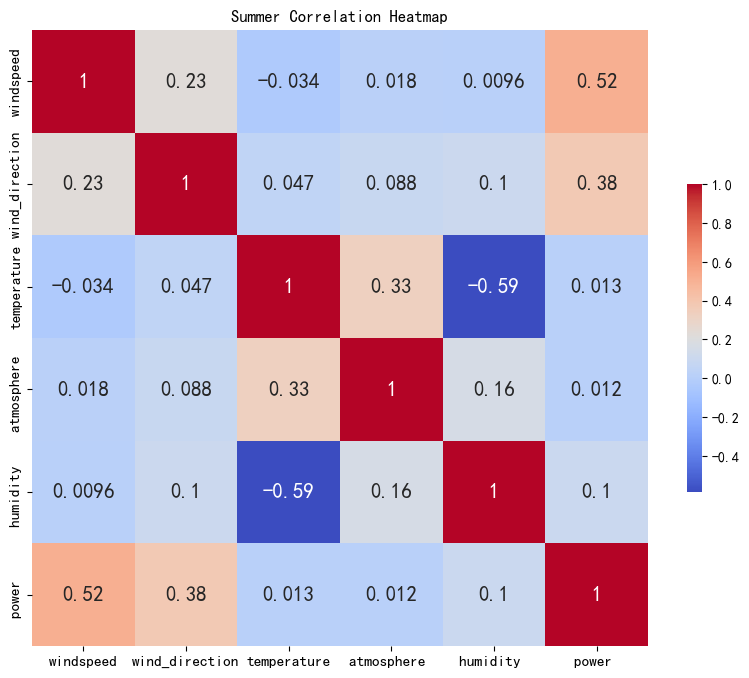

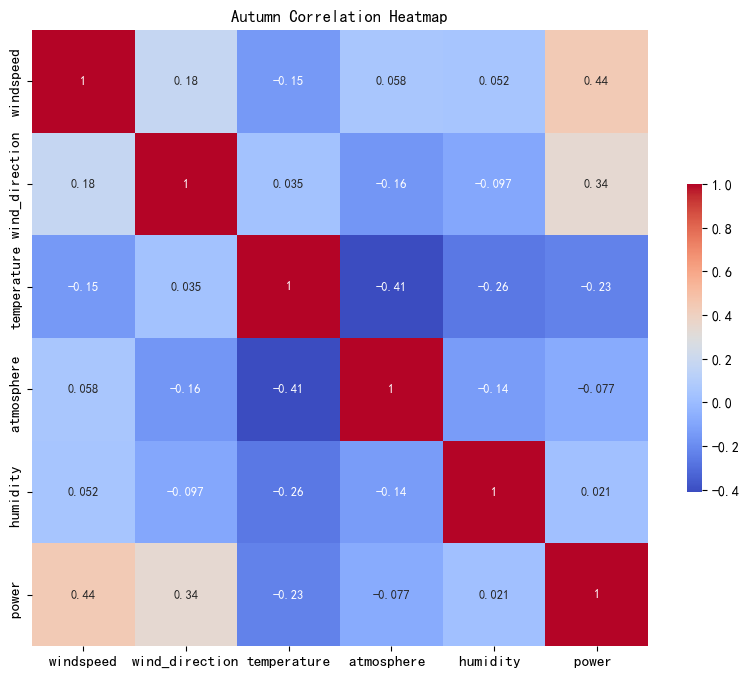

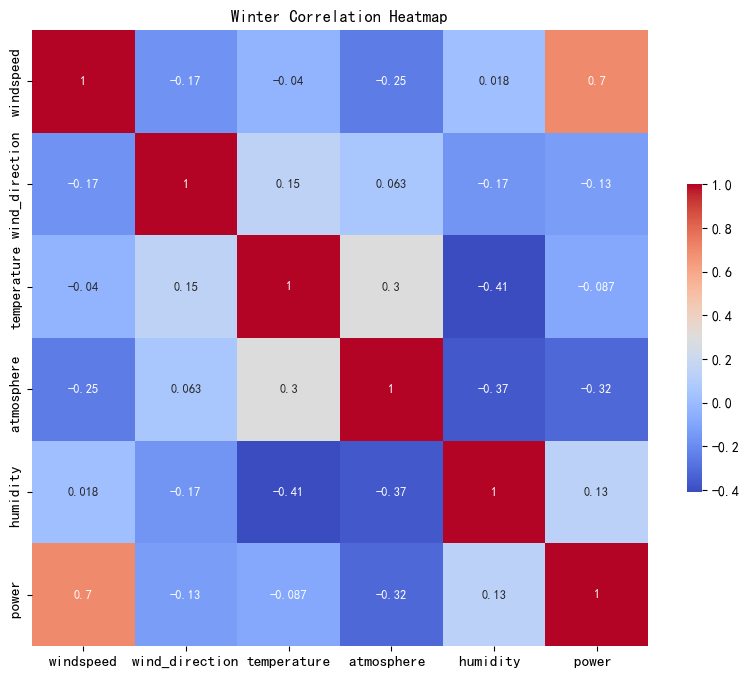

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# 计算相关系数
spring_corr = spring_df.corr()
summer_corr = summer_df.corr()
autumn_corr = autumn_df.corr()
winter_corr = winter_df.corr()

# 春天 —— 显示 + 300dpi 高清保存
plt.figure(figsize=(10, 8))
sns.heatmap(spring_corr, annot=True, annot_kws={"size":15}, cmap='coolwarm', vmax=1, square=True, cbar_kws={"shrink": .5})
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title('Spring Correlation Heatmap', fontsize=16)
plt.savefig("风电场1相关系数.png", dpi=500, bbox_inches='tight')
plt.show()

# 夏天 —— 只显示
plt.figure(figsize=(10, 8))
sns.heatmap(summer_corr, annot=True, annot_kws={"size": 15}, cmap='coolwarm', vmax=1, square=True, cbar_kws={"shrink": .5})
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title('Summer Correlation Heatmap')
plt.show()

# 秋天 —— 只显示
plt.figure(figsize=(10, 8))
sns.heatmap(autumn_corr, annot=True, annot_kws={"size": 9}, cmap='coolwarm', vmax=1, square=True, cbar_kws={"shrink": .5})
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title('Autumn Correlation Heatmap')
plt.show()

# 冬天 —— 只显示
plt.figure(figsize=(10, 8))
sns.heatmap(winter_corr, annot=True, annot_kws={"size": 9}, cmap='coolwarm', vmax=1, square=True, cbar_kws={"shrink": .5})
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title('Winter Correlation Heatmap')
plt.show()


Feature importances for spring:
          Feature  Importance
0       windspeed    0.452912
3     atmosphere     0.225341
4       humidity     0.155086
1  wind_direction    0.141298
2     temperature    0.025363


Feature importances for summer:
          Feature  Importance
0       windspeed    0.383454
1  wind_direction    0.188734
3     atmosphere     0.187971
4       humidity     0.129270
2     temperature    0.110571


Feature importances for autumn:
          Feature  Importance
0       windspeed    0.364755
1  wind_direction    0.202821
2     temperature    0.163144
3     atmosphere     0.151749
4       humidity     0.117531


Feature importances for winter:
          Feature  Importance
0       windspeed    0.722751
1  wind_direction    0.101890
3     atmosphere     0.077537
4       humidity     0.050942
2     temperature    0.046880




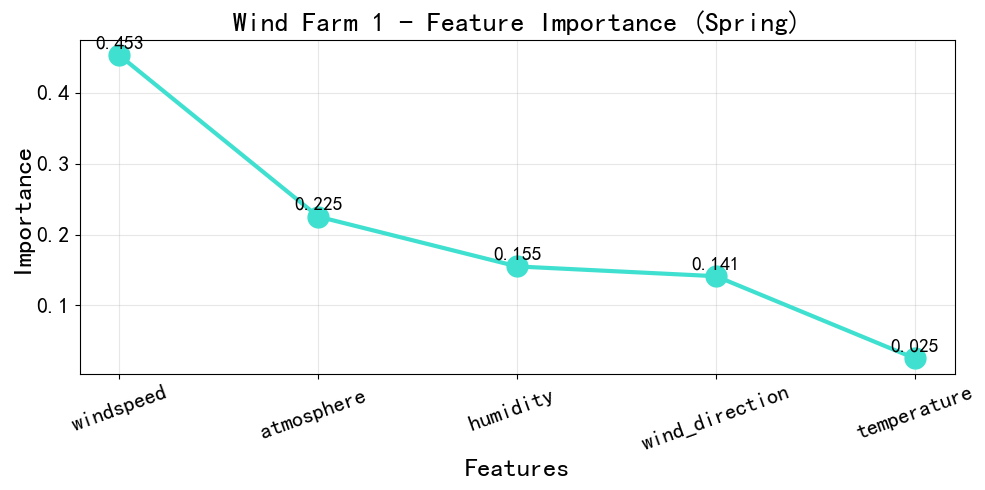

In [35]:
# 特征重要性 + 春天青绿色折线图（带数据标签）
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

seasons = ['spring', 'summer', 'autumn', 'winter']
season_dfs = [spring_df, summer_df, autumn_df, winter_df]

all_importances = {}

for season, df in zip(seasons, season_dfs):
    features = df.iloc[:, :-1]
    target = df.iloc[:, -1]

    x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(x_train, y_train)

    importances = rf.feature_importances_

    feature_importances = pd.DataFrame({
        'Feature': x_train.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    all_importances[season] = feature_importances

    print(f"Feature importances for {season}:")
    print(feature_importances)
    print("\n")

# ===================== 春天：青绿色折线图 + 数据标签 =====================
spring_data = all_importances['spring']
features = spring_data['Feature']
scores = spring_data['Importance']

plt.figure(figsize=(10, 5))

# 青绿色折线
plt.plot(features, scores, color='#40E0D0', linewidth=3, marker='o', markersize=15)

# 数据标签（放大字体）
for f, s in zip(features, scores):
    plt.text(f, s + 0.01, f'{s:.3f}', ha='center', fontsize=14, fontweight='bold')

# 标题、坐标轴标签放大
plt.title('Wind Farm 1 - Feature Importance (Spring)', fontsize=20)
plt.xlabel('Features', fontsize=19)
plt.ylabel('Importance', fontsize=19)

# X/Y轴刻度字体放大
plt.xticks(rotation=20, fontsize=16)
plt.yticks(fontsize=16)

plt.grid(alpha=0.3)
plt.tight_layout()

# 保存 300dpi 高清图
plt.savefig("风电场1特征重要性.png", dpi=500, bbox_inches='tight')
plt.show()

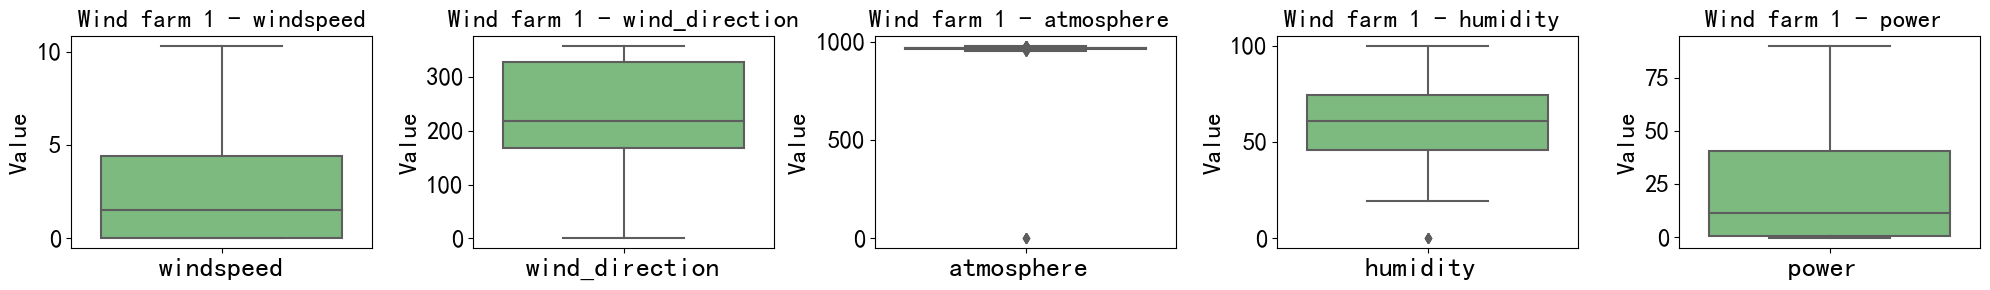

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 定义变量列表
variables = ['windspeed', 'wind_direction', 'atmosphere ','humidity ', 'power ']

# 为每一行定义不同的颜色
palette = 'Greens'  # 只使用一个颜色板，因为我们只展示春天的数据

# 创建一个1行5列的子图布局，因为我们只展示春天的数据
fig, axs = plt.subplots(1, 5, figsize=(20, 3))
axs = axs.flatten()

# 绘制箱型图
for j, variable in enumerate(variables):
    sns.boxplot(data=spring_df[[variable]], ax=axs[j], palette=palette)
    # 子标题放大
    axs[j].set_title(f'Wind farm 1 - {variable}', fontsize=18)
    # X/Y轴标签放大
    axs[j].set_ylabel('Value', fontsize=18)
    axs[j].set_xlabel('')
    # 坐标轴刻度字体放大
    axs[j].tick_params(axis='x', labelsize=20)
    axs[j].tick_params(axis='y', labelsize=18)

# 调整子图之间的间距
plt.tight_layout()

# 保存高清图片
plt.savefig("风电场1箱线图.png", dpi=500, bbox_inches='tight')

# 显示图片
plt.show()


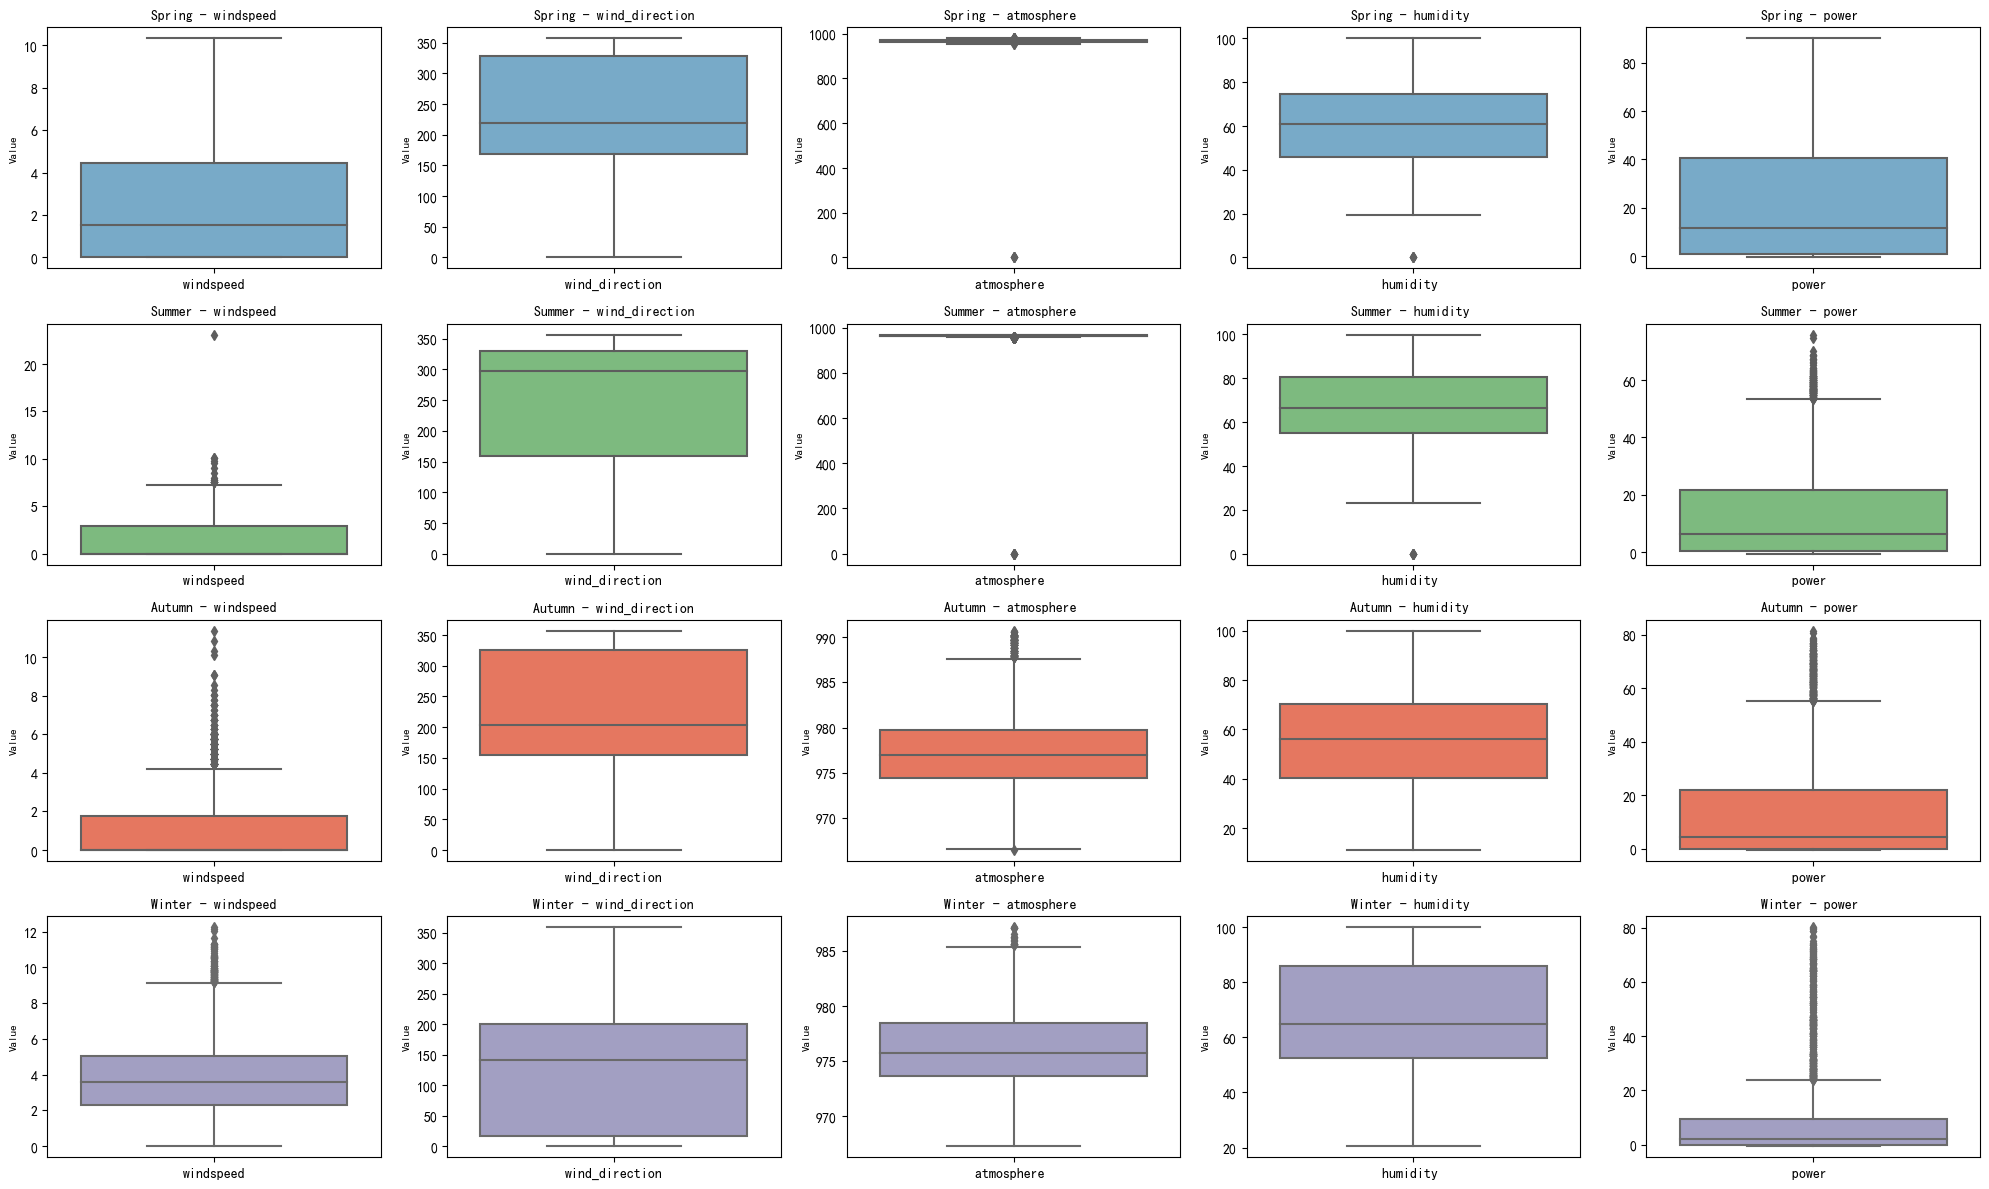

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
# 定义变量列表
variables = ['windspeed', 'wind_direction', 'atmosphere ','humidity ', 'power ']
# 为每一行定义不同的颜色
palettes = ['Blues', 'Greens', 'Reds', 'Purples']

# 创建一个4行6列的子图布局
fig, axs = plt.subplots(4, 5, figsize=(20, 12))  # 调整图形大小以适应4x6布局
axs = axs.flatten()  # 将2D子图数组转换为1D，以便迭代

# 定义季节列表
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']

# 绘制箱型图
for i, season_df in enumerate([spring_df, summer_df, autumn_df, winter_df]):
    for j, variable in enumerate(variables):
        sns.boxplot(data=season_df[[variable]], ax=axs[i*5 + j], palette=palettes[i])
        axs[i*5 + j].set_title(f'{seasons[i]} - {variable}', fontsize=10)
        axs[i*5 + j].set_ylabel('Value', fontsize=8)
        axs[i*5 + j].set_xlabel('')

# 调整子图之间的间距
plt.tight_layout()
plt.show()

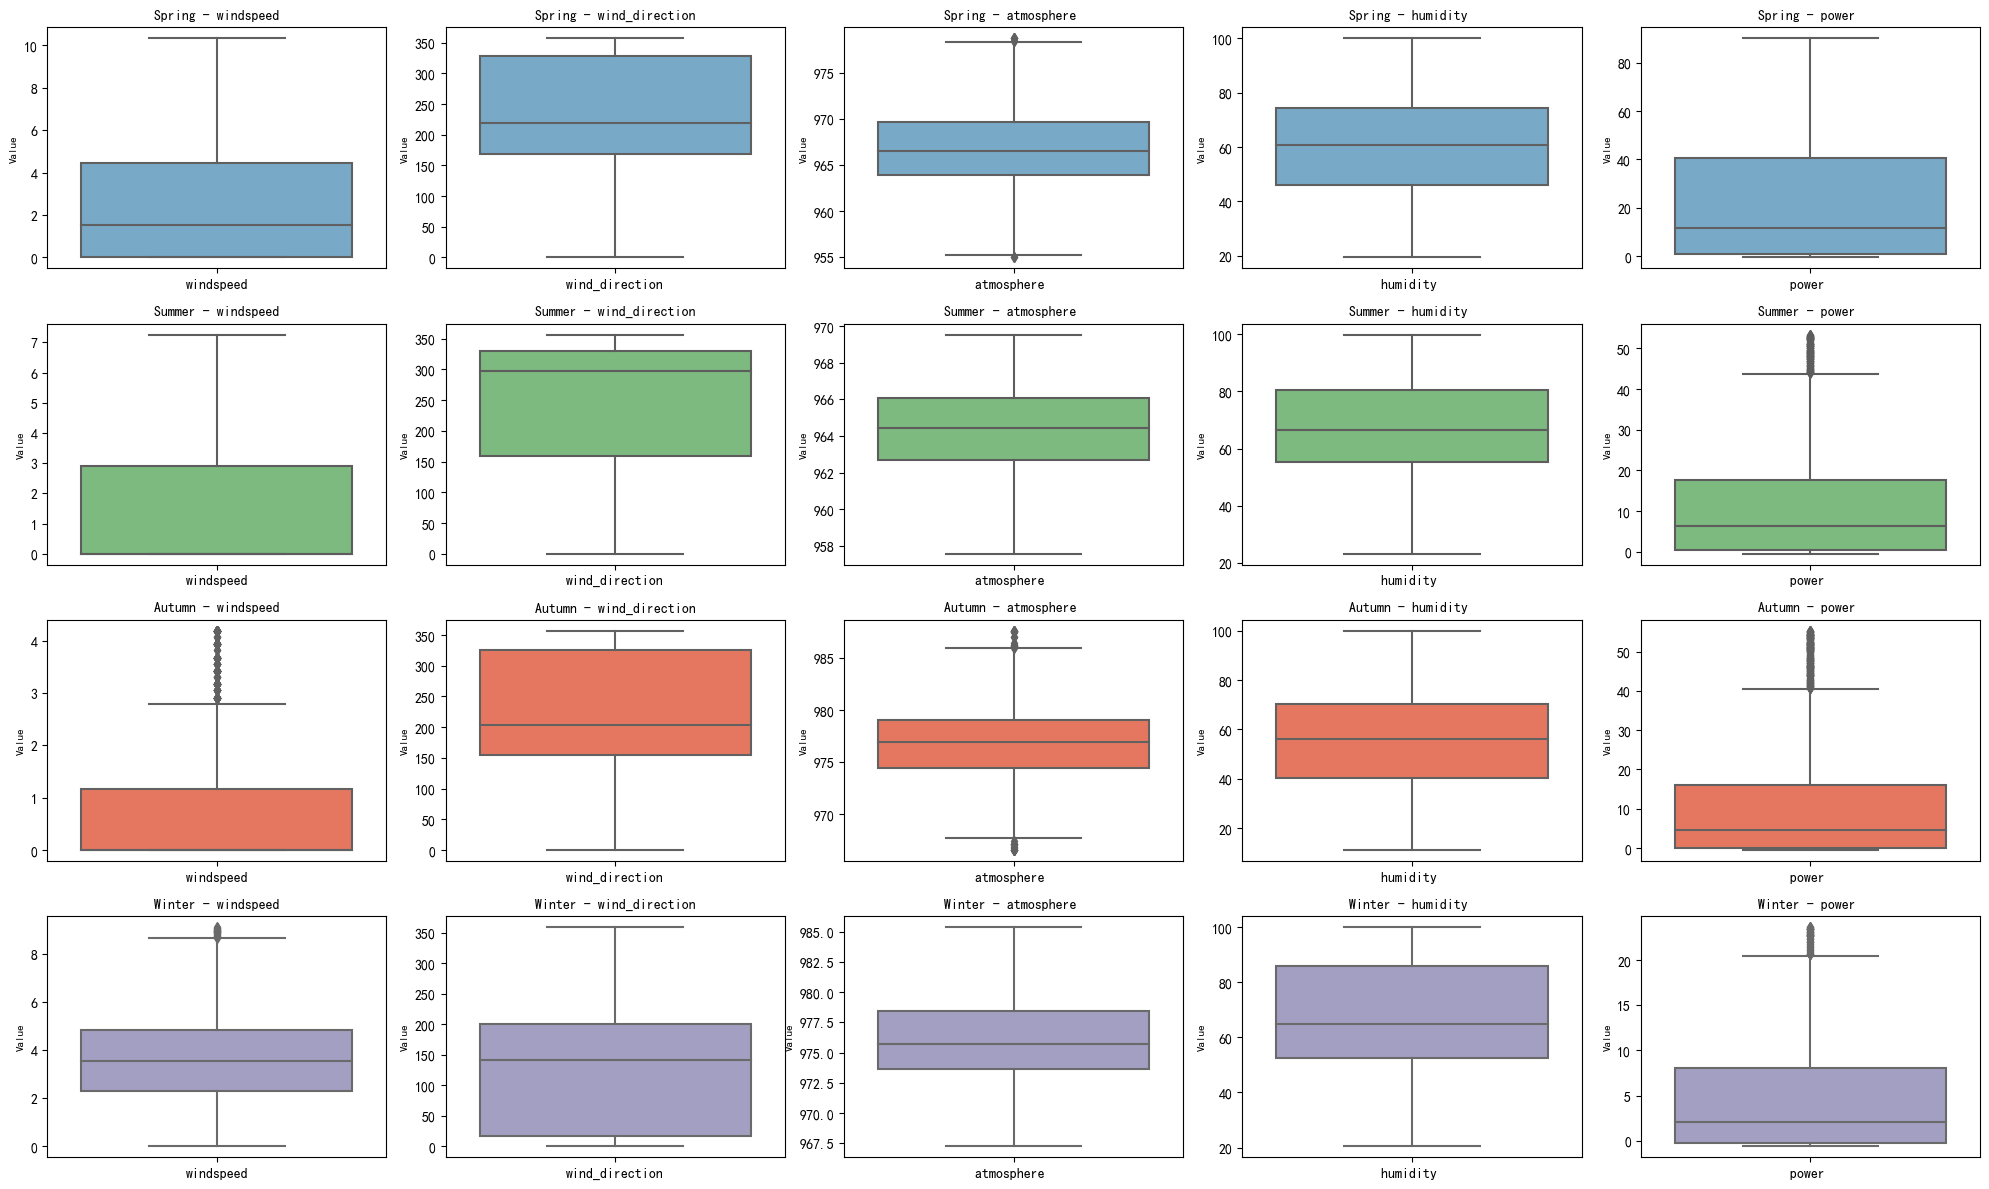

Corrected Spring Data:
   windspeed  wind_direction  temperature  atmosphere   humidity    power 
0    1.26267       342.57900        26.46      973.217    19.3956  43.2519
1    4.96200       322.46400        26.46      973.068    20.3517  42.9045
2    4.45067         6.72918        26.46      972.795    20.5566  35.8769
3    3.68367         1.46286        26.46      972.807    20.4883  28.7459
4    2.54100       346.11400        26.46      972.797    21.5810  30.7079

Corrected Summer Data:
      windspeed  wind_direction  temperature  atmosphere   humidity     power 
2879    3.68367         164.509        17.09      967.130    25.2517  17.60590
2880    5.47333         236.702        25.80      963.686    49.2926  18.04930
2881    0.00000         231.688        25.99      963.573    49.0881  19.13560
2882    1.89400         240.474        25.94      963.870    48.8836   6.42903
2883    0.00000         236.604        26.01      963.870    48.5427   1.44838

Corrected Autumn Data:
     

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 定义变量列表
variables =['windspeed', 'wind_direction', 'atmosphere ','humidity ', 'power ']
# 为每一行定义不同的颜色
palettes = ['Blues', 'Greens', 'Reds', 'Purples']

# 创建一个4行6列的子图布局
fig, axs = plt.subplots(4, 5, figsize=(20, 12))
axs = axs.flatten()

# 定义季节列表
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']

# 函数：用均值替换异常值
def replace_outliers_with_mean(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # 计算均值
    mean_value = df[column].mean()
    # 替换异常值为均值
    df[column] = np.where((df[column] < lower_bound) | (df[column] > upper_bound), mean_value, df[column])
    return df

# 对每个季节的数据框进行异常值校正
corrected_spring_df = spring_df.copy()
corrected_summer_df = summer_df.copy()
corrected_autumn_df = autumn_df.copy()
corrected_winter_df = winter_df.copy()

for i, season_df in enumerate([corrected_spring_df, corrected_summer_df, corrected_autumn_df, corrected_winter_df]):
    for variable in variables:
        season_df = replace_outliers_with_mean(season_df, variable)

# 绘制箱型图
for i, season_df in enumerate([corrected_spring_df, corrected_summer_df, corrected_autumn_df, corrected_winter_df]):
    for j, variable in enumerate(variables):
        sns.boxplot(data=season_df[[variable]], ax=axs[i*5 + j], palette=palettes[i])
        axs[i*5 + j].set_title(f'{seasons[i]} - {variable}', fontsize=10)
        axs[i*5 + j].set_ylabel('Value', fontsize=8)
        axs[i*5 + j].set_xlabel('')

# 调整子图之间的间距
plt.tight_layout()
plt.show()

# 输出校正后的四季数据序列
print("Corrected Spring Data:")
print(corrected_spring_df.head())
print("\nCorrected Summer Data:")
print(corrected_summer_df.head())
print("\nCorrected Autumn Data:")
print(corrected_autumn_df.head())
print("\nCorrected Winter Data:")
print(corrected_winter_df.head())

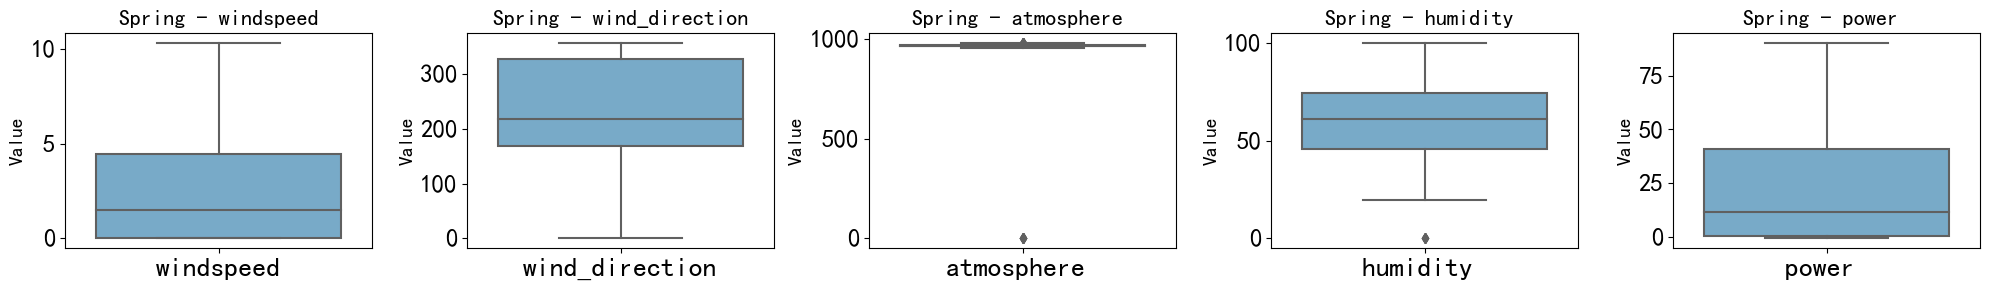

Corrected Spring Data:
   windspeed  wind_direction  temperature  atmosphere   humidity    power 
0    1.26267       342.57900        26.46      973.217    19.3956  43.2519
1    4.96200       322.46400        26.46      973.068    20.3517  42.9045
2    4.45067         6.72918        26.46      972.795    20.5566  35.8769
3    3.68367         1.46286        26.46      972.807    20.4883  28.7459
4    2.54100       346.11400        26.46      972.797    21.5810  30.7079


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 定义变量列表
variables = ['windspeed', 'wind_direction', 'atmosphere ', 'humidity ', 'power ']
# 为春季定义颜色
palette = 'Blues'

# 创建一个1行5列的子图布局
fig, axs = plt.subplots(1, 5, figsize=(20, 3))  # 修改为1行5列
axs = axs.flatten()

# 定义季节列表
season = 'Spring'

# 函数：用最大最小值替换异常值
def replace_outliers_with_extremes(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # 计算最大值和最小值
    min_value = df[column].min()
    max_value = df[column].max()
    # 替换异常值为最大值或最小值
    df[column] = np.where(df[column] < lower_bound, min_value, df[column])
    df[column] = np.where(df[column] > upper_bound, max_value, df[column])
    return df

# 假设你已经有了春季的数据框：spring_df
# 对春季的数据框进行异常值校正
corrected_spring_df = spring_df.copy()
for variable in variables:
    corrected_spring_df = replace_outliers_with_extremes(corrected_spring_df, variable)

# 绘制箱型图
for j, variable in enumerate(variables):
    sns.boxplot(data=corrected_spring_df[[variable]], ax=axs[j], palette=palette)
    # 子标题字体放大
    axs[j].set_title(f'{season} - {variable}', fontsize=16)
    # Y轴标签放大
    axs[j].set_ylabel('Value', fontsize=14)
    axs[j].set_xlabel('')
    # X、Y轴刻度字体全部放大
    axs[j].tick_params(axis='x', labelsize=20)
    axs[j].tick_params(axis='y', labelsize=18)

# 调整子图之间的间距
plt.tight_layout()

# ================== 保存高清图片 ==================
plt.savefig("风电场1修正箱线图.png", dpi=500, bbox_inches='tight')

plt.show()

# 输出校正后的春季数据序列
print("Corrected Spring Data:")
print(corrected_spring_df.head())


In [22]:
# 删除四季数据框中的温度列
spring_data = corrected_spring_df.drop('temperature', axis=1)
summer_data = corrected_summer_df.drop('temperature', axis=1)
autumn_data = corrected_autumn_df.drop('temperature', axis=1)
winter_data = corrected_winter_df.drop('temperature', axis=1)
winter_data

,windspeed,wind_direction,atmosphere,humidity,power
8832,3.812303,153.1,979.319,48.4952,8.035522
8833,3.812303,157.0,979.022,48.3926,8.035522
8834,3.812303,154.2,979.022,49.3844,8.035522
8835,3.812303,152.8,978.423,50.5472,8.035522
8836,3.812303,151.6,978.724,49.2476,8.035522
...,...,...,...,...,...
11803,6.924000,168.6,975.557,53.9028,18.725500
11804,6.234000,170.7,975.505,54.0395,18.570300
11805,6.537000,166.2,975.461,54.9988,18.899100
11806,6.840000,167.5,975.330,55.5784,20.148000


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
# 函数：划分数据集
def split_data(df, target_column):
    # 分离特征和目标变量
    X = df.drop(target_column, axis=1)
    y = df[target_column]
    
    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=False)
    
    # 从训练集中进一步划分出验证集
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42,shuffle=False)
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# 假设 'target' 是目标变量的列名
target_column = 'power '

# 对每个季节的数据进行划分
spring_X_train, spring_X_val, spring_X_test, spring_y_train, spring_y_val, spring_y_test = split_data(spring_data, target_column)
summer_X_train, summer_X_val, summer_X_test, summer_y_train, summer_y_val, summer_y_test = split_data(summer_data, target_column)
autumn_X_train, autumn_X_val, autumn_X_test, autumn_y_train, autumn_y_val, autumn_y_test = split_data(autumn_data, target_column)
winter_X_train, winter_X_val, winter_X_test, winter_y_train, winter_y_val, winter_y_test = split_data(winter_data, target_column)
print(f"Spring DataFrame size: {spring_X_train.shape}")
print(f"Summer DataFrame size: {summer_X_train.shape}")
print(f"Autumn DataFrame size: {autumn_X_train.shape}")
print(f"Winter DataFrame size: {winter_X_train.shape}")
print(spring_X_train,winter_y_train)

Spring DataFrame size: (1727, 4)
Summer DataFrame size: (1785, 4)
Autumn DataFrame size: (1785, 4)
Winter DataFrame size: (1785, 4)
      windspeed  wind_direction  atmosphere   humidity 
0      1.262670       342.57900      973.217    19.3956
1      4.962000       322.46400      973.068    20.3517
2      4.450670         6.72918      972.795    20.5566
3      3.683670         1.46286      972.807    20.4883
4      2.541000       346.11400      972.797    21.5810
...         ...             ...          ...        ...
1722   0.375667       251.86900      966.534    31.1940
1723   0.000000       202.06400      966.534    29.9317
1724   0.375667       208.05600      966.534    30.3068
1725   0.631333       197.11800      966.534    31.2287
1726   0.000000       263.86300      966.534    27.6109

[1727 rows x 4 columns] 8832     8.035522
8833     8.035522
8834     8.035522
8835     8.035522
8836     8.035522
           ...   
10612   -0.317757
10613   -0.269724
10614   -0.251249
10615   -

In [15]:
from sklearn.preprocessing import MinMaxScaler

# 对每个季节的X特征进行归一化，为每个季节创建独立的MinMaxScaler实例
scaler_spring_X = MinMaxScaler()
scaler_summer_X = MinMaxScaler()
scaler_autumn_X = MinMaxScaler()
scaler_winter_X = MinMaxScaler()

# 对每个季节的y目标变量进行归一化，为每个季节创建独立的MinMaxScaler实例
scaler_spring_y = MinMaxScaler()
scaler_summer_y = MinMaxScaler()
scaler_autumn_y = MinMaxScaler()
scaler_winter_y = MinMaxScaler()

# 对每个季节的训练集特征进行归一化
spring_X_train_scaled = scaler_spring_X.fit_transform(spring_X_train)
summer_X_train_scaled = scaler_summer_X.fit_transform(summer_X_train)
autumn_X_train_scaled = scaler_autumn_X.fit_transform(autumn_X_train)
winter_X_train_scaled = scaler_winter_X.fit_transform(winter_X_train)

# 对训练集目标变量进行归一化
spring_y_train_scaled = scaler_spring_y.fit_transform(spring_y_train.values.reshape(-1, 1))
summer_y_train_scaled = scaler_summer_y.fit_transform(summer_y_train.values.reshape(-1, 1))
autumn_y_train_scaled = scaler_autumn_y.fit_transform(autumn_y_train.values.reshape(-1, 1))
winter_y_train_scaled = scaler_winter_y.fit_transform(winter_y_train.values.reshape(-1, 1))

# 对验证集和测试集特征进行归一化，使用训练集的参数
spring_X_val_scaled = scaler_spring_X.transform(spring_X_val)
spring_X_test_scaled = scaler_spring_X.transform(spring_X_test)
summer_X_val_scaled = scaler_summer_X.transform(summer_X_val)
summer_X_test_scaled = scaler_summer_X.transform(summer_X_test)
autumn_X_val_scaled = scaler_autumn_X.transform(autumn_X_val)
autumn_X_test_scaled = scaler_autumn_X.transform(autumn_X_test)
winter_X_val_scaled = scaler_winter_X.transform(winter_X_val)
winter_X_test_scaled = scaler_winter_X.transform(winter_X_test)

# 对验证集和测试集目标变量进行归一化，使用训练集的参数
spring_y_val_scaled = scaler_spring_y.transform(spring_y_val.values.reshape(-1, 1))
spring_y_test_scaled = scaler_spring_y.transform(spring_y_test.values.reshape(-1, 1))
summer_y_val_scaled = scaler_summer_y.transform(summer_y_val.values.reshape(-1, 1))
summer_y_test_scaled = scaler_summer_y.transform(summer_y_test.values.reshape(-1, 1))
autumn_y_val_scaled = scaler_autumn_y.transform(autumn_y_val.values.reshape(-1, 1))
autumn_y_test_scaled = scaler_autumn_y.transform(autumn_y_test.values.reshape(-1, 1))
winter_y_val_scaled = scaler_winter_y.transform(winter_y_val.values.reshape(-1, 1))
winter_y_test_scaled = scaler_winter_y.transform(winter_y_test.values.reshape(-1, 1))

In [16]:
#相空间重构
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()# input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]# forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]# put it all together
    agg = concat(cols, axis=1)
    agg.columns = names# drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg

In [17]:
import numpy as np
import pandas as pd
seasonal_data = {
    'spring': {
        'train': spring_X_train_scaled,
        'val': spring_X_val_scaled,
        'test': spring_X_test_scaled
    },
    'summer': {
        'train': summer_X_train_scaled,
        'val': summer_X_val_scaled,
        'test': summer_X_test_scaled
    },
    'autumn': {
        'train': autumn_X_train_scaled,
        'val': autumn_X_val_scaled,
        'test': autumn_X_test_scaled
    },
    'winter': {
        'train': winter_X_train_scaled,
        'val': winter_X_val_scaled,
        'test': winter_X_test_scaled
    }
}

# 定义每个季节的输入时间步长（n_in）和输出时间步长（n_out）
seasonal_n_steps = {
    'spring': (21, 1),
    'summer': (19, 1),
    'autumn': (28, 1),
    'winter': (24, 1)
}

# 初始化一个字典来存储所有重构数据
all_reconstructed_data = {}

# 遍历每个季节
for season, datasets in seasonal_data.items():
    # 初始化一个字典来存储当前季节的重构数据
    all_reconstructed_data[season] = {}
    
    # 获取当前季节的n_in和n_out
    n_in, n_out = seasonal_n_steps[season]
    
    # 遍历每个数据集（训练集、验证集、测试集）
    for dataset_name, data in datasets.items():
        # 初始化一个字典来存储当前数据集的重构数据
        all_reconstructed_data[season][dataset_name] = {}
        
        # 遍历当前数据集的每一列
        for i in range(data.shape[1]):
            # 提取第 i 列的数据
            column_data = data[:, i].reshape(-1, 1)  # 重塑为二维数组
            
            # 使用 series_to_supervised 函数对每一列进行处理
            reconstructed_column = series_to_supervised(column_data, n_in=n_in, n_out=n_out)
            
            # 将重构后的数据存储在字典中
            all_reconstructed_data[season][dataset_name][f'feature_{i}'] = reconstructed_column

# 现在 all_reconstructed_data 字典中包含了所有数据集的重构数据
# 例如，访问春季训练集的第一列重构后的数据：
summer_train_feature_0_shape = all_reconstructed_data['summer']['train']['feature_0'].shape
print(summer_train_feature_0_shape)

(1766, 20)


In [18]:
#提炼出x_spring_train
X_st1=all_reconstructed_data['spring']['train']['feature_0']
X_st2=all_reconstructed_data['spring']['train']['feature_1']
X_st3=all_reconstructed_data['spring']['train']['feature_2']
X_st4=all_reconstructed_data['spring']['train']['feature_3']
y_st=series_to_supervised(spring_y_train_scaled,21)
y_st1=y_st.iloc[:, :20]
y_spring_train=y_st.iloc[:, -1:]
x_spring_train = pd.concat([X_st1, X_st2, X_st3, X_st4,y_st1], axis=1)

#提炼出x_spring_val
X_sv1=all_reconstructed_data['spring']['val']['feature_0']
X_sv2=all_reconstructed_data['spring']['val']['feature_1']
X_sv3=all_reconstructed_data['spring']['val']['feature_2']
X_sv4=all_reconstructed_data['spring']['val']['feature_3']
y_sv=series_to_supervised(spring_y_val_scaled,21)
y_sv1=y_sv.iloc[:, :20]
x_spring_val = pd.concat([X_sv1, X_sv2, X_sv3, X_sv4,y_sv1], axis=1)
y_spring_val=y_sv.iloc[:, -1:]

#提炼出x_spring_test
X_se1=all_reconstructed_data['spring']['test']['feature_0']
X_se2=all_reconstructed_data['spring']['test']['feature_1']
X_se3=all_reconstructed_data['spring']['test']['feature_2']
X_se4=all_reconstructed_data['spring']['test']['feature_3']
y_se=series_to_supervised(spring_y_test_scaled,21)
y_se1=y_se.iloc[:, :20]
x_spring_test = pd.concat([X_se1, X_se2, X_se3, X_se4,y_se1], axis=1)
y_spring_test=y_se.iloc[:, -1:]
x_spring_train

,var1(t-21),var1(t-20),var1(t-19),var1(t-18),var1(t-17),var1(t-16),var1(t-15),var1(t-14),var1(t-13),var1(t-12),...,var1(t-11),var1(t-10),var1(t-9),var1(t-8),var1(t-7),var1(t-6),var1(t-5),var1(t-4),var1(t-3),var1(t-2)
21,0.122221,0.480302,0.430807,0.356565,0.245959,0.529797,0.480302,0.036363,0.579292,0.480302,...,0.519750,0.533697,0.538418,0.583577,0.519954,0.525614,0.460234,0.409134,0.364446,0.351048
22,0.480302,0.430807,0.356565,0.245959,0.529797,0.480302,0.036363,0.579292,0.480302,0.529797,...,0.533697,0.538418,0.583577,0.519954,0.525614,0.460234,0.409134,0.364446,0.351048,0.316286
23,0.430807,0.356565,0.245959,0.529797,0.480302,0.036363,0.579292,0.480302,0.529797,0.455554,...,0.538418,0.583577,0.519954,0.525614,0.460234,0.409134,0.364446,0.351048,0.316286,0.304236
24,0.356565,0.245959,0.529797,0.480302,0.036363,0.579292,0.480302,0.529797,0.455554,0.529797,...,0.583577,0.519954,0.525614,0.460234,0.409134,0.364446,0.351048,0.316286,0.304236,0.295617
25,0.245959,0.529797,0.480302,0.036363,0.579292,0.480302,0.529797,0.455554,0.529797,0.072726,...,0.519954,0.525614,0.460234,0.409134,0.364446,0.351048,0.316286,0.304236,0.295617,0.317634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1722,0.356565,0.282322,0.505050,0.554545,0.406059,0.480302,0.232826,0.554545,0.579292,0.221211,...,0.163677,0.150117,0.115354,0.074915,0.057187,0.048895,0.043217,0.039541,0.017769,0.022630
1723,0.282322,0.505050,0.554545,0.406059,0.480302,0.232826,0.554545,0.579292,0.221211,0.171716,...,0.150117,0.115354,0.074915,0.057187,0.048895,0.043217,0.039541,0.017769,0.022630,0.033414
1724,0.505050,0.554545,0.406059,0.480302,0.232826,0.554545,0.579292,0.221211,0.171716,0.369696,...,0.115354,0.074915,0.057187,0.048895,0.043217,0.039541,0.017769,0.022630,0.033414,0.009926
1725,0.554545,0.406059,0.480302,0.232826,0.554545,0.579292,0.221211,0.171716,0.369696,0.036363,...,0.074915,0.057187,0.048895,0.043217,0.039541,0.017769,0.022630,0.033414,0.009926,0.008006


In [19]:
#得到夏季数据集
X_ut1=all_reconstructed_data['summer']['train']['feature_0']
X_ut2=all_reconstructed_data['summer']['train']['feature_1']
X_ut3=all_reconstructed_data['summer']['train']['feature_2']
X_ut4=all_reconstructed_data['summer']['train']['feature_3']
y_ut=series_to_supervised(summer_y_train_scaled,19)
y_ut1=y_ut.iloc[:, :18]
x_summer_train = pd.concat([X_ut1, X_ut2, X_ut3, X_ut4,y_ut1], axis=1)
y_summer_train=y_ut.iloc[:, -1:]

#提炼出x_summer_val
X_uv1=all_reconstructed_data['summer']['val']['feature_0']
X_uv2=all_reconstructed_data['summer']['val']['feature_1']
X_uv3=all_reconstructed_data['summer']['val']['feature_2']
X_uv4=all_reconstructed_data['summer']['val']['feature_3']
y_uv=series_to_supervised(summer_y_val_scaled,19)
y_uv1=y_uv.iloc[:, :18]
x_summer_val= pd.concat([X_uv1, X_uv2, X_uv3, X_uv4,y_uv1], axis=1)
y_summer_val=y_uv.iloc[:, -1:]

#提炼出x_summer_test
X_ue1=all_reconstructed_data['summer']['test']['feature_0']
X_ue2=all_reconstructed_data['summer']['test']['feature_1']
X_ue3=all_reconstructed_data['summer']['test']['feature_2']
X_ue4=all_reconstructed_data['summer']['test']['feature_3']
y_ue=series_to_supervised(summer_y_test_scaled,19)
y_ue1=y_ue.iloc[:, :18]
x_summer_test = pd.concat([X_ue1, X_ue2, X_ue3, X_ue4,y_ue1], axis=1)
y_summer_test=y_uv.iloc[:, -1:]
x_summer_test

,var1(t-19),var1(t-18),var1(t-17),var1(t-16),var1(t-15),var1(t-14),var1(t-13),var1(t-12),var1(t-11),var1(t-10),...,var1(t-11),var1(t-10),var1(t-9),var1(t-8),var1(t-7),var1(t-6),var1(t-5),var1(t-4),var1(t-3),var1(t-2)
19,0.000000,0.138648,0.000000,0.086925,0.000000,0.000000,0.542383,0.103447,0.000000,0.455459,...,0.928777,0.925406,0.897584,0.860981,0.960567,0.264602,0.264602,0.264602,0.264602,0.264602
20,0.138648,0.000000,0.086925,0.000000,0.000000,0.542383,0.103447,0.000000,0.455459,0.051723,...,0.925406,0.897584,0.860981,0.960567,0.264602,0.264602,0.264602,0.264602,0.264602,0.971479
21,0.000000,0.086925,0.000000,0.000000,0.542383,0.103447,0.000000,0.455459,0.051723,0.155170,...,0.897584,0.860981,0.960567,0.264602,0.264602,0.264602,0.264602,0.264602,0.971479,0.920718
22,0.086925,0.000000,0.000000,0.542383,0.103447,0.000000,0.455459,0.051723,0.155170,0.051723,...,0.860981,0.960567,0.264602,0.264602,0.264602,0.264602,0.264602,0.971479,0.920718,0.774103
23,0.000000,0.000000,0.542383,0.103447,0.000000,0.455459,0.051723,0.155170,0.051723,0.331176,...,0.960567,0.264602,0.264602,0.264602,0.264602,0.264602,0.971479,0.920718,0.774103,0.761948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,0.209050,0.103447,0.577585,0.436780,0.103447,0.103447,0.823994,0.401579,0.718390,0.577585,...,0.264602,0.264602,0.264602,0.264602,0.264602,0.264602,0.961672,0.797790,0.816023,0.912225
592,0.103447,0.577585,0.436780,0.103447,0.103447,0.823994,0.401579,0.718390,0.577585,0.683189,...,0.264602,0.264602,0.264602,0.264602,0.264602,0.961672,0.797790,0.816023,0.912225,0.859254
593,0.577585,0.436780,0.103447,0.103447,0.823994,0.401579,0.718390,0.577585,0.683189,0.612787,...,0.264602,0.264602,0.264602,0.264602,0.961672,0.797790,0.816023,0.912225,0.859254,0.773028
594,0.436780,0.103447,0.103447,0.823994,0.401579,0.718390,0.577585,0.683189,0.612787,0.051723,...,0.264602,0.264602,0.264602,0.961672,0.797790,0.816023,0.912225,0.859254,0.773028,0.825690


In [20]:
#提炼出x_autumn_train
X_at1=all_reconstructed_data['autumn']['train']['feature_0']
X_at2=all_reconstructed_data['autumn']['train']['feature_1']
X_at3=all_reconstructed_data['autumn']['train']['feature_2']
X_at4=all_reconstructed_data['autumn']['train']['feature_3']
y_at=series_to_supervised(autumn_y_train_scaled,28)
y_at1=y_at.iloc[:, :27]
x_autumn_train = pd.concat([X_at1, X_at2, X_at3, X_at4,y_at1], axis=1)
y_autumn_train=y_at.iloc[:, -1:]

#提炼出x_autumn_val
X_av1=all_reconstructed_data['autumn']['val']['feature_0']
X_av2=all_reconstructed_data['autumn']['val']['feature_1']
X_av3=all_reconstructed_data['autumn']['val']['feature_2']
X_av4=all_reconstructed_data['autumn']['val']['feature_3']
y_av=series_to_supervised(autumn_y_val_scaled,28)
y_av1=y_av.iloc[:, :27]
x_autumn_val = pd.concat([X_av1, X_av2, X_av3, X_av4,y_av1], axis=1)
y_autumn_val=y_av.iloc[:, -1:]

#提炼出x_autumn_test
X_ae1=all_reconstructed_data['autumn']['test']['feature_0']
X_ae2=all_reconstructed_data['autumn']['test']['feature_1']
X_ae3=all_reconstructed_data['autumn']['test']['feature_2']
X_ae4=all_reconstructed_data['autumn']['test']['feature_3']
y_ae=series_to_supervised(autumn_y_test_scaled,28)
y_ae1=y_ae.iloc[:, :27]
x_autumn_test = pd.concat([X_ae1, X_ae2, X_ae3, X_ae4,y_ae1], axis=1)
y_autumn_test=y_ae.iloc[:, -1:]
x_autumn_val

,var1(t-28),var1(t-27),var1(t-26),var1(t-25),var1(t-24),var1(t-23),var1(t-22),var1(t-21),var1(t-20),var1(t-19),...,var1(t-11),var1(t-10),var1(t-9),var1(t-8),var1(t-7),var1(t-6),var1(t-5),var1(t-4),var1(t-3),var1(t-2)
28,0.000000,0.634327,0.000000,0.150497,0.211442,0.089551,0.179102,0.939054,0.240048,0.544775,...,0.973531,0.275486,0.922855,0.931865,0.956470,0.970686,0.275486,0.275486,0.978632,0.839982
29,0.634327,0.000000,0.150497,0.211442,0.089551,0.179102,0.939054,0.240048,0.544775,0.695273,...,0.275486,0.922855,0.931865,0.956470,0.970686,0.275486,0.275486,0.978632,0.839982,0.821897
30,0.000000,0.150497,0.211442,0.089551,0.179102,0.939054,0.240048,0.544775,0.695273,0.878110,...,0.922855,0.931865,0.956470,0.970686,0.275486,0.275486,0.978632,0.839982,0.821897,0.936302
31,0.150497,0.211442,0.089551,0.179102,0.939054,0.240048,0.544775,0.695273,0.878110,0.573380,...,0.931865,0.956470,0.970686,0.275486,0.275486,0.978632,0.839982,0.821897,0.936302,0.935140
32,0.211442,0.089551,0.179102,0.939054,0.240048,0.544775,0.695273,0.878110,0.573380,0.000000,...,0.956470,0.970686,0.275486,0.275486,0.978632,0.839982,0.821897,0.936302,0.935140,0.913713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590,0.277079,0.277079,0.277079,0.277079,0.277079,1.000000,0.277079,0.277079,0.211442,0.277079,...,0.723817,0.641398,0.625350,0.601171,0.470470,0.419461,0.292470,0.321816,0.298499,0.258421
591,0.277079,0.277079,0.277079,0.277079,1.000000,0.277079,0.277079,0.211442,0.277079,0.277079,...,0.641398,0.625350,0.601171,0.470470,0.419461,0.292470,0.321816,0.298499,0.258421,0.266371
592,0.277079,0.277079,0.277079,1.000000,0.277079,0.277079,0.211442,0.277079,0.277079,0.333333,...,0.625350,0.601171,0.470470,0.419461,0.292470,0.321816,0.298499,0.258421,0.266371,0.240998
593,0.277079,0.277079,1.000000,0.277079,0.277079,0.211442,0.277079,0.277079,0.333333,0.089551,...,0.601171,0.470470,0.419461,0.292470,0.321816,0.298499,0.258421,0.266371,0.240998,0.187870


In [21]:
#提炼出x_winter_train
X_wt1=all_reconstructed_data['winter']['train']['feature_0']
X_wt2=all_reconstructed_data['winter']['train']['feature_1']
X_wt3=all_reconstructed_data['winter']['train']['feature_2']
X_wt4=all_reconstructed_data['winter']['train']['feature_3']
y_wt=series_to_supervised(winter_y_train_scaled,24)
y_wt1=y_wt.iloc[:, :23]
x_winter_train = pd.concat([X_wt1, X_wt2, X_wt3, X_wt4,y_wt1], axis=1)
y_winter_train=y_wt.iloc[:, -1:]

#提炼出x_winter_val
X_wv1=all_reconstructed_data['winter']['val']['feature_0']
X_wv2=all_reconstructed_data['winter']['val']['feature_1']
X_wv3=all_reconstructed_data['winter']['val']['feature_2']
X_wv4=all_reconstructed_data['winter']['val']['feature_3']
y_wv=series_to_supervised(winter_y_val_scaled,24)
y_wv1=y_wv.iloc[:, :23]
x_winter_val = pd.concat([X_wv1, X_wv2, X_wv3, X_wv4,y_wv1], axis=1)
y_winter_val=y_wt.iloc[:, -1:]

#提炼出x_winter_test
X_we1=all_reconstructed_data['winter']['test']['feature_0']
X_we2=all_reconstructed_data['winter']['test']['feature_1']
X_we3=all_reconstructed_data['winter']['test']['feature_2']
X_we4=all_reconstructed_data['winter']['test']['feature_3']
y_we=series_to_supervised(winter_y_test_scaled,24)
y_we1=y_we.iloc[:, :23]
x_winter_test = pd.concat([X_we1, X_we2, X_we3, X_we4,y_we1], axis=1)
y_winter_test=y_we.iloc[:, -1:]
x_winter_test

,var1(t-24),var1(t-23),var1(t-22),var1(t-21),var1(t-20),var1(t-19),var1(t-18),var1(t-17),var1(t-16),var1(t-15),...,var1(t-11),var1(t-10),var1(t-9),var1(t-8),var1(t-7),var1(t-6),var1(t-5),var1(t-4),var1(t-3),var1(t-2)
24,0.323736,0.365165,0.367692,0.486374,0.443516,0.538681,0.545934,0.537253,0.517692,0.483846,...,0.131810,0.077895,0.086142,0.085684,0.175340,0.229560,0.168772,0.068731,0.112413,0.154415
25,0.365165,0.367692,0.486374,0.443516,0.538681,0.545934,0.537253,0.517692,0.483846,0.469560,...,0.077895,0.086142,0.085684,0.175340,0.229560,0.168772,0.068731,0.112413,0.154415,0.106304
26,0.367692,0.486374,0.443516,0.538681,0.545934,0.537253,0.517692,0.483846,0.469560,0.500879,...,0.086142,0.085684,0.175340,0.229560,0.168772,0.068731,0.112413,0.154415,0.106304,0.160066
27,0.486374,0.443516,0.538681,0.545934,0.537253,0.517692,0.483846,0.469560,0.500879,0.507033,...,0.085684,0.175340,0.229560,0.168772,0.068731,0.112413,0.154415,0.106304,0.160066,0.077742
28,0.443516,0.538681,0.545934,0.537253,0.517692,0.483846,0.469560,0.500879,0.507033,0.531099,...,0.175340,0.229560,0.168772,0.068731,0.112413,0.154415,0.106304,0.160066,0.077742,0.081255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,0.671648,0.693407,0.633297,0.552418,0.569451,0.651209,0.531978,0.622857,0.631868,0.589341,...,0.357521,0.357521,0.937333,0.908620,0.971089,0.941764,0.969105,1.004233,0.357521,0.357521
592,0.693407,0.633297,0.552418,0.569451,0.651209,0.531978,0.622857,0.631868,0.589341,0.790549,...,0.357521,0.937333,0.908620,0.971089,0.941764,0.969105,1.004233,0.357521,0.357521,0.939623
593,0.633297,0.552418,0.569451,0.651209,0.531978,0.622857,0.631868,0.589341,0.790549,0.687582,...,0.937333,0.908620,0.971089,0.941764,0.969105,1.004233,0.357521,0.357521,0.939623,0.799415
594,0.552418,0.569451,0.651209,0.531978,0.622857,0.631868,0.589341,0.790549,0.687582,0.766484,...,0.908620,0.971089,0.941764,0.969105,1.004233,0.357521,0.357521,0.939623,0.799415,0.792999


train_X1.shape: (1706, 108, 1)
test_X1.shape: (555, 108, 1)


2026/06/04 05:25:27 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: Solving single objective optimization problem.
2026/06/04 05:27:31 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >Problem: P, Epoch: 1, Current best: 0.005404606508153883, Global best: 0.005404606508153883, Runtime: 62.08335 seconds
2026/06/04 05:28:32 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >Problem: P, Epoch: 2, Current best: 0.00505979347761751, Global best: 0.00505979347761751, Runtime: 60.83758 seconds


最优参数: [3.55973788e+01 1.79010179e+01 4.07637644e-04], 最优MSE: 0.00505979347761751
Epoch 1/17
107/107 - 2s - 23ms/step - loss: 0.1728
Epoch 2/17
107/107 - 0s - 3ms/step - loss: 0.0480
Epoch 3/17
107/107 - 0s - 3ms/step - loss: 0.0389
Epoch 4/17
107/107 - 0s - 3ms/step - loss: 0.0307
Epoch 5/17
107/107 - 0s - 3ms/step - loss: 0.0280
Epoch 6/17
107/107 - 0s - 3ms/step - loss: 0.0260
Epoch 7/17
107/107 - 0s - 3ms/step - loss: 0.0243
Epoch 8/17
107/107 - 0s - 3ms/step - loss: 0.0227
Epoch 9/17
107/107 - 0s - 3ms/step - loss: 0.0217
Epoch 10/17
107/107 - 0s - 3ms/step - loss: 0.0198
Epoch 11/17
107/107 - 0s - 3ms/step - loss: 0.0189
Epoch 12/17
107/107 - 0s - 3ms/step - loss: 0.0185
Epoch 13/17
107/107 - 0s - 3ms/step - loss: 0.0157
Epoch 14/17
107/107 - 0s - 3ms/step - loss: 0.0163
Epoch 15/17
107/107 - 0s - 3ms/step - loss: 0.0145
Epoch 16/17
107/107 - 0s - 3ms/step - loss: 0.0140
Epoch 17/17
107/107 - 0s - 3ms/step - loss: 0.0131
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

======= PSO-iTransfo

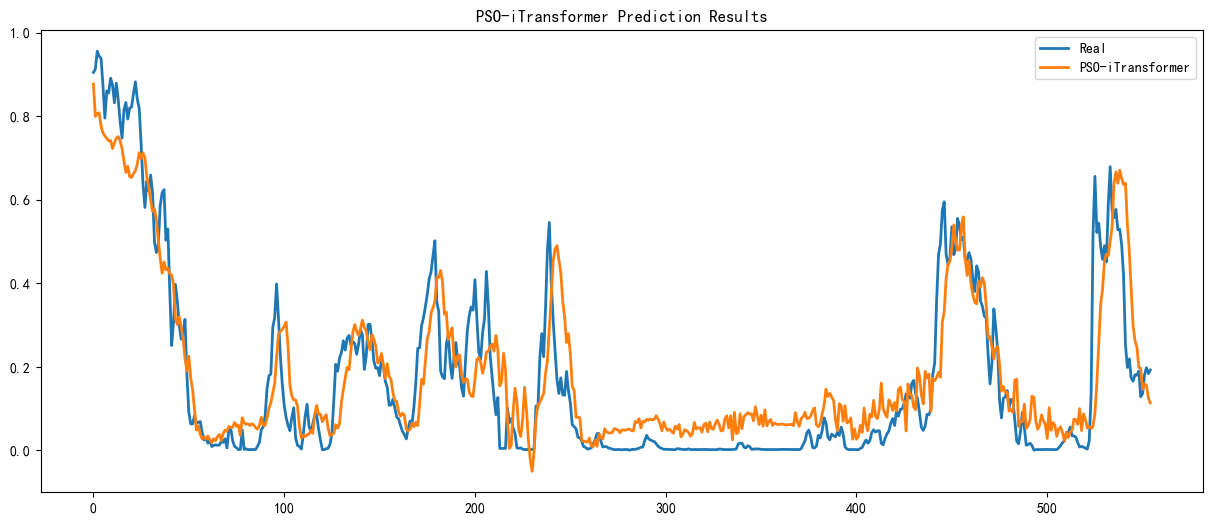

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from mealpy.swarm_based.PSO import OriginalPSO
import warnings
warnings.filterwarnings("ignore")
# ==============================================

# ===================== 你的数据（完全不变） =====================
train_X1 = x_spring_train.values.reshape((-1, 108, 1))
test_X1  = x_spring_test.values.reshape((-1, 108, 1))
val_X1   = x_spring_val.values.reshape((-1, 108, 1))

y_train = y_spring_train.values.ravel()
y_val   = y_spring_val.values.ravel()
y_test  = y_spring_test.values.ravel()

print("train_X1.shape:", train_X1.shape)
print("test_X1.shape:", test_X1.shape)

# ===================== iTransformer 模型（带PSO可调参数） =====================
class TransposeLayer(layers.Layer):
    def call(self, x):
        return tf.transpose(x, perm=[0, 2, 1])

def iTransformer_model(d_model, learning_rate):
    inputs = Input(shape=(108, 1))
    
    # 核心改进
    x = TransposeLayer()(inputs)
    x = layers.Dense(int(d_model))(x)
    
    # 自注意力
    x = layers.MultiHeadAttention(num_heads=2, key_dim=int(d_model)//2)(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dropout(0.1)(x)
    
    # 前馈
    x = layers.Dense(int(d_model)*2, activation="gelu")(x)
    x = layers.Dense(int(d_model))(x)
    
    # 输出
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(1)(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return model

# ===================== 完全照搬你 LSTM 的 PSO 格式 =====================
def cross_val(nest):
    d_model, epochs, learning_rate = nest
    model = iTransformer_model(d_model, learning_rate)
    model.fit(val_X1, y_val, epochs=int(epochs), batch_size=32, verbose=0, shuffle=False)
    y_pre = model.predict(val_X1, verbose=0)
    MSE = mean_squared_error(y_val, y_pre)
    return MSE

def fitness_function(nest):
    MSE = cross_val(nest)
    return MSE

def get_nest():
    problem_dict1 = {
         "fit_func": fitness_function,
         "lb":[16, 10, 1e-04],    # 维度、轮次、学习率 下限
         "ub":[64, 20, 1e-02],    # 维度、轮次、学习率 上限
         "minmax": "min",
         "verbose": True,
    } 
    epoch = 2
    pop_size = 16
    c1 = 2.05
    c2 = 2.05
    w_min = 0.4
    w_max = 0.9
    model = OriginalPSO(epoch, pop_size, c1, c2, w_min, w_max)
    best_position, best_fitness = model.solve(problem_dict1)
    print(f"最优参数: {best_position}, 最优MSE: {best_fitness}")
    return [best_fitness, best_position]

# ===================== 执行PSO寻优 =====================
nest = get_nest()
d_model = nest[1][0]
epochs  = nest[1][1]
lr      = nest[1][2]

# ===================== 训练最终模型 =====================
final_model = iTransformer_model(d_model, lr)
final_model.fit(train_X1, y_train, epochs=int(epochs), batch_size=16, verbose=2, shuffle=False)

# ===================== 预测 & 指标 =====================
y_pre_itrans = final_model.predict(test_X1)

r2 = r2_score(y_test, y_pre_itrans)
mse = mean_squared_error(y_test, y_pre_itrans)
mae = mean_absolute_error(y_test, y_pre_itrans)
mape = mean_absolute_percentage_error(y_test, y_pre_itrans)
rmse = np.sqrt(mse)

print("\n======= PSO-iTransformer (2026 SOTA) 结果 =======")
print(f"R²    = {r2:.4f}")
print(f"MSE   = {mse:.4f}")
print(f"RMSE  = {rmse:.4f}")
print(f"MAE   = {mae:.4f}")
print(f"MAPE  = {mape:.4f}")

# ===================== 绘图 =====================
plt.figure(figsize=(15,6))
plt.plot(y_test, label='Real', linewidth=2)
plt.plot(y_pre_itrans, label='PSO-iTransformer', linewidth=2)
plt.legend()
plt.title('PSO-iTransformer Prediction Results')
plt.show()

In [37]:
import pandas as pd
import numpy as np
import os

# ===================== 【自动创建文件夹】 =====================
directory = 'D:\\article'
if not os.path.exists(directory):
    os.makedirs(directory)

# ===================== 计算最大值、最小值（和你原来完全一样） =====================
scaler_max = spring_y_test.values.max()
scaler_min = spring_y_test.values.min()
print("归一化的最大值:", scaler_max)
print("归一化的最小值:", scaler_min)

# ===================== 反归一化函数 =====================
def inverse_transform(y_pred_scaled, y_actual_scaled, scaler_min, scaler_max):
    y_pred = y_pred_scaled * (scaler_max - scaler_min) + scaler_min
    y_actual = y_actual_scaled * (scaler_max - scaler_min) + scaler_min
    return y_pred, y_actual

# ===================== 【替换成 iTransformer 预测变量】 =====================
# y_pre_itrans 是你iTransformer模型的预测值
y_pre_itrans_inv, y_spring_test_inv = inverse_transform(
    y_pre_itrans,          # iTransformer 预测值（替换原来的 y_pre_transformer）
    y_spring_test.values,
    scaler_min,
    scaler_max
)

# ===================== 计算误差 =====================
spring_itrans_error = y_spring_test_inv - y_pre_itrans_inv
print("反归一化后的预测误差计算完成！")

# ===================== 【保存所有结果到 D:\article 文件夹】 =====================
# 保存为 DataFrame
result_df = pd.DataFrame({
    '实际值_反归一化': y_spring_test_inv.ravel(),
    'iTransformer预测值_反归一化': y_pre_itrans_inv.ravel(),
    '预测误差': spring_itrans_error.ravel()
})

# 保存路径
save_path = os.path.join(directory, 'iTransformer_预测结果.xlsx')

# 保存为 Excel 文件
result_df.to_excel(save_path, index=False)

print(f"\n所有数据已保存至：{save_path}")
print("✅ 保存内容：实际值、iTransformer预测值、预测误差")

归一化的最大值: 86.3374
归一化的最小值: -0.387959
反归一化后的预测误差计算完成！

所有数据已保存至：D:\article\iTransformer_预测结果.xlsx
✅ 保存内容：实际值、iTransformer预测值、预测误差


train_X1.shape: (1706, 108, 1)


2026/06/04 08:19:48 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: Solving single objective optimization problem.
2026/06/04 08:23:53 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >Problem: P, Epoch: 1, Current best: 0.003791266816114838, Global best: 0.003791266816114838, Runtime: 121.49525 seconds
2026/06/04 08:25:59 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >Problem: P, Epoch: 2, Current best: 0.003791266816114838, Global best: 0.003791266816114838, Runtime: 125.14652 seconds


最优参数: [2.67166473e+01 2.34462084e+01 1.90332114e-03], MSE: 0.003791266816114838
Epoch 1/23
107/107 - 3s - 24ms/step - loss: 0.0259
Epoch 2/23
107/107 - 0s - 4ms/step - loss: 0.0124
Epoch 3/23
107/107 - 0s - 3ms/step - loss: 0.0172
Epoch 4/23
107/107 - 0s - 3ms/step - loss: 0.0125
Epoch 5/23
107/107 - 0s - 3ms/step - loss: 0.0093
Epoch 6/23
107/107 - 0s - 4ms/step - loss: 0.0117
Epoch 7/23
107/107 - 0s - 3ms/step - loss: 0.0109
Epoch 8/23
107/107 - 0s - 3ms/step - loss: 0.0142
Epoch 9/23
107/107 - 0s - 3ms/step - loss: 0.0087
Epoch 10/23
107/107 - 0s - 4ms/step - loss: 0.0099
Epoch 11/23
107/107 - 0s - 3ms/step - loss: 0.0081
Epoch 12/23
107/107 - 0s - 3ms/step - loss: 0.0091
Epoch 13/23
107/107 - 0s - 3ms/step - loss: 0.0080
Epoch 14/23
107/107 - 0s - 3ms/step - loss: 0.0099
Epoch 15/23
107/107 - 0s - 3ms/step - loss: 0.0107
Epoch 16/23
107/107 - 0s - 3ms/step - loss: 0.0090
Epoch 17/23
107/107 - 0s - 3ms/step - loss: 0.0109
Epoch 18/23
107/107 - 0s - 3ms/step - loss: 0.0090
Epoch 19/2

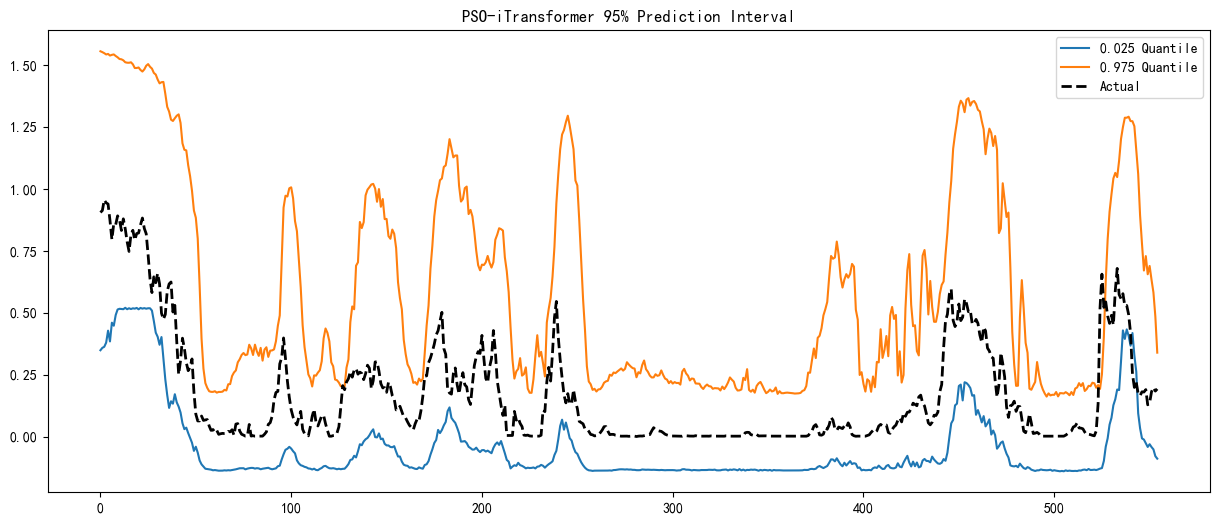

In [58]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt
from mealpy.swarm_based.PSO import OriginalPSO
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
import tensorflow as tf

# ===================== 数据（完全不变）=====================
train_X1 = x_spring_train.values.reshape((-1, 108, 1))
test_X1  = x_spring_test.values.reshape((-1, 108, 1))
val_X1   = x_spring_val.values.reshape((-1, 108, 1))

y_spring_train_flat = y_spring_train.values.ravel()
y_spring_val_flat   = y_spring_val.values.ravel()
y_spring_test_flat  = y_spring_test.values.ravel()

print("train_X1.shape:", train_X1.shape)

# ===================== 分位数损失函数（和你模板一样）=====================
def quantile_loss(y_true, y_pred, quantile):
    return K.mean(K.maximum(quantile * (y_true - y_pred), (quantile - 1) * (y_true - y_pred)), axis=-1)

# ===================== iTransformer 核心：转置层 =====================
class TransposeLayer(Layer):
    def call(self, x):
        return tf.transpose(x, perm=[0, 2, 1])

# ===================== iTransformer 模型（区间预测专用）=====================
def iTransformer_model(d_model, learning_rate, quantile):
    inputs = Input(shape=(108, 1))
    
    # iTransformer 核心结构
    x = TransposeLayer()(inputs)
    x = Dense(int(d_model))(x)
    
    x = MultiHeadAttention(num_heads=2, key_dim=int(d_model)//2)(x, x)
    x = LayerNormalization(epsilon=1e-6)(x)
    x = Dropout(0.1)(x)
    
    x = Dense(int(d_model)*2, activation="gelu")(x)
    x = Dense(int(d_model))(x)
    
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=learning_rate), 
                  loss=lambda y_true, y_pred: quantile_loss(y_true, y_pred, quantile))
    return model

# ===================== PSO 交叉验证（完全沿用你的模板）=====================
def cross_val(nest):
    d_model, epochs, learning_rate = nest
    model = iTransformer_model(d_model, learning_rate, quantile=0.5)
    model.fit(train_X1, y_spring_train_flat, epochs=int(epochs), batch_size=32, verbose=0, shuffle=False)
    y_pre = model.predict(val_X1, verbose=0)
    return mean_squared_error(y_spring_val_flat, y_pre)

def fitness_function(nest):
    return cross_val(nest)

# ===================== PSO 寻优 =====================
def get_nest():
    problem_dict1 = {
         "fit_func": fitness_function,
         "lb":[16, 10, 1e-04],
         "ub":[64, 30, 1e-02],
         "minmax": "min",
         "verbose": True,
    }
    epoch = 2
    pop_size = 16
    c1 = 2.05
    c2 = 2.05
    w_min = 0.4
    w_max = 0.9
    model = OriginalPSO(epoch, pop_size, c1, c2, w_min, w_max)
    best_position, best_fitness = model.solve(problem_dict1)
    print(f"最优参数: {best_position}, MSE: {best_fitness}")
    return [best_fitness, best_position]

# ===================== 执行PSO =====================
nest = get_nest()
d_model     = nest[1][0]
epochs      = nest[1][1]
lr          = nest[1][2]

# ===================== 95% 区间预测：0.025 / 0.975 =====================
quantiles = [0.025, 0.975]
predictions_itrans = {}

for q in quantiles:
    model = iTransformer_model(d_model, lr, q)
    model.fit(train_X1, y_spring_train_flat, epochs=int(epochs), batch_size=16, verbose=2, shuffle=False)
    pred = model.predict(test_X1)
    predictions_itrans[q] = pred

# ===================== 指标输出（和你模板完全一样）=====================
R2, mse, mae, mape, rmse = [], [], [], [], []

for q, y_pre in predictions_itrans.items():
    R2_q    = r2_score(y_spring_test_flat, y_pre)
    mse_q   = mean_squared_error(y_spring_test_flat, y_pre)
    mae_q   = mean_absolute_error(y_spring_test_flat, y_pre)
    mape_q  = mean_absolute_percentage_error(y_spring_test_flat, y_pre)
    rmse_q  = np.sqrt(mse_q)

    R2.append(R2_q)
    mse.append(mse_q)
    mae.append(mae_q)
    mape.append(mape_q)
    rmse.append(rmse_q)

    print(f"\n=== Quantile {q} ===")
    print(f"R²:    {R2_q:.4f}")
    print(f"MSE:   {mse_q:.4f}")
    print(f"MAE:   {mae_q:.4f}")
    print(f"MAPE:  {mape_q:.4f}")
    print(f"RMSE:  {rmse_q:.4f}")

# ===================== 绘图：95% 预测区间 =====================
plt.figure(figsize=(15,6))
plt.plot(predictions_itrans[0.025], label='0.025 Quantile', linewidth=1.5)
plt.plot(predictions_itrans[0.975], label='0.975 Quantile', linewidth=1.5)
plt.plot(y_spring_test_flat, 'k--', label='Actual', linewidth=2)
plt.title('PSO-iTransformer 95% Prediction Interval')
plt.legend()
plt.show()

In [59]:
# ===================== 计算 iTransformer 区间预测指标（95%）=====================
picp_95 = np.mean((y_spring_test.values >= predictions_itrans[0.025]) & (y_spring_test.values <= predictions_itrans[0.975]))
piaw_95 = np.mean(predictions_itrans[0.975] - predictions_itrans[0.025])
ace_95 = np.abs(0.95 - picp_95)
ais95 = np.mean((np.abs(y_spring_test.values - y_pre_itrans) / (predictions_itrans[0.975] - predictions_itrans[0.025])) ** 2)

itransformer_lb = predictions_itrans[0.025]  # 下限值
itransformer_ub = predictions_itrans[0.975]  # 上限值

print("PICP_95:", picp_95)
print("PIAW_95:", piaw_95)
print("ACE_95:", ace_95)
print("AIS_95:", ais95)

PICP_95: 0.9873873873873874
PIAW_95: 0.633379
ACE_95: 0.03738738738738745
AIS_95: 0.030379626013164


In [60]:
import pandas as pd
import numpy as np
import os

# 创建一个DataFrame来保存iTransformer区间数据
excel_data = {
    "iTransformer_Lower_Bound": itransformer_lb.flatten(),
    "iTransformer_Upper_Bound": itransformer_ub.flatten()
}

# 将数据转换为DataFrame
excel_df = pd.DataFrame(excel_data)

# 获取spring_y_test的最大值和最小值（和原代码完全一致）
scaler_max = spring_y_test.values.max()
scaler_min = spring_y_test.values.min()
print("归一化的最大值:", scaler_max)
print("归一化的最小值:", scaler_min)

# 反归一化函数（和原代码完全一致，无改动）
def inverse_normalize(value, scaler_min, scaler_max):
    return value * (scaler_max - scaler_min) + scaler_min

# 应用反归一化，仅替换模型名称
models = ["iTransformer"]
for model in models:
    model_lower_key = model + "_Lower_Bound"
    model_upper_key = model + "_Upper_Bound"
    excel_df[model_lower_key] = excel_df[model_lower_key].apply(lambda x: inverse_normalize(x, scaler_min, scaler_max))
    excel_df[model_upper_key] = excel_df[model_upper_key].apply(lambda x: inverse_normalize(x, scaler_min, scaler_max))

# 保存到Excel文件，路径不变，仅修改文件名对应iTransformer
directory = 'D:\\article'
file_path = os.path.join(directory, 'iTransformer_predictions_quantiles.xlsx')
excel_df.to_excel(file_path, index=False)

# 显示DataFrame
excel_df

归一化的最大值: 86.3374
归一化的最小值: -0.387959


,iTransformer_Lower_Bound,iTransformer_Upper_Bound
0,29.862971,134.547322
1,30.702031,134.248468
2,31.074451,133.885278
3,32.537690,133.428576
4,36.718644,133.616519
...,...,...
550,-3.041801,59.383746
551,-4.040455,54.539595
552,-4.850466,50.065266
553,-7.229394,41.674992


train_X1.shape  (1706, 108, 1)
test_X1.shape  (555, 108, 1)


C:\Users\cwj20010310\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 108, 12)             │             672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 108, 12)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 38)                  │           7,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              39 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,463 (33.06 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_98 (LSTM)                       │ (None, 108, 48)             │           9,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_49 (Dropout)                 │ (None, 108, 48)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_99 (LSTM)                       │ (None, 144)                 │         111,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 1)                   │             145 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 120,913 (472.32 KB)

 Trainable params: 120,913 (472.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/47
171/171 - 13s - 75ms/step - loss: 0.0643
Epoch 2/47
171/171 - 10s - 60ms/step - loss: 0.0186
Epoch 3/47
171/171 - 11s - 62ms/step - loss: 0.0115
Epoch 4/47
171/171 - 10s - 60ms/step - loss: 0.0106
Epoch 5/47
171/171 - 10s - 61ms/step - loss: 0.0100
Epoch 6/47
171/171 - 10s - 58ms/step - loss: 0.0083
Epoch 7/47
171/171 - 10s - 60ms/step - loss: 0.0078
Epoch 8/47
171/171 - 10s - 61ms/step - loss: 0.0075
Epoch 9/47
171/171 - 10s - 59ms/step - loss: 0.0071
Epoch 10/47
171/171 - 10s - 59ms/step - loss: 0.0094
Epoch 11/47
171/171 - 10s - 61ms/step - loss: 0.0081
Epoch 12/47
171/171 - 10s - 61ms/step - loss: 0.0079
Epoch 13/47
171/171 - 10s - 61ms/step - loss: 0.0073
Epoch 14/47
171/171 - 11s - 62ms/step - loss: 0.0079
Epoch 15/47
171/171 - 11s - 62ms/step - loss: 0.0077
Epoch 16/47
171/171 - 11s - 61ms/step - loss: 0.0077
Epoch 17/47
171/171 - 11s - 62ms/step - loss: 0.0067
Epoch 18/47
171/171 - 10s - 61ms/step - loss: 0.0058
Epoch 19/47
171/171 - 10s - 61ms/step - loss: 0.0071
Ep

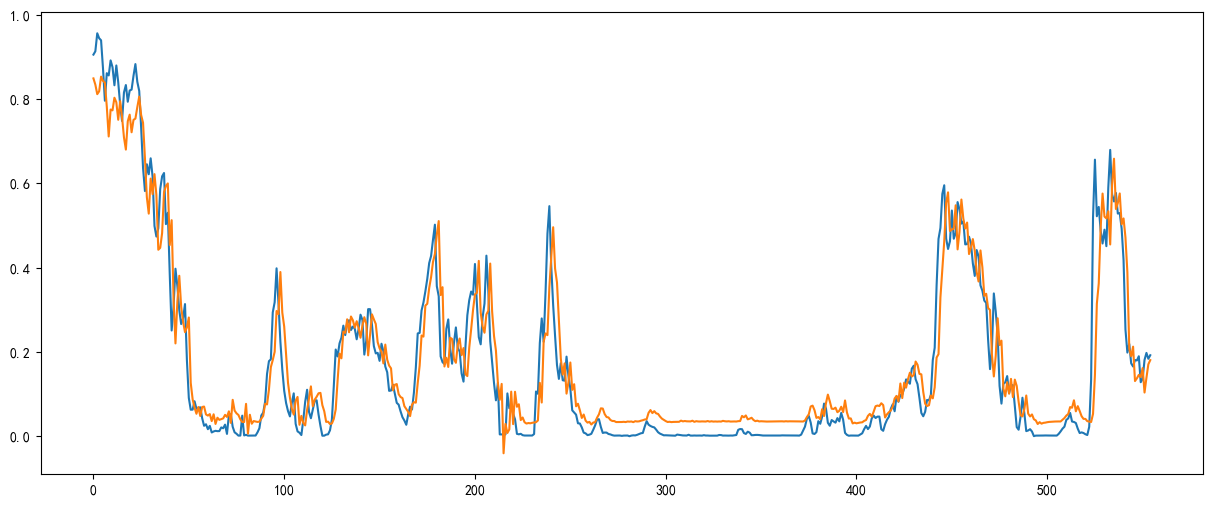

In [146]:
##成功的PSO-LSTM参数调优
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
from mealpy.swarm_based.PSO import OriginalPSO
from tensorflow.keras.optimizers import Adam
train_X1 = x_spring_train.values.reshape((x_spring_train.shape[0],108,1))
test_X1= x_spring_test.values.reshape((x_spring_test.shape[0],108,1))
print("train_X1.shape ",train_X1.shape)
print("test_X1.shape ",test_X1.shape)
def LSTM_model(units, learning_rate, train_X):
    # 使用Keras建构LSTM模型
    model = Sequential()
    model.add(LSTM(units=int(units), input_shape=(train_X1.shape[1], train_X1.shape[2]), return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(units=int(units*3)))
    model.add(Dense(1))#输出几步数字为几
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    model.summary()
    return model

def cross_val(nest):
    units,epochs,learning_rate = nest
    model=LSTM_model(units, learning_rate, x_spring_val)
    history = model.fit(x_spring_val, y_spring_val.values.ravel(), epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
    # 执行预测
    y_pre = model.predict(x_spring_val)
    # 计算MSE误差值
    MSE= mean_squared_error(y_spring_val.values.ravel(), y_pre)
    return MSE

#定义适应度函数
def fitness_function(nest):
    MSE = cross_val(nest)
    return MSE

def get_nest():
    # 适应度函数选择
    # units,epochs,learning_rate
    problem_dict1 = {
         "fit_func": fitness_function,
         "lb":[10,10,1e-04],
         "ub":[50,50,1e-02],
         "minmax": "min",
         "verbose": True,
    } 
    epoch = 2
    pop_size = 16
#大佬PSO优化函数已经封装好的，不用改动    
    c1 = 2.05
    c2 = 2.05
    w_min = 0.4
    w_max = 0.9
    model = OriginalPSO(epoch, pop_size, c1, c2, w_min, w_max)
    best_position, best_fitness = model.solve(problem_dict1)
    print(f"Solution: {best_position}, Fitness: {best_fitness}")
    return [best_fitness, best_position]#返回最优参数
#将获得的参数放入nest
nest=get_nest()
print(nest)
#取nest中的数赋给需要优化的参数
# units,epochs,learning_rate
units= nest[1][0]
epochs= nest[1][1]
learning_rate =nest[1][2]
model=LSTM_model(units, learning_rate, x_spring_train)
history = model.fit(x_spring_train, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=10, verbose=2, shuffle=False)
# 执行预测
y_pre_lstm = model.predict(x_spring_test)
# 计算r方
R2_lstm = r2_score(y_spring_test.values.ravel(), y_pre_lstm)
print("计算得出的r方为：", R2_lstm)
mse_lstm= mean_squared_error(y_spring_test.values.ravel(), y_pre_lstm)
mae_lstm= mean_absolute_error(y_spring_test.values.ravel(), y_pre_lstm)
mape_lstm= mean_absolute_percentage_error(y_spring_test.values.ravel(), y_pre_lstm)
# 计算平方差
squared_diff_lstm = np.square(y_spring_test.values.ravel()- y_pre_lstm)
#计算均值
mean_squared_error_lstm = np.mean(squared_diff_lstm)
#计算RMSE
rmse_lstm= np.sqrt(mean_squared_error_lstm)
print("MSE： ", mse_lstm)
print("MAE:", mae_lstm)
print("MAPE:", mape_lstm)
print("RMSE:", rmse_lstm)
#绘制PSO-LSTM预测之后的模型
plt.figure(figsize=(15,6))
plt.plot(y_spring_test.values.ravel())
plt.plot(y_pre_lstm)
plt.show()

In [147]:
import pandas as pd

# 计算y_spring_test的最大值和最小值
scaler_max = spring_y_test.values.max()  # 如果y_spring_test是多维的，使用max().max()获取全局最大值
scaler_min = spring_y_test.values.min()  # 如果y_spring_test是多维的，使用min().min()获取全局最小值
print("归一化的最大值:", scaler_max)
print("归一化的最小值:", scaler_min)

# 反归一化函数
def inverse_transform(y_pred_scaled, y_actual_scaled, scaler_min, scaler_max):
    y_pred = y_pred_scaled * (scaler_max - scaler_min) + scaler_min
    y_actual = y_actual_scaled * (scaler_max - scaler_min) + scaler_min
    return y_pred, y_actual

# 确保 y_pre_lstm 和 y_spring_test.values.ravel() 是一维数组
# 反归一化预测值和实际值
y_pre_lstm_inv, y_spring_test_inv = inverse_transform(y_pre_lstm, y_spring_test.values, scaler_min, scaler_max)
# 计算预测误差
spring_lstm_error = y_spring_test_inv - y_pre_lstm_inv
spring_lstm_error

归一化的最大值: 86.3374
归一化的最小值: -0.387959


array([[ 4.88927344e+00],
       [ 6.85319589e+00],
       [ 1.25170315e+01],
       [ 1.09090437e+01],
       [ 7.46612740e+00],
       [ 2.61232097e+00],
       [-3.69507198e+00],
       [ 6.87981307e+00],
       [ 1.25516550e+01],
       [ 1.01032288e+01],
       [ 8.87257077e+00],
       [ 2.56026748e+00],
       [ 7.57168538e+00],
       [ 7.68645278e+00],
       [-6.93477884e-01],
       [-7.97337679e-01],
       [ 9.22608063e+00],
       [ 1.32744213e+01],
       [ 4.01194102e+00],
       [ 4.95829164e+00],
       [ 8.77350224e+00],
       [ 9.05616017e+00],
       [ 1.12065118e+01],
       [ 5.20897384e+00],
       [ 1.16657808e+00],
       [-2.54512579e+00],
       [-9.28867510e+00],
       [-6.74931957e+00],
       [ 6.78380631e+00],
       [ 8.09934537e+00],
       [ 4.16729980e+00],
       [ 3.64495985e+00],
       [-1.06606568e+01],
       [-8.56044526e+00],
       [ 4.41151179e+00],
       [ 1.20773024e+01],
       [ 1.16656530e+01],
       [ 3.91140905e+00],
       [-7.8

train_X1.shape  (1706, 108, 1)
test_X1.shape  (555, 108, 1)


C:\Users\cwj20010310\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_102"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_204 (LSTM)                      │ (None, 108, 47)             │           9,212 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_102 (Dropout)                │ (None, 108, 47)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_205 (LSTM)                      │ (None, 142)                 │         107,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_102 (Dense)                    │ (None, 1)                   │             143 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,275 (458.11 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_304 (LSTM)                      │ (None, 108, 58)             │          13,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_152 (Dropout)                │ (None, 108, 58)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_305 (LSTM)                      │ (None, 175)                 │         163,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_152 (Dense)                    │ (None, 1)                   │             176 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 177,896 (694.91 KB)

 Trainable params: 177,896 (694.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/52
171/171 - 16s - 94ms/step - loss: 0.0148
Epoch 2/52
171/171 - 12s - 69ms/step - loss: 0.0127
Epoch 3/52
171/171 - 12s - 69ms/step - loss: 0.0097
Epoch 4/52
171/171 - 12s - 69ms/step - loss: 0.0082
Epoch 5/52
171/171 - 12s - 70ms/step - loss: 0.0080
Epoch 6/52
171/171 - 12s - 70ms/step - loss: 0.0097
Epoch 7/52
171/171 - 12s - 69ms/step - loss: 0.0071
Epoch 8/52
171/171 - 12s - 69ms/step - loss: 0.0081
Epoch 9/52
171/171 - 12s - 69ms/step - loss: 0.0067
Epoch 10/52
171/171 - 12s - 70ms/step - loss: 0.0067
Epoch 11/52
171/171 - 12s - 69ms/step - loss: 0.0064
Epoch 12/52
171/171 - 12s - 70ms/step - loss: 0.0066
Epoch 13/52
171/171 - 12s - 70ms/step - loss: 0.0065
Epoch 14/52
171/171 - 12s - 71ms/step - loss: 0.0062
Epoch 15/52
171/171 - 12s - 71ms/step - loss: 0.0063
Epoch 16/52
171/171 - 12s - 72ms/step - loss: 0.0063
Epoch 17/52
171/171 - 12s - 70ms/step - loss: 0.0069
Epoch 18/52
171/171 - 12s - 70ms/step - loss: 0.0061
Epoch 19/52
171/171 - 12s - 70ms/step - loss: 0.0078
Ep

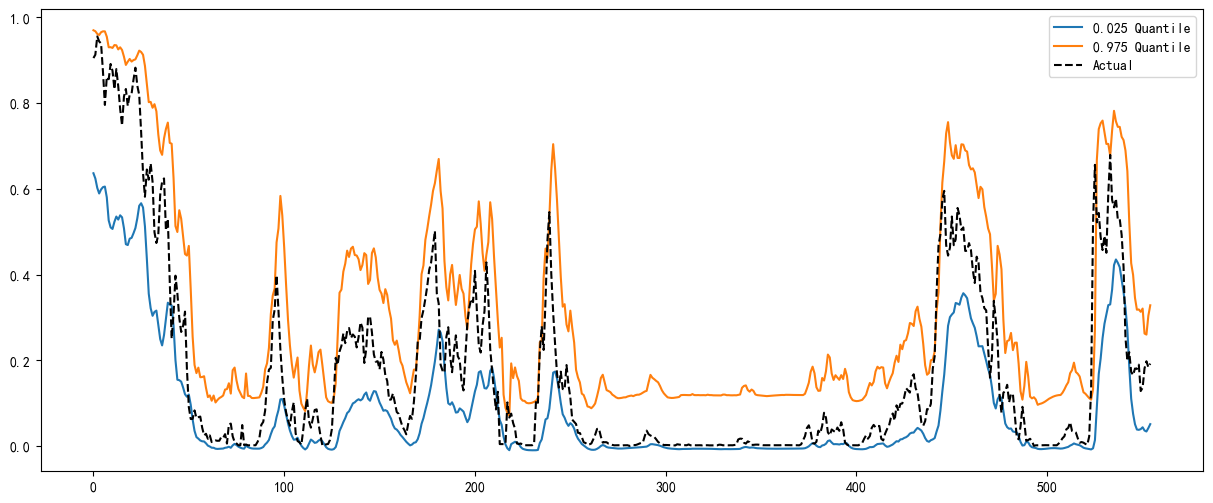

In [25]:
##LSTM区间预测（95%）
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
from mealpy.swarm_based.PSO import OriginalPSO
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
train_X1 = x_spring_train.values.reshape((x_spring_train.shape[0],108,1))
test_X1= x_spring_test.values.reshape((x_spring_test.shape[0],108,1))
val_X1= x_spring_val.values.reshape((x_spring_val.shape[0],108,1))
print("train_X1.shape ",train_X1.shape)
print("test_X1.shape ",test_X1.shape)

# 分位数损失函数
def quantile_loss(y_true, y_pred, quantile):
    return K.mean(K.maximum(quantile * (y_true - y_pred), (quantile - 1) * (y_true - y_pred)), axis=-1)

# LSTM模型
def LSTM_model(units, learning_rate, train_X, quantile):
    # 使用Keras建构LSTM模型
    model = Sequential()
    model.add(LSTM(units=int(units), input_shape=(train_X1.shape[1], train_X1.shape[2]), return_sequences=True))
    model.add(Dropout(0.6))
    model.add(LSTM(units=int(units*3)))
    model.add(Dense(1))  # 输出层
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=lambda y_true, y_pred: quantile_loss(y_true, y_pred, quantile))
    model.summary()
    return model

# 适应度函数
def fitness_function(nest):
    units, epochs, learning_rate, quantile = nest
    MSE = cross_val([units, epochs, learning_rate, quantile])
    return MSE

# 交叉验证
def cross_val(nest):
    units, epochs, learning_rate, quantile = nest
    model = LSTM_model(units, learning_rate, train_X1, quantile)
    history = model.fit(train_X1, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
    y_pre_qlstm = model.predict(val_X1)
    MSE = mean_squared_error(y_spring_val.values.ravel(), y_pre_qlstm)
    return MSE

# 获取最佳参数
def get_nest(): 
    problem_dict1 = {
        "fit_func": fitness_function,
        "lb": [20, 20, 1e-05, 0.025],  # 参数的下限
        "ub": [60, 60, 1e-03, 0.975],  # 参数的上限
        "minmax": "min",
        "verbose": True,
    }
    epoch = 2
    pop_size = 16
    c1 = 2.05
    c2 = 2.05
    w_min = 0.4
    w_max = 0.9
    model = OriginalPSO(epoch, pop_size, c1, c2, w_min, w_max)
    best_position, best_fitness = model.solve(problem_dict1)
    print(f"Solution: {best_position}, Fitness: {best_fitness}")
    return [best_fitness, best_position]

# 获取最佳参数
nest = get_nest()
print(nest)

# 取nest中的数赋给需要优化的参数
units = nest[1][0]
epochs = nest[1][1]
learning_rate = nest[1][2]

# 构建并训练LSTM模型，分别预测0.025和0.975分位数
quantiles = [0.025, 0.975]
predictions_qlstm = {}

for quantile in quantiles:
    model = LSTM_model(units, learning_rate, train_X1, quantile)
    history = model.fit(train_X1, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=10, verbose=2, shuffle=False)
    y_pre_qlstm = model.predict(test_X1)
    predictions_qlstm[quantile] = y_pre_qlstm

# 计算评估指标
R2, mse, mae, mape, rmse = [], [], [], [], []

for quantile, y_pre in predictions_qlstm.items():
    R2_qlstm = r2_score(y_spring_test.values.ravel(), y_pre_qlstm)
    mse_qlstm = mean_squared_error(y_spring_test.values.ravel(), y_pre_qlstm)
    mae_qlstm = mean_absolute_error(y_spring_test.values.ravel(), y_pre_qlstm)
    mape_qlstm = mean_absolute_percentage_error(y_spring_test.values.ravel(), y_pre_qlstm)
    rmse_qlstm = np.sqrt(mse_qlstm)

    R2.append(R2_qlstm)
    mse.append(mse_qlstm)
    mae.append(mae_qlstm)
    mape.append(mape_qlstm)
    rmse.append(rmse_qlstm)

    print(f"Quantile {quantile}:")
    print("计算得出的r方为：", R2_qlstm)
    print("MSE： ", mse_qlstm)
    print("MAE:", mae_qlstm)
    print("MAPE:", mape_qlstm)
    print("RMSE:", rmse_qlstm)

# 绘制PSO-LSTM预测之后的模型
plt.figure(figsize=(15,6))
for quantile, y_pre_qlstm in predictions_qlstm.items():
    plt.plot(y_pre_qlstm, label=f'{quantile} Quantile')

plt.plot(y_spring_test.values.ravel(), 'k--', label='Actual')
plt.legend()
plt.show()

In [26]:
#计算区间预测指标
picp_95 = np.mean((y_spring_test.values >= predictions_qlstm[0.025]) & (y_spring_test.values <= predictions_qlstm[0.975]))
piaw_95 = np.mean(predictions_qlstm[0.975] - predictions_qlstm[0.025])
ace_95 = np.abs(0.95 - picp_95)
ais95 = np.mean((np.abs(y_spring_test.values - y_pre_qlstm) / (predictions_qlstm[0.975] - predictions_qlstm[0.025])) ** 2)
lstm_lb= predictions_qlstm[0.025]  # 下限值
lstm_ub = predictions_qlstm[0.975]  # 上限值
print(picp_95,piaw_95,ace_95,ais95)

0.9243243243243243 0.22374389 0.025675675675675635 0.585842628219411


In [27]:
import pandas as pd
import numpy as np
import os

# 创建一个DataFrame来保存数据
excel_data = {
    "LSTM_Lower_Bound": lstm_lb.flatten(),
    "LSTM_Upper_Bound": lstm_ub.flatten()
}

# 将数据转换为DataFrame
excel_df = pd.DataFrame(excel_data)

# 获取spring_y_test的最大值和最小值
scaler_max = spring_y_test.values.max()  # 如果spring_y_test是多维的，使用max().max()获取全局最大值
scaler_min = spring_y_test.values.min()  # 如果spring_y_test是多维的，使用min().min()获取全局最小值
print("归一化的最大值:", scaler_max)
print("归一化的最小值:", scaler_min)

# 反归一化函数
def inverse_normalize(value, scaler_min, scaler_max):
    return value * (scaler_max - scaler_min) + scaler_min

# 应用反归一化
models = ["LSTM"]
for model in models:
    model_lower_key = model + "_Lower_Bound"
    model_upper_key = model + "_Upper_Bound"
    excel_df[model_lower_key] = excel_df[model_lower_key].apply(lambda x: inverse_normalize(x, scaler_min, scaler_max))
    excel_df[model_upper_key] = excel_df[model_upper_key].apply(lambda x: inverse_normalize(x, scaler_min, scaler_max))

# 将合并后的 DataFrame 保存到 Excel 文件中
directory = 'D:\\article'
file_path = os.path.join(directory, 'LSTM_predictions_quantiles.xlsx')
excel_df.to_excel(file_path, index=False)

# 显示DataFrame
excel_df

归一化的最大值: 86.3374
归一化的最小值: -0.387959


,LSTM_Lower_Bound,LSTM_Upper_Bound
0,54.806689,83.727945
1,53.746598,83.534801
2,51.853139,82.993019
3,50.715613,82.772288
4,51.530806,83.333258
...,...,...
550,3.428648,27.439396
551,2.767127,22.386431
552,2.571205,22.175950
553,3.262400,25.989914


train_X1.shape: (1706, 108, 1)
test_X1.shape: (555, 108, 1)


C:\Users\cwj20010310\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_598"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_796 (Conv1D)                  │ (None, 108, 34)             │             204 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_598 (Dropout)                │ (None, 108, 34)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_797 (Conv1D)                  │ (None, 108, 104)            │          17,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_398 (Flatten)                │ (None, 11232)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_598 (Dense)                    │ (None, 1)                   │          11,233 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,221 (114.14 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_894 (Conv1D)                  │ (None, 108, 52)             │             156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_647 (Dropout)                │ (None, 108, 52)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_895 (Conv1D)                  │ (None, 108, 156)            │          16,380 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_447 (Flatten)                │ (None, 16848)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_647 (Dense)                    │ (None, 1)                   │          16,849 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,385 (130.41 KB)

 Trainable params: 33,385 (130.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/35
171/171 - 1s - 7ms/step - loss: 0.0690
Epoch 2/35
171/171 - 0s - 2ms/step - loss: 0.0294
Epoch 3/35
171/171 - 0s - 3ms/step - loss: 0.0231
Epoch 4/35
171/171 - 0s - 3ms/step - loss: 0.0205
Epoch 5/35
171/171 - 0s - 3ms/step - loss: 0.0178
Epoch 6/35
171/171 - 0s - 3ms/step - loss: 0.0167
Epoch 7/35
171/171 - 0s - 3ms/step - loss: 0.0158
Epoch 8/35
171/171 - 0s - 3ms/step - loss: 0.0133
Epoch 9/35
171/171 - 0s - 3ms/step - loss: 0.0135
Epoch 10/35
171/171 - 0s - 3ms/step - loss: 0.0130
Epoch 11/35
171/171 - 0s - 3ms/step - loss: 0.0125
Epoch 12/35
171/171 - 0s - 3ms/step - loss: 0.0123
Epoch 13/35
171/171 - 0s - 3ms/step - loss: 0.0120
Epoch 14/35
171/171 - 0s - 3ms/step - loss: 0.0108
Epoch 15/35
171/171 - 0s - 3ms/step - loss: 0.0108
Epoch 16/35
171/171 - 0s - 3ms/step - loss: 0.0100
Epoch 17/35
171/171 - 0s - 3ms/step - loss: 0.0106
Epoch 18/35
171/171 - 0s - 3ms/step - loss: 0.0092
Epoch 19/35
171/171 - 0s - 3ms/step - loss: 0.0099
Epoch 20/35
171/171 - 0s - 3ms/step - lo

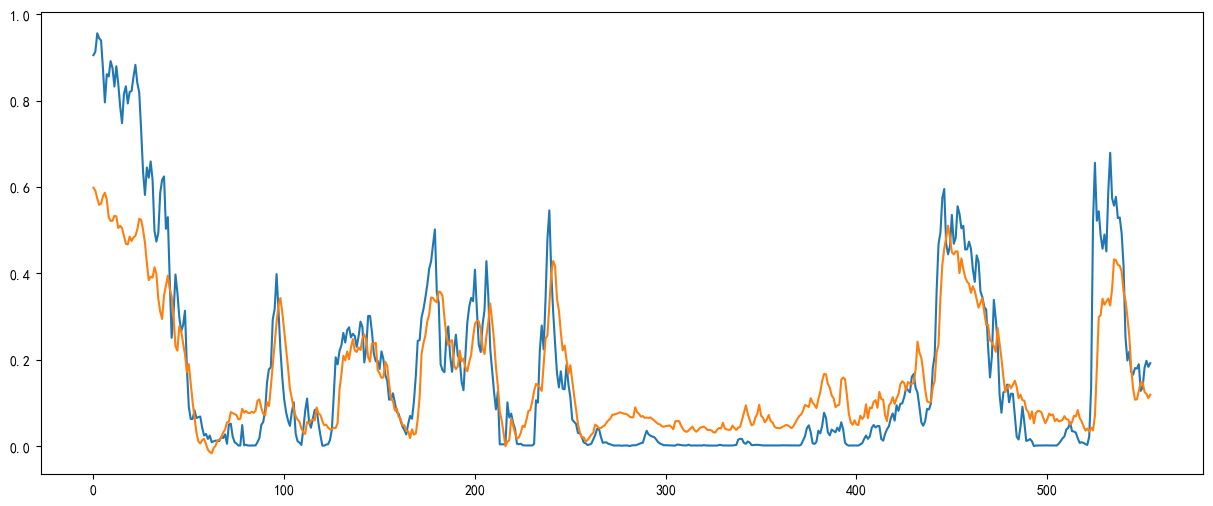

In [367]:
##成功的PSO-TCN参数调优  
from sklearn.metrics import mean_squared_error  
from mealpy.swarm_based.PSO import OriginalPSO  
from tensorflow.keras.optimizers import Adam  
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten  
from tensorflow.keras.models import Sequential  

# 调整 train_X1 和 test_X1 的形状  
train_X1 = x_spring_train.values.reshape((x_spring_train.shape[0], 108, 1))  
test_X1 = x_spring_test.values.reshape((x_spring_test.shape[0], 108, 1))
val_X1 = x_spring_val.values.reshape((x_spring_val.shape[0], 108, 1))

print("train_X1.shape:", train_X1.shape)  
print("test_X1.shape:", test_X1.shape)  

# 在TCN_model 函数中，确保kernel_size为整数  
def TCN_model(filters, kernel_size, learning_rate):  
    model = Sequential()  
    model.add(Conv1D(filters=int(filters), kernel_size=int(kernel_size), padding='causal', activation='relu', input_shape=(train_X1.shape[1], train_X1.shape[2])))  
    model.add(Dropout(0.5))  
    model.add(Conv1D(filters=int(filters *3), kernel_size=int(kernel_size), padding='causal', activation='relu'))  
    model.add(Flatten())  
    model.add(Dense(1))  # 输出层  

    optimizer = Adam(learning_rate=learning_rate)  
    model.compile(optimizer=optimizer, loss='mse')  
    model.summary()  
    return model  

def cross_val(nest):  
    filters, kernel_size, epochs, learning_rate = nest  
    model = TCN_model(filters, kernel_size, learning_rate)  

    # 确保在交叉验证中使用的是适当的训练集，而不是验证集  
    history = model.fit(train_X1, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)  

    # 在验证集上进行预测并计算 MSE  
    y_pre = model.predict(test_X1)  # 使用测试集进行预测  
    MSE = mean_squared_error(y_spring_val.values.ravel(), y_pre)  
    return MSE  

# 同样在fitness_function中确保传递的kernel_size为整数  
def fitness_function(nest):  
    # 将kernel_size转换为最接近的整数  
    kernel_size = round(nest[1])  
    nest_int = [nest[0], kernel_size, nest[2], nest[3]]  # 重建nest，确保kernel_size为整数  
    MSE = cross_val(nest_int)  
    return MSE

def get_nest():  
    problem_dict1 = {  
        "fit_func": fitness_function,  
        "lb": [30, 2, 30, 1e-06],  # 参数的下限  
        "ub": [60, 5, 60, 1e-03],  # 参数的上限  
        "minmax": "min",  
        "verbose": True,  
    }  
    epochs = 2  
    pop_size = 16  
    c1 = 2.05  
    c2 = 2.05  
    w_min = 0.4  
    w_max = 0.9  
    model = OriginalPSO(epochs, pop_size, c1, c2, w_min, w_max)  

    best_position, best_fitness = model.solve(problem_dict1)  
    print(f"Solution: {best_position}, Fitness: {best_fitness}")  
    return [best_fitness, best_position]  

# 获取最佳参数  
nest = get_nest()  
print(nest)  

# 取nest中的数赋给需要优化的参数  
filters = nest[1][0]  
kernel_size = nest[1][1]  
epochs = nest[1][2]  
learning_rate = nest[1][3]  

# 构建并训练TCN模型  
model = TCN_model(filters, kernel_size, learning_rate)  
history = model.fit(train_X1, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=10, verbose=2, shuffle=False)  

# 执行预测  
y_pre_tcn = model.predict(test_X1)  

# 计算r方  
R2_tcn = r2_score(y_spring_test.values.ravel(), y_pre_tcn)  
print("计算得出的r方为：", R2_tcn)  

# 计算评估指标  
mse_tcn = mean_squared_error(y_spring_test.values.ravel(), y_pre_tcn)  
mae_tcn = mean_absolute_error(y_spring_test.values.ravel(), y_pre_tcn)  
mape_tcn = mean_absolute_percentage_error(y_spring_test.values.ravel(), y_pre_tcn)  

# 计算RMSE
rmse_tcn= np.sqrt(mse_tcn)
print("MSE： ", mse_tcn)
print("MAE:", mae_tcn)
print("MAPE:", mape_tcn)
print("RMSE:", rmse_tcn)
#绘制PSO-TCN预测之后的模型
plt.figure(figsize=(15,6))
plt.plot(y_spring_test.values.ravel())
plt.plot(y_pre_tcn)
plt.show()

In [368]:
import pandas as pd

# 计算y_spring_test的最大值和最小值
scaler_max = spring_y_test.values.max()  # 如果y_spring_test是多维的，使用max().max()获取全局最大值
scaler_min = spring_y_test.values.min()  # 如果y_spring_test是多维的，使用min().min()获取全局最小值
print("归一化的最大值:", scaler_max)
print("归一化的最小值:", scaler_min)

# 反归一化函数
def inverse_transform(y_pred_scaled, y_actual_scaled, scaler_min, scaler_max):
    y_pred = y_pred_scaled * (scaler_max - scaler_min) + scaler_min
    y_actual = y_actual_scaled * (scaler_max - scaler_min) + scaler_min
    return y_pred, y_actual

# 确保 y_pre_tcn 和 y_spring_test.values.ravel() 是一维数组
# 反归一化预测值和实际值
y_pre_tcn_inv, y_spring_test_inv = inverse_transform(y_pre_tcn, y_spring_test.values, scaler_min, scaler_max)
# 计算预测误差
spring_tcn_error = y_spring_test_inv - y_pre_tcn_inv
spring_tcn_error

归一化的最大值: 86.3374
归一化的最小值: -0.387959


array([[ 2.65878551e+01],
       [ 2.78708770e+01],
       [ 3.31429051e+01],
       [ 3.33938727e+01],
       [ 3.27549229e+01],
       [ 2.55211535e+01],
       [ 1.81223642e+01],
       [ 2.51750134e+01],
       [ 2.82693636e+01],
       [ 3.20779602e+01],
       [ 3.06386345e+01],
       [ 2.59245520e+01],
       [ 3.01323162e+01],
       [ 2.89645099e+01],
       [ 2.39788129e+01],
       [ 2.10593556e+01],
       [ 2.84438464e+01],
       [ 3.15782886e+01],
       [ 2.82990161e+01],
       [ 2.90191055e+01],
       [ 3.01080436e+01],
       [ 3.22118418e+01],
       [ 3.43142694e+01],
       [ 2.93938875e+01],
       [ 2.53638590e+01],
       [ 1.80807630e+01],
       [ 1.16894171e+01],
       [ 9.57611226e+00],
       [ 1.92277188e+01],
       [ 2.05524742e+01],
       [ 2.31400171e+01],
       [ 1.95799498e+01],
       [ 7.33587178e+00],
       [ 6.47430281e+00],
       [ 1.31585688e+01],
       [ 2.37862142e+01],
       [ 2.79012010e+01],
       [ 2.38848931e+01],
       [ 1.1

train_X1.shape: (1706, 108, 1)
test_X1.shape: (555, 108, 1)


C:\Users\cwj20010310\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 108, 34)             │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_51 (Dropout)                 │ (None, 108, 34)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 108, 102)            │          10,506 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 11016)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 1)                   │          11,017 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,659 (84.61 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_100 (Conv1D)                  │ (None, 108, 37)             │             111 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_101 (Dropout)                │ (None, 108, 37)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_101 (Conv1D)                  │ (None, 108, 113)            │           8,475 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_50 (Flatten)                 │ (None, 12204)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_101 (Dense)                    │ (None, 1)                   │          12,205 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,791 (81.21 KB)

 Trainable params: 20,791 (81.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/78
171/171 - 1s - 7ms/step - loss: 0.0231
Epoch 2/78
171/171 - 0s - 2ms/step - loss: 0.0131
Epoch 3/78
171/171 - 0s - 2ms/step - loss: 0.0119
Epoch 4/78
171/171 - 0s - 2ms/step - loss: 0.0104
Epoch 5/78
171/171 - 0s - 3ms/step - loss: 0.0107
Epoch 6/78
171/171 - 0s - 3ms/step - loss: 0.0113
Epoch 7/78
171/171 - 0s - 3ms/step - loss: 0.0090
Epoch 8/78
171/171 - 0s - 3ms/step - loss: 0.0078
Epoch 9/78
171/171 - 0s - 2ms/step - loss: 0.0096
Epoch 10/78
171/171 - 0s - 2ms/step - loss: 0.0081
Epoch 11/78
171/171 - 0s - 2ms/step - loss: 0.0077
Epoch 12/78
171/171 - 0s - 2ms/step - loss: 0.0087
Epoch 13/78
171/171 - 0s - 2ms/step - loss: 0.0100
Epoch 14/78
171/171 - 0s - 2ms/step - loss: 0.0082
Epoch 15/78
171/171 - 0s - 2ms/step - loss: 0.0088
Epoch 16/78
171/171 - 0s - 2ms/step - loss: 0.0071
Epoch 17/78
171/171 - 0s - 2ms/step - loss: 0.0083
Epoch 18/78
171/171 - 0s - 2ms/step - loss: 0.0076
Epoch 19/78
171/171 - 0s - 2ms/step - loss: 0.0100
Epoch 20/78
171/171 - 0s - 2ms/step - lo

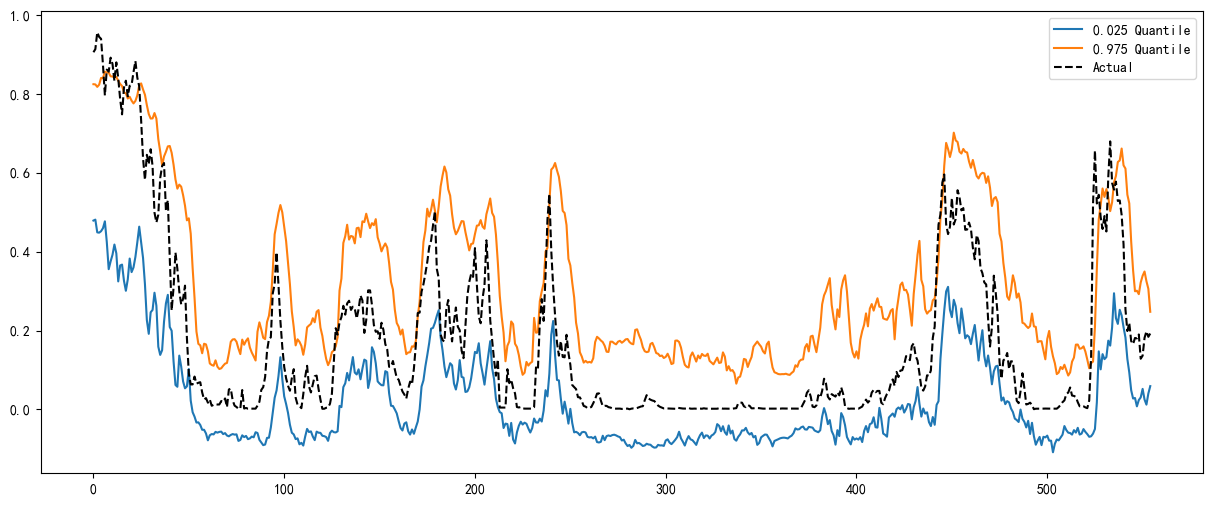

In [32]:
#TCN区间预测（95%）
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from mealpy.swarm_based.PSO import OriginalPSO
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras import backend as K

# 调整 train_X1 和 test_X1 的形状
train_X1 = x_spring_train.values.reshape((x_spring_train.shape[0], 108, 1))
test_X1 = x_spring_test.values.reshape((x_spring_test.shape[0], 108, 1))
val_X1 = x_spring_val.values.reshape((x_spring_val.shape[0], 108, 1))

print("train_X1.shape:", train_X1.shape)
print("test_X1.shape:", test_X1.shape)

# 分位数损失函数
def quantile_loss(y_true, y_pred, quantile):
    return K.mean(K.maximum(quantile * (y_true - y_pred), (quantile - 1) * (y_true - y_pred)), axis=-1)

# TCN模型
def TCN_model(filters, kernel_size, learning_rate, quantile):
    model = Sequential()
    model.add(Conv1D(filters=int(filters), kernel_size=int(kernel_size), padding='causal', activation='relu', input_shape=(train_X1.shape[1], train_X1.shape[2])))
    model.add(Dropout(0.5))
    model.add(Conv1D(filters=int(filters * 3), kernel_size=int(kernel_size), padding='causal', activation='relu'))
    model.add(Flatten())
    model.add(Dense(1))  # 输出层
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=lambda y_true, y_pred: quantile_loss(y_true, y_pred, quantile))
    model.summary()
    return model

# 交叉验证
def cross_val(nest):
    filters, kernel_size, epochs, learning_rate, quantile = nest
    model = TCN_model(filters, kernel_size, learning_rate, quantile)
    history = model.fit(train_X1, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
    y_pre_qtcn = model.predict(val_X1)
    MSE = mean_squared_error(y_spring_val.values.ravel(), y_pre_qtcn)
    return MSE

# 适应度函数
def fitness_function(nest):
    kernel_size = round(nest[1])
    nest_int = [nest[0], kernel_size, nest[2], nest[3], 0.95]  # 95%分位数
    MSE = cross_val(nest_int)
    return MSE

# 获取最佳参数
def get_nest(): 
    problem_dict1 = {
        "fit_func": fitness_function,
        "lb": [30, 2, 30, 1e-06, 0.025],  # 参数的下限
        "ub": [80, 5, 80, 1e-03, 0.975],  # 参数的上限
        "minmax": "min",
        "verbose": True,
    }
    epochs = 2
    pop_size = 16
    c1 = 2.05
    c2 = 2.05
    w_min = 0.4
    w_max = 0.9
    model = OriginalPSO(epochs, pop_size, c1, c2, w_min, w_max)
    best_position, best_fitness = model.solve(problem_dict1)
    print(f"Solution: {best_position}, Fitness: {best_fitness}")
    return [best_fitness, best_position]

# 获取最佳参数
nest = get_nest()
print(nest)

# 取nest中的数赋给需要优化的参数
filters = nest[1][0]
kernel_size = nest[1][1]
epochs = nest[1][2]
learning_rate = nest[1][3]

# 构建并训练TCN模型，分别预测0.025和0.975分位数
quantiles = [0.025, 0.975]
predictions = {}

for quantile in quantiles:
    model = TCN_model(filters, kernel_size, learning_rate, quantile)
    history = model.fit(train_X1, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=10, verbose=2, shuffle=False)
    y_pre_qtcn = model.predict(test_X1)
    predictions[quantile] = y_pre_qtcn

# 计算评估指标
R2, mse, mae, mape, rmse = [], [], [], [], []

for quantile, y_pre_qtcn in predictions.items():
    R2_qtcn = r2_score(y_spring_test.values.ravel(), y_pre_qtcn)
    mse_qtcn = mean_squared_error(y_spring_test.values.ravel(), y_pre_qtcn)
    mae_qtcn = mean_absolute_error(y_spring_test.values.ravel(), y_pre_qtcn)
    mape_qtcn = mean_absolute_percentage_error(y_spring_test.values.ravel(), y_pre_qtcn)
    rmse_qtcn = np.sqrt(mse_qtcn)

    R2.append(R2_qtcn)
    mse.append(mse_qtcn)
    mae.append(mae_qtcn)
    mape.append(mape_qtcn)
    rmse.append(rmse_qtcn)

    print(f"Quantile {quantile}:")
    print("计算得出的r方为：", R2_qtcn)
    print("MSE： ", mse_qtcn)
    print("MAE:", mae_qtcn)
    print("MAPE:", mape_qtcn)
    print("RMSE:", rmse_qtcn)

# 绘制PSO-TCN预测之后的模型
plt.figure(figsize=(15,6))
for quantile, y_pre_qtcn in predictions.items():
    plt.plot(y_pre_qtcn, label=f'{quantile} Quantile')

plt.plot(y_spring_test.values.ravel(), 'k--', label='Actual')
plt.legend()
plt.show()

In [46]:
#计算区间预测指标
picp_95 = np.mean((y_spring_test.values >= predictions[0.025]) & (y_spring_test.values <= predictions[0.975]))
piaw_95 = np.mean(predictions[0.975] - predictions[0.025])
ace_95 = np.abs(0.95 - picp_95)
ais95 = np.mean((np.abs(y_spring_test.values - y_pre) / (predictions[0.975] - predictions[0.025])) ** 2)
tcn_lb= predictions[0.025]  # 下限值
tcn_ub = predictions[0.975]  # 上限值
print(picp_95,piaw_95,ace_95,ais95)

0.9315315315315316 0.2957275 0.01846846846846839 0.41732899877293095


In [21]:
###GRU进行预测
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pylab as plt

train_X1 = x_spring_train.values.reshape((x_spring_train.shape[0], 108, 1))
test_X1 = x_spring_test.values.reshape((x_spring_test.shape[0], 108, 1))
val_X1 = x_spring_val.values.reshape((x_spring_val.shape[0], 108, 1))

# 定义GRU模型
def GRU_model(units, learning_rate, train_X):
    model = Sequential()
    model.add(GRU(units=int(units), input_shape=(train_X1.shape[1], train_X1.shape[2]), return_sequences=True))
    model.add(Dropout(0.5))
    model.add(GRU(units=int(units*3), return_sequences=False))
    model.add(Dense(1))  # 预测的是1步输出
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    model.summary()
    return model

##成功的PSO参数调优
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
from mealpy.swarm_based.PSO import OriginalPSO

def cross_val(nest):
    units,epochs,learning_rate = nest
    model=GRU_model(units, learning_rate, val_X1)
    history = model.fit(val_X1, y_spring_val, epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
    # 执行预测
    y_pre = model.predict(val_X1)
    # 计算MSE误差值
    MSE= mean_squared_error(y_spring_val, y_pre)
    return MSE

#定义适应度函数
def fitness_function(nest):
    MSE = cross_val(nest)
    return MSE

#定义适应度函数的参数范围
def get_nest():
    problem_dict1 = {
         "fit_func": fitness_function,
         "lb": [30,30, 1e-06],
         "ub": [50,50, 1e-03],
         "minmax": "min",
    }
#设置迭代次数和粒子群数（越大运行速度越慢）
    epochs = 2  
    pop_size = 16  
    c1 = 2.05  
    c2 = 2.05  
    w_min = 0.4  
    w_max = 0.9  
    model = OriginalPSO(epochs, pop_size, c1, c2, w_min, w_max)  
    best_position, best_fitness = model.solve(problem_dict1)  
    print(f"Solution: {best_position}, Fitness: {best_fitness}")  
    return [best_fitness, best_position]  
#将获得的参数放入nest
nest=get_nest()
print(nest)
#取nest中的数赋给需要优化的参数
# units,epochs,learning_rate
units= nest[1][0]
epochs= nest[1][1]
learning_rate =nest[1][2]

model = GRU_model(units, learning_rate, train_X1)
history = model.fit(train_X1, y_spring_train, epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
y_pre_gru = model.predict(test_X1)

C:\Users\cwj20010310\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 108, 47)             │           7,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 108, 47)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 141)                 │          80,370 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             142 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 87,562 (342.04 KB)

 Trainable params: 87,562 (342.04 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_98 (GRU)                         │ (None, 108, 44)             │           6,204 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_49 (Dropout)                 │ (None, 108, 44)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_99 (GRU)                         │ (None, 132)                 │          70,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 1)                   │             133 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 76,825 (300.10 KB)

 Trainable params: 76,825 (300.10 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/49
27/27 - 6s - 233ms/step - loss: 0.0416
Epoch 2/49
27/27 - 3s - 106ms/step - loss: 0.0115
Epoch 3/49
27/27 - 3s - 105ms/step - loss: 0.0104
Epoch 4/49
27/27 - 3s - 101ms/step - loss: 0.0090
Epoch 5/49
27/27 - 3s - 104ms/step - loss: 0.0091
Epoch 6/49
27/27 - 3s - 103ms/step - loss: 0.0087
Epoch 7/49
27/27 - 3s - 99ms/step - loss: 0.0082
Epoch 8/49
27/27 - 3s - 99ms/step - loss: 0.0078
Epoch 9/49
27/27 - 3s - 98ms/step - loss: 0.0077
Epoch 10/49
27/27 - 3s - 98ms/step - loss: 0.0078
Epoch 11/49
27/27 - 3s - 97ms/step - loss: 0.0073
Epoch 12/49
27/27 - 3s - 98ms/step - loss: 0.0076
Epoch 13/49
27/27 - 3s - 98ms/step - loss: 0.0068
Epoch 14/49
27/27 - 3s - 97ms/step - loss: 0.0066
Epoch 15/49
27/27 - 3s - 96ms/step - loss: 0.0066
Epoch 16/49
27/27 - 3s - 97ms/step - loss: 0.0067
Epoch 17/49
27/27 - 3s - 100ms/step - loss: 0.0075
Epoch 18/49
27/27 - 3s - 95ms/step - loss: 0.0061
Epoch 19/49
27/27 - 3s - 96ms/step - loss: 0.0064
Epoch 20/49
27/27 - 3s - 95ms/step - loss: 0.0061
Ep

计算得出的r方为： 0.8900599376629528
MSE：  0.005555963269790021
MAE: 0.05437738059507542
MAPE: 4.9788522916721725
RMSE: 0.07453833423004583


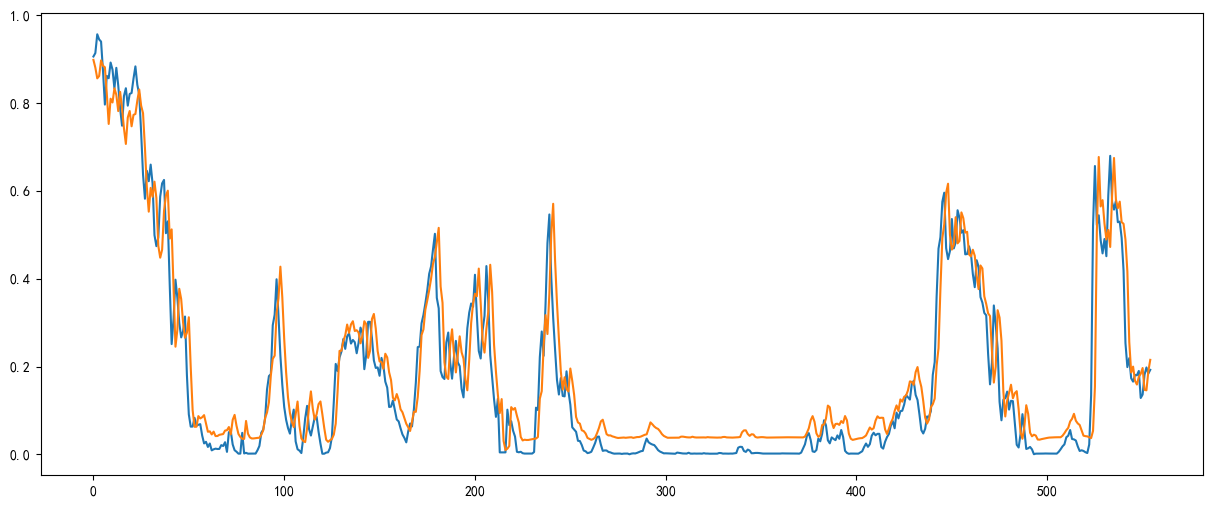

In [22]:
# 计算r方  
R2_gru = r2_score(y_spring_test.values.ravel(), y_pre_gru)  
print("计算得出的r方为：", R2_gru)  

# 计算评估指标  
mse_gru = mean_squared_error(y_spring_test.values.ravel(), y_pre_gru)  
mae_gru = mean_absolute_error(y_spring_test.values.ravel(), y_pre_gru)  
mape_gru = mean_absolute_percentage_error(y_spring_test.values.ravel(), y_pre_gru)  

# 计算RMSE
rmse_gru= np.sqrt(mse_gru)
print("MSE： ", mse_gru)
print("MAE:", mae_gru)
print("MAPE:", mape_gru)
print("RMSE:", rmse_gru)
#绘制PSO-GRU预测之后的模型
plt.figure(figsize=(15,6))
plt.plot(y_spring_test.values.ravel())
plt.plot(y_pre_gru)
plt.show()

In [23]:
import pandas as pd

# 计算y_spring_test的最大值和最小值
scaler_max = spring_y_test.values.max()  # 如果y_spring_test是多维的，使用max().max()获取全局最大值
scaler_min = spring_y_test.values.min()  # 如果y_spring_test是多维的，使用min().min()获取全局最小值
print("归一化的最大值:", scaler_max)
print("归一化的最小值:", scaler_min)

# 反归一化函数
def inverse_transform(y_pred_scaled, y_actual_scaled, scaler_min, scaler_max):
    y_pred = y_pred_scaled * (scaler_max - scaler_min) + scaler_min
    y_actual = y_actual_scaled * (scaler_max - scaler_min) + scaler_min
    return y_pred, y_actual

# 确保 y_pre_gru 和 y_spring_test.values.ravel() 是一维数组
# 反归一化预测值和实际值
y_pre_gru_inv, y_spring_test_inv = inverse_transform(y_pre_gru, y_spring_test.values, scaler_min, scaler_max)
# 计算预测误差
spring_gru_error = y_spring_test_inv - y_pre_gru_inv
# 保存误差到数据框
spring_gru_error_df = pd.DataFrame(spring_gru_error, columns=['error'])
# 打印数据框
print(spring_gru_error_df)

归一化的最大值: 86.3374
归一化的最小值: -0.387959
        error
0    0.664496
1    2.880700
2    8.693286
3    7.219102
4    3.701189
..        ...
550 -5.233891
551  2.990192
552  4.512849
553 -0.484320
554 -1.971158

[555 rows x 1 columns]


C:\Users\cwj20010310\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_102"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_102 (GRU)                        │ (None, 108, 53)             │           8,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_51 (Dropout)                 │ (None, 108, 53)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_103 (GRU)                        │ (None, 161)                 │         104,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_102 (Dense)                    │ (None, 1)                   │             162 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 113,394 (442.95 KB)

 Trainable params: 113,394 (442.95 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_202 (GRU)                        │ (None, 108, 35)             │           3,990 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_101 (Dropout)                │ (None, 108, 35)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_203 (GRU)                        │ (None, 105)                 │          44,730 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_152 (Dense)                    │ (None, 1)                   │             106 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 48,826 (190.73 KB)

 Trainable params: 48,826 (190.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/37
171/171 - 13s - 74ms/step - loss: 0.0149
Epoch 2/37
171/171 - 10s - 59ms/step - loss: 0.0078
Epoch 3/37
171/171 - 10s - 61ms/step - loss: 0.0080
Epoch 4/37
171/171 - 11s - 62ms/step - loss: 0.0084
Epoch 5/37
171/171 - 11s - 62ms/step - loss: 0.0077
Epoch 6/37
171/171 - 11s - 62ms/step - loss: 0.0081
Epoch 7/37
171/171 - 11s - 62ms/step - loss: 0.0076
Epoch 8/37
171/171 - 11s - 62ms/step - loss: 0.0064
Epoch 9/37
171/171 - 11s - 62ms/step - loss: 0.0065
Epoch 10/37
171/171 - 11s - 62ms/step - loss: 0.0066
Epoch 11/37
171/171 - 11s - 63ms/step - loss: 0.0071
Epoch 12/37
171/171 - 11s - 62ms/step - loss: 0.0085
Epoch 13/37
171/171 - 11s - 62ms/step - loss: 0.0066
Epoch 14/37
171/171 - 11s - 63ms/step - loss: 0.0066
Epoch 15/37
171/171 - 11s - 62ms/step - loss: 0.0061
Epoch 16/37
171/171 - 11s - 62ms/step - loss: 0.0060
Epoch 17/37
171/171 - 11s - 62ms/step - loss: 0.0063
Epoch 18/37
171/171 - 11s - 62ms/step - loss: 0.0067
Epoch 19/37
171/171 - 11s - 62ms/step - loss: 0.0077
Ep

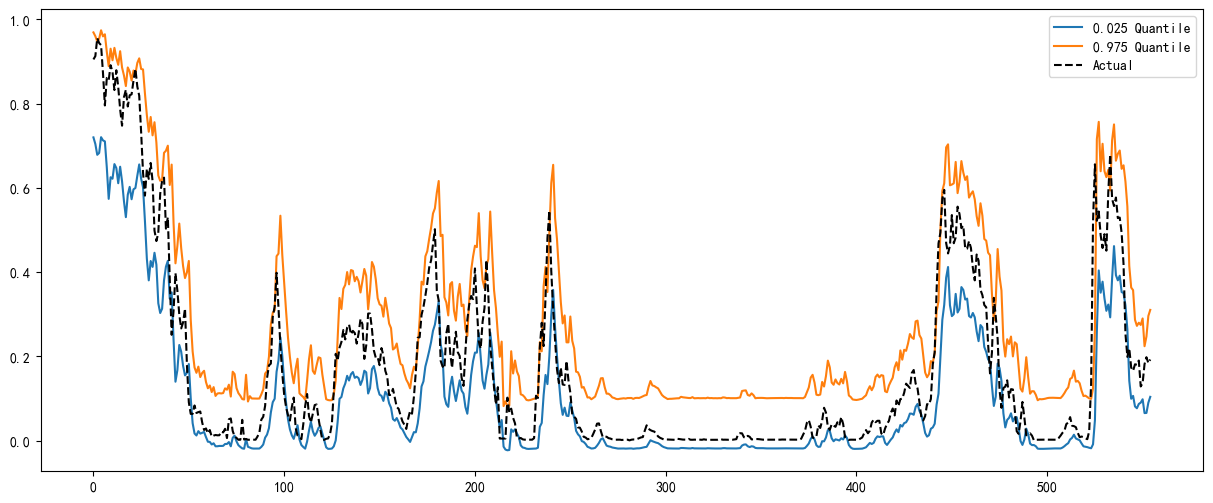

In [26]:
#GRU区间预测（95%）
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pylab as plt
from tensorflow.keras import backend as K

train_X1 = x_spring_train.values.reshape((x_spring_train.shape[0], 108, 1))
test_X1 = x_spring_test.values.reshape((x_spring_test.shape[0], 108, 1))
val_X1 = x_spring_val.values.reshape((x_spring_val.shape[0], 108, 1))

# 分位数损失函数
def quantile_loss(y_true, y_pred, quantile):
    return K.mean(K.maximum(quantile * (y_true - y_pred), (quantile - 1) * (y_true - y_pred)), axis=-1)

# GRU模型
def GRU_model(units, learning_rate, train_X, quantile):
    model = Sequential()
    model.add(GRU(units=int(units), input_shape=(train_X.shape[1], train_X.shape[2]), return_sequences=True))
    model.add(Dropout(0.5))
    model.add(GRU(units=int(units*3), return_sequences=False))
    model.add(Dense(1))  # 预测的是1步输出
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=lambda y_true, y_pred: quantile_loss(y_true, y_pred, quantile))
    model.summary()
    return model

##成功的PSO参数调优
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
from mealpy.swarm_based.PSO import OriginalPSO

def cross_val(nest):
    units,epochs,learning_rate,quantile = nest
    model=GRU_model(units, learning_rate, val_X1,quantile)
    history = model.fit(val_X1, y_spring_val, epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
    # 执行预测
    y_pre = model.predict(val_X1)
    # 计算MSE误差值
    MSE= mean_squared_error(y_spring_val, y_pre)
    return MSE

# 适应度函数
def fitness_function(nest):
    units, epochs, learning_rate, quantile = nest
    MSE = cross_val([units, epochs, learning_rate, quantile])
    return MSE

#定义适应度函数的参数范围
def get_nest():
    problem_dict1 = {
         "fit_func": fitness_function,
         "lb": [30,30, 1e-06,0.025],
         "ub": [60,60, 1e-03,0.975],
         "minmax": "min",
    }
#设置迭代次数和粒子群数（越大运行速度越慢）
    epochs = 2  
    pop_size = 16  
    c1 = 2.05  
    c2 = 2.05  
    w_min = 0.4  
    w_max = 0.9  
    model = OriginalPSO(epochs, pop_size, c1, c2, w_min, w_max)  
    best_position, best_fitness = model.solve(problem_dict1)  
    print(f"Solution: {best_position}, Fitness: {best_fitness}")  
    return [best_fitness, best_position]  
#将获得的参数放入nest
nest=get_nest()
print(nest)
#取nest中的数赋给需要优化的参数
# units,epochs,learning_rate
units= nest[1][0]
epochs= nest[1][1]
learning_rate =nest[1][2]

# 构建并训练GRU模型，分别预测0.025和0.975分位数
quantiles = [0.025, 0.975]
predictions_qgru = {}

for quantile in quantiles:
    model = GRU_model(units, learning_rate, train_X1, quantile)
    history = model.fit(train_X1, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=10, verbose=2, shuffle=False)
    y_pre_qgru = model.predict(test_X1)
    predictions_qgru[quantile] = y_pre_qgru

# 计算评估指标
R2, mse, mae, mape, rmse = [], [], [], [], []

for quantile, y_pre_qgru in predictions_qgru.items():
    R2_qgru = r2_score(y_spring_test.values.ravel(), y_pre_qgru)
    mse_qgru = mean_squared_error(y_spring_test.values.ravel(), y_pre_qgru)
    mae_qgru = mean_absolute_error(y_spring_test.values.ravel(), y_pre_qgru)
    mape_qgru = mean_absolute_percentage_error(y_spring_test.values.ravel(), y_pre_qgru)
    rmse_qgru = np.sqrt(mse_qgru)

    R2.append(R2_qgru)
    mse.append(mse_qgru)
    mae.append(mae_qgru)
    mape.append(mape_qgru)
    rmse.append(rmse_qgru)

    print(f"Quantile {quantile}:")
    print("计算得出的r方为：", R2_qgru)
    print("MSE： ", mse_qgru)
    print("MAE:", mae_qgru)
    print("MAPE:", mape_qgru)
    print("RMSE:", rmse_qgru)

# 绘制PSO-GRU预测之后的模型
plt.figure(figsize=(15,6))
for quantile, y_pre_qgru in predictions_qgru.items():
    plt.plot(y_pre_qgru, label=f'{quantile} Quantile')

plt.plot(y_spring_test.values.ravel(), 'k--', label='Actual')
plt.legend()
plt.show()

In [27]:
#计算区间预测指标
picp_95 = np.mean((y_spring_test.values >= predictions_qgru[0.025]) & (y_spring_test.values <= predictions_qgru[0.975]))
piaw_95 = np.mean(predictions_qgru[0.975] - predictions_qgru[0.025])
ace_95 = np.abs(0.95 - picp_95)
ais95 = np.mean((np.abs(y_spring_test.values - y_pre_qgru) / (predictions_qgru[0.975] - predictions_qgru[0.025])) ** 2)
gru_lb= predictions_qgru[0.025]  # 下限值
gru_ub = predictions_qgru[0.975]  # 上限值
print(picp_95,piaw_95,ace_95,ais95)

0.8882882882882883 0.1808415 0.061711711711711636 0.544424442863272


train_X1.shape  (1706, 108, 1)
test_X1.shape  (555, 108, 1)


C:\Users\cwj20010310\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 108, 48)             │           2,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 48)                  │           4,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 1)                   │              49 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,105 (27.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_98 (SimpleRNN)            │ (None, 108, 33)             │           1,155 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_99 (SimpleRNN)            │ (None, 33)                  │           2,211 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_99 (Dense)                     │ (None, 1)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,400 (13.28 KB)

 Trainable params: 3,400 (13.28 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/39
27/27 - 2s - 78ms/step - loss: 0.1353
Epoch 2/39
27/27 - 1s - 21ms/step - loss: 0.0316
Epoch 3/39
27/27 - 1s - 21ms/step - loss: 0.0228
Epoch 4/39
27/27 - 1s - 21ms/step - loss: 0.0188
Epoch 5/39
27/27 - 1s - 21ms/step - loss: 0.0167
Epoch 6/39
27/27 - 1s - 20ms/step - loss: 0.0152
Epoch 7/39
27/27 - 1s - 21ms/step - loss: 0.0141
Epoch 8/39
27/27 - 1s - 21ms/step - loss: 0.0131
Epoch 9/39
27/27 - 1s - 21ms/step - loss: 0.0124
Epoch 10/39
27/27 - 1s - 20ms/step - loss: 0.0118
Epoch 11/39
27/27 - 1s - 20ms/step - loss: 0.0113
Epoch 12/39
27/27 - 1s - 21ms/step - loss: 0.0108
Epoch 13/39
27/27 - 1s - 20ms/step - loss: 0.0105
Epoch 14/39
27/27 - 1s - 20ms/step - loss: 0.0102
Epoch 15/39
27/27 - 1s - 21ms/step - loss: 0.0099
Epoch 16/39
27/27 - 1s - 23ms/step - loss: 0.0096
Epoch 17/39
27/27 - 1s - 21ms/step - loss: 0.0094
Epoch 18/39
27/27 - 1s - 22ms/step - loss: 0.0092
Epoch 19/39
27/27 - 1s - 21ms/step - loss: 0.0089
Epoch 20/39
27/27 - 1s - 20ms/step - loss: 0.0087
Epoch 21/

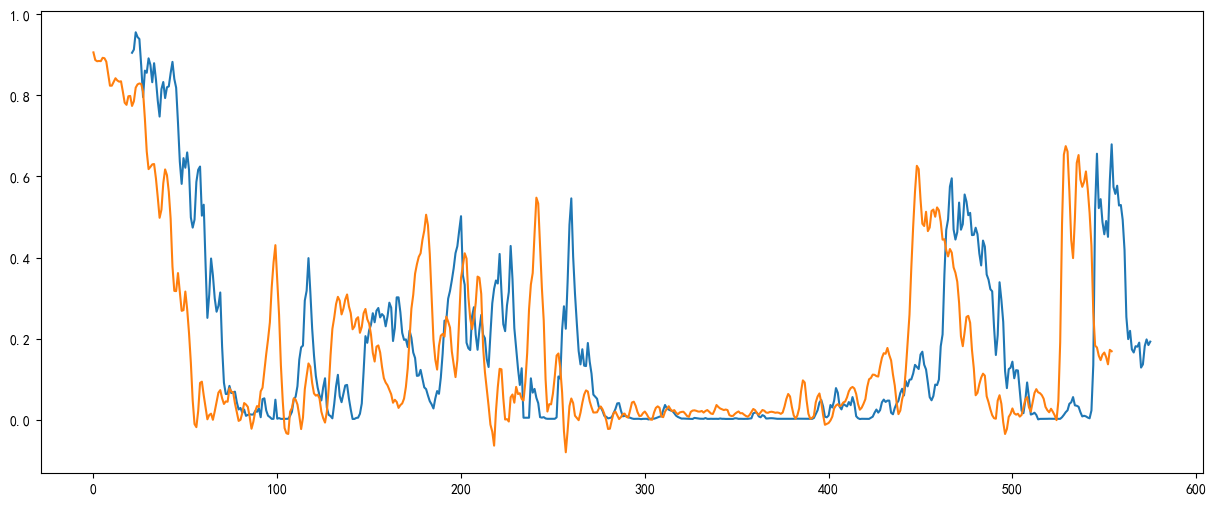

In [22]:
###RNN进行预测
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import SimpleRNN

train_X1 = x_spring_train.values.reshape((x_spring_train.shape[0],108,1))
test_X1= x_spring_test.values.reshape((x_spring_test.shape[0],108,1))
val_X1= x_spring_val.values.reshape((x_spring_val.shape[0],108,1))
print("train_X1.shape ",train_X1.shape)
print("test_X1.shape ",test_X1.shape)

# 定义 RNN 模型
def RNN_model(units, learning_rate):
    model = Sequential()
    units=int(units)
    model.add(SimpleRNN(units, input_shape=(108,1), return_sequences=True))
    # 隐藏层
    model.add(SimpleRNN(units))
    model.add(Dense(1))
    # 编译模型
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    model.summary()
    return model

##成功的PSO参数调优
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
from mealpy.swarm_based.PSO import OriginalPSO

def cross_val(nest):
    units,epochs,learning_rate = nest
    model=RNN_model(units, learning_rate)
    history = model.fit(train_X1, y_spring_train, epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
    # 执行预测
    y_pre = model.predict(val_X1)
    # 计算MSE误差值
    MSE= mean_squared_error(y_spring_val, y_pre)
    return MSE
    
#定义适应度函数
def fitness_function(nest):
    MSE = cross_val(nest)
    return MSE

#定义适应度函数的参数范围
def get_nest():
    problem_dict1 = {
         "fit_func": fitness_function,
         "lb": [30,30, 1e-06],
         "ub": [60,60, 1e-03],
         "minmax": "min",
    }
#设置迭代次数和粒子群数（越大运行速度越慢）
    epochs = 2  
    pop_size = 16  
    c1 = 2.05  
    c2 = 2.05  
    w_min = 0.4  
    w_max = 0.9  
    model = OriginalPSO(epochs, pop_size, c1, c2, w_min, w_max)  
    best_position, best_fitness = model.solve(problem_dict1)  
    print(f"Solution: {best_position}, Fitness: {best_fitness}")  
    return [best_fitness, best_position]  
#将获得的参数放入nest
nest=get_nest()
print(nest)
#取nest中的数赋给需要优化的参数
# units,epochs,learning_rate
units= nest[1][0]
epochs= nest[1][1]
learning_rate =nest[1][2]
model = RNN_model(units, learning_rate)
history = model.fit(train_X1, y_spring_train, epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
y_pre_rnn = model.predict(test_X1)
# 计算r方  
R2_rnn = r2_score(y_spring_test, y_pre_rnn)  
print("计算得出的r方为：", R2_rnn)  

# 计算评估指标  
mse_rnn = mean_squared_error(y_spring_test, y_pre_rnn)  
mae_rnn = mean_absolute_error(y_spring_test, y_pre_rnn)  
mape_rnn = mean_absolute_percentage_error(y_spring_test, y_pre_rnn)  

# 计算RMSE
rmse_rnn= np.sqrt(mse_rnn)
print("MSE： ", mse_rnn)
print("MAE:", mae_rnn)
print("MAPE:", mape_rnn)
print("RMSE:", rmse_rnn)
#绘制PSO-rnn预测之后的模型
plt.figure(figsize=(15,6))
plt.plot(y_spring_test)
plt.plot(y_pre_rnn)
plt.show()

In [23]:
import pandas as pd

# 计算y_spring_test的最大值和最小值
scaler_max = spring_y_test.values.max()  # 如果y_spring_test是多维的，使用max().max()获取全局最大值
scaler_min = spring_y_test.values.min()  # 如果y_spring_test是多维的，使用min().min()获取全局最小值
print("归一化的最大值:", scaler_max)
print("归一化的最小值:", scaler_min)

# 反归一化函数
def inverse_transform(y_pred_scaled, y_actual_scaled, scaler_min, scaler_max):
    y_pred = y_pred_scaled * (scaler_max - scaler_min) + scaler_min
    y_actual = y_actual_scaled * (scaler_max - scaler_min) + scaler_min
    return y_pred, y_actual

# 确保 y_pre_rnn 和 y_spring_test.values.ravel() 是一维数组
# 反归一化预测值和实际值
y_pre_rnn_inv, y_spring_test_inv = inverse_transform(y_pre_rnn, y_spring_test.values, scaler_min, scaler_max)
# 计算预测误差
spring_rnn_error = y_spring_test_inv - y_pre_rnn_inv
# 保存误差到数据框
spring_rnn_error_df = pd.DataFrame(spring_rnn_error, columns=['error'])
# 打印数据框
print(spring_rnn_error_df)

归一化的最大值: 86.3374
归一化的最小值: -0.387959
        error
0   -0.084176
1    2.228539
2    6.199702
3    5.120882
4    4.732470
..        ...
550 -2.535506
551  2.351663
552  5.331435
553  1.019220
554  2.058798

[555 rows x 1 columns]


train_X1.shape  (1706, 108, 1)
test_X1.shape  (555, 108, 1)


C:\Users\cwj20010310\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_204"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_204 (SimpleRNN)           │ (None, 108, 29)             │             899 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_205 (SimpleRNN)           │ (None, 29)                  │           1,711 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_204 (Dense)                    │ (None, 1)                   │              30 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,640 (10.31 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_304 (SimpleRNN)           │ (None, 108, 36)             │           1,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_305 (SimpleRNN)           │ (None, 36)                  │           2,628 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_254 (Dense)                    │ (None, 1)                   │              37 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 4,033 (15.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
27/27 - 2s - 92ms/step - loss: 0.2001
Epoch 2/30
27/27 - 1s - 23ms/step - loss: 0.0180
Epoch 3/30
27/27 - 1s - 22ms/step - loss: 0.0134
Epoch 4/30
27/27 - 1s - 22ms/step - loss: 0.0116
Epoch 5/30
27/27 - 1s - 29ms/step - loss: 0.0096
Epoch 6/30
27/27 - 1s - 25ms/step - loss: 0.0090
Epoch 7/30
27/27 - 1s - 29ms/step - loss: 0.0082
Epoch 8/30
27/27 - 1s - 34ms/step - loss: 0.0078
Epoch 9/30
27/27 - 1s - 25ms/step - loss: 0.0079
Epoch 10/30
27/27 - 1s - 26ms/step - loss: 0.0073
Epoch 11/30
27/27 - 1s - 31ms/step - loss: 0.0072
Epoch 12/30
27/27 - 1s - 32ms/step - loss: 0.0069
Epoch 13/30
27/27 - 1s - 23ms/step - loss: 0.0068
Epoch 14/30
27/27 - 1s - 22ms/step - loss: 0.0067
Epoch 15/30
27/27 - 1s - 25ms/step - loss: 0.0066
Epoch 16/30
27/27 - 1s - 41ms/step - loss: 0.0064
Epoch 17/30
27/27 - 1s - 38ms/step - loss: 0.0063
Epoch 18/30
27/27 - 1s - 31ms/step - loss: 0.0061
Epoch 19/30
27/27 - 1s - 48ms/step - loss: 0.0062
Epoch 20/30
27/27 - 1s - 39ms/step - loss: 0.0060
Epoch 21/

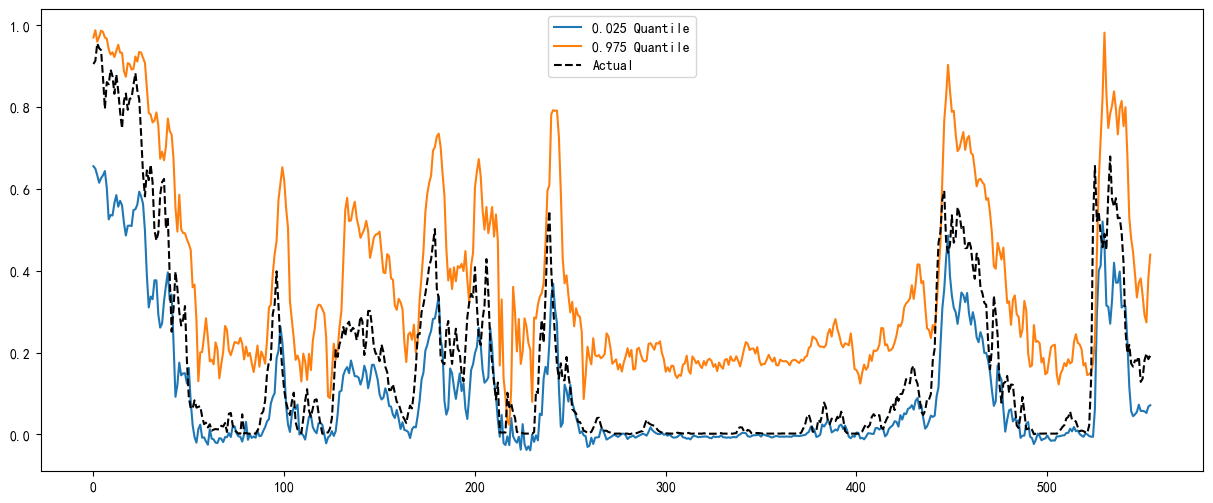

In [31]:
###RNN进行区间预测
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras import backend as K

train_X1 = x_spring_train.values.reshape((x_spring_train.shape[0], 108, 1))
test_X1 = x_spring_test.values.reshape((x_spring_test.shape[0], 108, 1))
val_X1 = x_spring_val.values.reshape((x_spring_val.shape[0], 108, 1))

print("train_X1.shape ",train_X1.shape)
print("test_X1.shape ",test_X1.shape)
# 分位数损失函数
def quantile_loss(y_true, y_pred, quantile):
    return K.mean(K.maximum(quantile * (y_true - y_pred), (quantile - 1) * (y_true - y_pred)), axis=-1)

# RNN模型
def RNN_model(units, learning_rate, quantile):
    model = Sequential()
    units = int(units)
    model.add(SimpleRNN(units, input_shape=(108, 1), return_sequences=True))
    # 隐藏层
    model.add(SimpleRNN(units))
    # 输出层
    model.add(Dense(1))
    # 编译模型
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=lambda y_true, y_pred: quantile_loss(y_true, y_pred, quantile))
    model.summary()
    return model
    
##成功的PSO参数调优
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
from mealpy.swarm_based.PSO import OriginalPSO

def cross_val(nest):
    units,epochs,learning_rate,quantile = nest
    model=RNN_model(units, learning_rate,quantile)
    history = model.fit(train_X1, y_spring_train, epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
    # 执行预测
    y_pre = model.predict(val_X1)
    # 计算MSE误差值
    MSE= mean_squared_error(y_spring_val, y_pre)
    return MSE

# 适应度函数
def fitness_function(nest):
    units, epochs, learning_rate, quantile = nest
    MSE = cross_val([units, epochs, learning_rate, quantile])
    return MSE

#定义适应度函数的参数范围
def get_nest():
    problem_dict1 = {
         "fit_func": fitness_function,
         "lb": [20,20, 1e-06,0.025],
         "ub": [60,60, 1e-03,0.975],
         "minmax": "min",
    }
#设置迭代次数和粒子群数（越大运行速度越慢）
    epochs = 2  
    pop_size = 16  
    c1 = 2.05  
    c2 = 2.05  
    w_min = 0.4  
    w_max = 0.9  
    model = OriginalPSO(epochs, pop_size, c1, c2, w_min, w_max)  
    best_position, best_fitness = model.solve(problem_dict1)  
    print(f"Solution: {best_position}, Fitness: {best_fitness}")  
    return [best_fitness, best_position]  
#将获得的参数放入nest
nest=get_nest()
print(nest)
#取nest中的数赋给需要优化的参数
# units,epochs,learning_rate
units= nest[1][0]
epochs= nest[1][1]
learning_rate =nest[1][2]

# 构建并训练RNN模型，分别预测0.025和0.975分位数
quantiles = [0.025, 0.975]
predictions_qrnn = {}

for quantile in quantiles:
    model = RNN_model(units, learning_rate, quantile)
    history = model.fit(train_X1, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
    y_pre_qrnn = model.predict(test_X1)
    predictions_qrnn[quantile] = y_pre_qrnn

# 计算评估指标
R2, mse, mae, mape, rmse = [], [], [], [], []

for quantile, y_pre_qrnn in predictions_qrnn.items():
    R2_qrnn = r2_score(y_spring_test.values.ravel(), y_pre_qrnn)
    mse_qrnn = mean_squared_error(y_spring_test.values.ravel(), y_pre_qrnn)
    mae_qrnn = mean_absolute_error(y_spring_test.values.ravel(), y_pre_qrnn)
    mape_qrnn = mean_absolute_percentage_error(y_spring_test.values.ravel(), y_pre_qrnn)
    rmse_qrnn = np.sqrt(mse_qrnn)

    R2.append(R2_qrnn)
    mse.append(mse_qrnn)
    mae.append(mae_qrnn)
    mape.append(mape_qrnn)
    rmse.append(rmse_qrnn)

    print(f"Quantile {quantile}:")
    print("计算得出的r方为：", R2_qrnn)
    print("MSE： ", mse_qrnn)
    print("MAE:", mae_qrnn)
    print("MAPE:", mape_qrnn)
    print("RMSE:", rmse_qrnn)

# 绘制PSO-RNN预测之后的模型
plt.figure(figsize=(15,6))
for quantile, y_pre_qrnn in predictions_qrnn.items():
    plt.plot(y_pre_qrnn, label=f'{quantile} Quantile')

plt.plot(y_spring_test.values.ravel(), 'k--', label='Actual')
plt.legend()
plt.show()

In [32]:
#计算区间预测指标
picp_95 = np.mean((y_spring_test.values >= predictions_qrnn[0.025]) & (y_spring_test.values <= predictions_qrnn[0.975]))
piaw_95 = np.mean(predictions_qrnn[0.975] - predictions_qrnn[0.025])
ace_95 = np.abs(0.95 - picp_95)
ais95 = np.mean((np.abs(y_spring_test.values - y_pre_qrnn) / (predictions_qrnn[0.975] - predictions_qrnn[0.025])) ** 2)
rnn_lb= predictions_qrnn[0.025]  # 下限值
rnn_ub = predictions_qrnn[0.975]  # 上限值
print(picp_95,piaw_95,ace_95,ais95)

0.8846846846846846 0.2684379 0.06531531531531531 0.6875405292117935


In [51]:
import pandas as pd
import numpy as np
import os

# 创建一个DataFrame来保存数据
excel_data = {
    "RNN_Lower_Bound": rnn_lb.flatten(),
    "RNN_Upper_Bound": rnn_ub.flatten(),
    "LSTM_Lower_Bound": lstm_lb.flatten(),
    "LSTM_Upper_Bound": lstm_ub.flatten(),
    "TCN_Lower_Bound": tcn_lb.flatten(),
    "TCN_Upper_Bound": tcn_ub.flatten(),
    "GRU_Lower_Bound": gru_lb.flatten(),
    "GRU_Upper_Bound": gru_ub.flatten()
}

# 将数据转换为DataFrame
excel_df = pd.DataFrame(excel_data)

# 获取spring_y_test的最大值和最小值
scaler_max = spring_y_test.values.max()  # 如果spring_y_test是多维的，使用max().max()获取全局最大值
scaler_min = spring_y_test.values.min()  # 如果spring_y_test是多维的，使用min().min()获取全局最小值
print("归一化的最大值:", scaler_max)
print("归一化的最小值:", scaler_min)

# 反归一化函数
def inverse_normalize(value, scaler_min, scaler_max):
    return value * (scaler_max - scaler_min) + scaler_min

# 应用反归一化
models = ["RNN", "LSTM", "TCN", "GRU"]
for model in models:
    model_lower_key = model + "_Lower_Bound"
    model_upper_key = model + "_Upper_Bound"
    excel_df[model_lower_key] = excel_df[model_lower_key].apply(lambda x: inverse_normalize(x, scaler_min, scaler_max))
    excel_df[model_upper_key] = excel_df[model_upper_key].apply(lambda x: inverse_normalize(x, scaler_min, scaler_max))

# 将合并后的 DataFrame 保存到 Excel 文件中
directory = 'D:\\article'
file_path = os.path.join(directory, 'predictions_quantiles.xlsx')
excel_df.to_excel(file_path, index=False)

# 显示DataFrame
excel_df

归一化的最大值: 86.3374
归一化的最小值: -0.387959


,RNN_Lower_Bound,RNN_Upper_Bound,LSTM_Lower_Bound,LSTM_Upper_Bound,TCN_Lower_Bound,TCN_Upper_Bound,GRU_Lower_Bound,GRU_Upper_Bound
0,54.841028,94.266426,50.394557,80.418244,41.118686,71.082902,53.607184,90.437027
1,53.103168,91.827675,49.695361,80.119597,41.319777,71.036213,52.875179,89.899416
2,54.020914,89.908565,48.294457,79.307438,38.526271,70.491335,51.329351,88.386050
3,52.906169,91.382841,48.652907,79.241706,38.457081,70.981213,50.602887,87.540787
4,52.142900,93.977311,50.113128,80.241136,38.779866,72.458787,51.896881,88.751060
...,...,...,...,...,...,...,...,...
550,0.935426,39.921290,-0.354099,26.520503,4.132456,28.984868,5.130015,26.065794
551,-0.891078,32.137289,-0.804072,22.399181,1.791254,29.926806,4.281065,25.138906
552,1.832437,27.838924,-1.081734,22.363704,0.669251,27.782817,3.860944,24.232530
553,3.002988,31.174462,-0.745323,26.567318,3.107794,26.129274,5.029131,25.147006


In [52]:
#将各个点预测结果和误差保存在文件夹中
import pandas as pd
# 将它们转换为 DataFrame
y_pre_lstm_df = pd.DataFrame(y_pre_lstm_inv, columns=['y_pre_lstm'])
spring_lstm_error_df = pd.DataFrame(spring_lstm_error, columns=['spring_lstm_error'])
y_pre_tcn_df = pd.DataFrame(y_pre_tcn_inv, columns=['y_pre_tcn'])
spring_tcn_error_df = pd.DataFrame(spring_tcn_error, columns=['spring_tcn_error'])
y_pre_gru_df = pd.DataFrame(y_pre_gru_inv, columns=['y_pre_gru'])
spring_gru_error_df = pd.DataFrame(spring_gru_error, columns=['spring_gru_error'])
y_pre_rnn_df = pd.DataFrame(y_pre_rnn_inv, columns=['y_pre_rnn'])
spring_rnn_error_df = pd.DataFrame(spring_rnn_error, columns=['spring_rnn_error'])
y_spring_test_df = pd.DataFrame(y_spring_test_inv, columns=['y_spring_test'])

# 使用 concat 函数将 DataFrame 合并为一个 DataFrame
combined_df = pd.concat([
    y_pre_lstm_df, 
    spring_lstm_error_df, 
    y_pre_tcn_df, 
    spring_tcn_error_df,
    y_pre_gru_df, 
    spring_gru_error_df,
    y_pre_rnn_df, 
    spring_rnn_error_df,
    y_spring_test_df
], axis=1)

# 将合并后的 DataFrame 保存到 Excel 文件中
directory = 'D:\\article'
file_path = os.path.join(directory, 'point_prediction_error.xlsx')
combined_df.to_excel(file_path, index=False)
combined_df

,y_pre_lstm,spring_lstm_error,y_pre_tcn,spring_tcn_error,y_pre_gru,spring_gru_error,y_pre_rnn,spring_rnn_error,y_spring_test
0,85.066299,-6.959771,49.585079,28.521449,79.294914,-1.188386,78.190704,-0.084176,78.106528
1,84.074791,-5.285033,48.322220,30.467538,79.130669,-0.340911,76.561218,2.228539,78.789757
2,82.419014,0.074717,48.044941,34.448790,78.181282,4.312449,76.294029,6.199702,82.493731
3,82.672508,-1.195471,47.636822,33.840215,77.416443,4.060594,76.356155,5.120882,81.477037
4,84.683319,-3.634954,48.014206,33.034159,77.954483,3.093882,76.315895,4.732470,81.048365
...,...,...,...,...,...,...,...,...,...
550,12.177685,-0.744124,10.972925,0.460635,15.089535,-3.655974,13.969067,-2.535506,11.433560
551,7.709067,7.635469,8.058407,7.286129,14.249313,1.095222,12.992872,2.351663,15.344536
552,9.460318,7.318942,7.883692,8.895568,13.379557,3.399703,11.447824,5.331435,16.779260
553,13.884134,1.683606,9.459957,6.107784,13.640612,1.927129,14.548521,1.019220,15.567741


In [61]:
###误差修正
#导入文件
point_prediction_error = pd.read_excel(r'D:\article\point_prediction_error.xlsx', sheet_name=None)
point_prediction_error_df = pd.concat(point_prediction_error.values(), ignore_index=True)
point_prediction_error_df

,y_pre_itransformer,spring_itransformer_error,y_pre_lstm,spring_lstm_error,y_pre_tcn,spring_tcn_error,y_pre_gru,spring_gru_error,y_pre_rnn,spring_rnn_error,y_spring_test
0,75.677200,2.429328,85.066299,-6.959771,49.585079,28.521449,79.294914,-1.188386,78.190704,-0.084176,78.106528
1,68.949440,9.840317,84.074791,-5.285033,48.322220,30.467538,79.130669,-0.340911,76.561218,2.228539,78.789757
2,69.585251,12.908480,82.419014,0.074717,48.044941,34.448790,78.181282,4.312449,76.294029,6.199702,82.493731
3,69.701553,11.775484,82.672508,-1.195471,47.636822,33.840215,77.416443,4.060594,76.356155,5.120882,81.477037
4,66.923439,14.124926,84.683319,-3.634954,48.014206,33.034159,77.954483,3.093882,76.315895,4.732470,81.048365
...,...,...,...,...,...,...,...,...,...,...,...
550,12.225561,-0.792001,12.177685,-0.744124,10.972925,0.460635,15.089535,-3.655974,13.969067,-2.535506,11.433560
551,13.410572,1.933964,7.709067,7.635469,8.058407,7.286129,14.249313,1.095222,12.992872,2.351663,15.344536
552,13.132576,3.646684,9.460318,7.318942,7.883692,8.895568,13.379557,3.399703,11.447824,5.331435,16.779260
553,10.536007,5.031734,13.884134,1.683606,9.459957,6.107784,13.640612,1.927129,14.548521,1.019220,15.567741


In [62]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 取出各列
y_pre_itransformer = point_prediction_error_df.iloc[:, 0].to_frame(name='y_pre_itransformer')
spring_itransformer_error = point_prediction_error_df.iloc[:, 1].to_frame(name='spring_itransformer_error')
y_spring_test = point_prediction_error_df.iloc[:, -1].to_frame(name='y_spring_test')

scaler = MinMaxScaler()
scaler.fit(train_itransformer_error.reshape(-1, 1))  # 只用训练集fit，测试集不fit

y_pre_itransformer_normalized = pd.DataFrame(
    scaler.transform(y_pre_itransformer), 
    columns=y_pre_itransformer.columns, 
    index=y_pre_itransformer.index
)
spring_itransformer_error_normalized = pd.DataFrame(
    scaler.transform(spring_itransformer_error), 
    columns=spring_itransformer_error.columns, 
    index=spring_itransformer_error.index
)
y_spring_test_normalized = pd.DataFrame(
    scaler.transform(y_spring_test), 
    columns=y_spring_test.columns, 
    index=y_spring_test.index
)

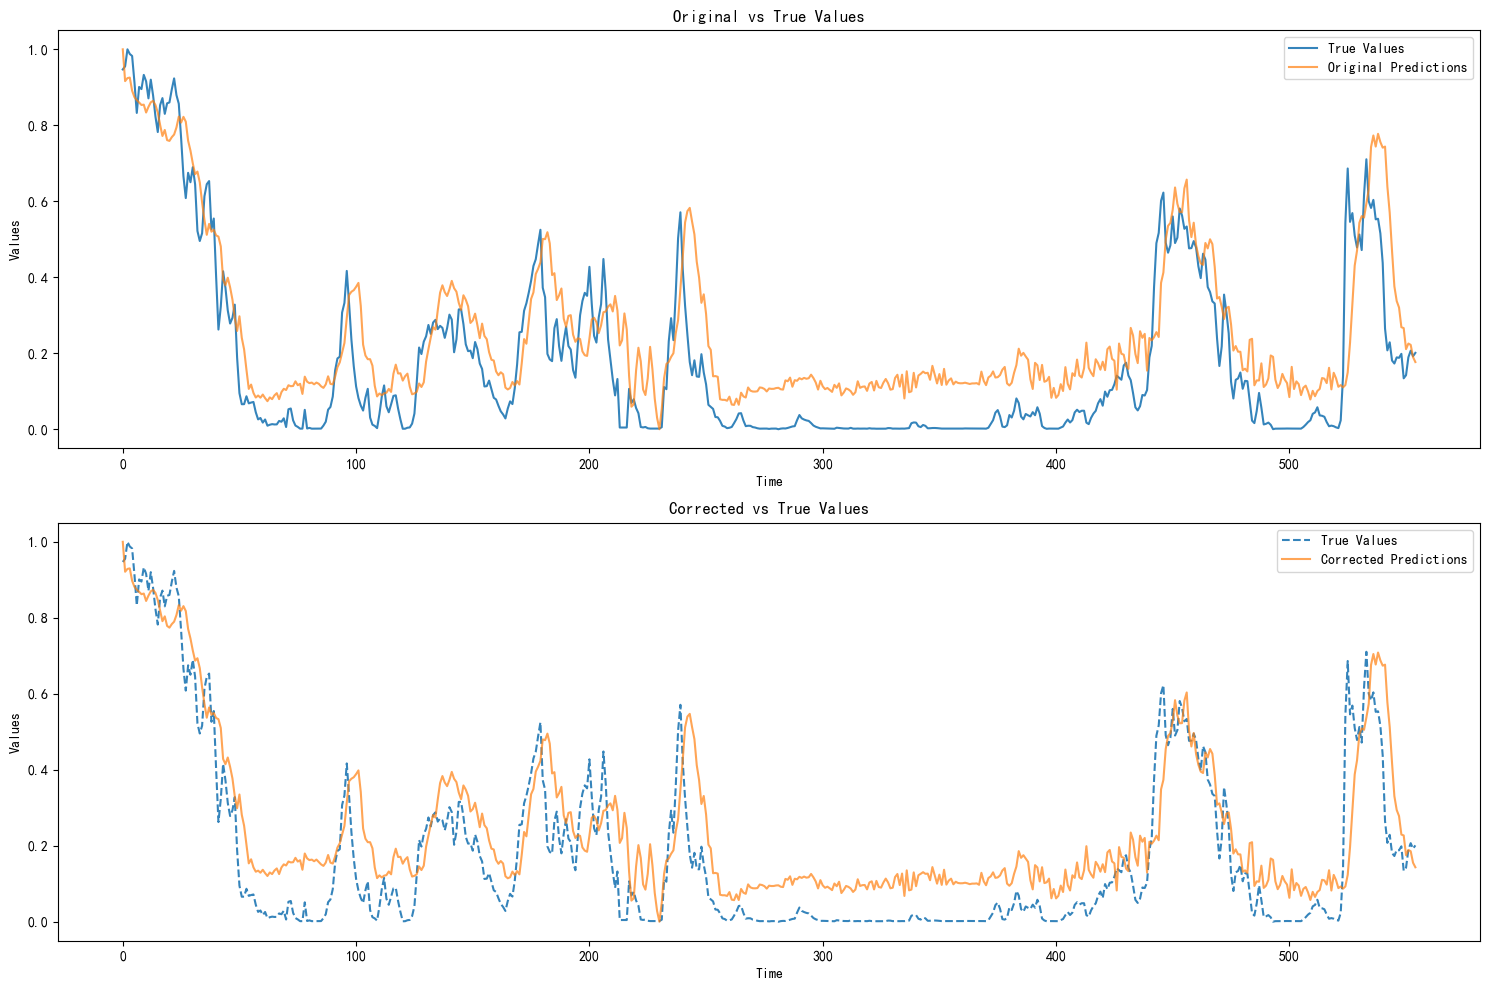

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.linalg import svd, inv

np.random.seed(0)

# ==================== DMD工具函数 ====================

def build_hankel(series, m):
    """构造Hankel矩阵，m为嵌入维度"""
    N = len(series)
    H = np.zeros((m, N - m + 1))
    for i in range(m):
        H[i, :] = series[i:i + N - m + 1]
    return H

def dmd_fit(X_train, rank):
    X1 = X_train[:, :-1]  # 前N-1列
    X2 = X_train[:, 1:]   # 后N-1列
    
    U, S, Vh = svd(X1, full_matrices=False)
    U_r = U[:, :rank]
    S_r = np.diag(S[:rank])
    Vh_r = Vh[:rank, :]
    
    # 拟合降阶DMD算子
    A_tilde = U_r.T @ X2 @ Vh_r.T @ inv(S_r)
    eigenvalues, eigenvectors = np.linalg.eig(A_tilde)
    
    # 计算全阶DMD模态
    phi = X2 @ Vh_r.T @ inv(S_r) @ eigenvectors
    
    # 计算初始模态振幅
    b = np.linalg.pinv(phi) @ X1[:, 0]
    
    return phi, eigenvalues, b

def dmd_step_predict(phi, eigenvalues, current_state):
    """用训练好的DMD算子做一步前向预测"""
    # 将当前状态投影到模态空间，一步推进
    proj = np.linalg.pinv(phi) @ current_state
    next_proj = eigenvalues * proj
    return phi @ next_proj

scaler = MinMaxScaler()
scaler.fit(train_itransformer_error.reshape(-1, 1))  # 只用训练集fit

train_error_norm = scaler.transform(train_itransformer_error.reshape(-1, 1)).flatten()
test_error_norm = scaler.transform(spring_itransformer_error.values.reshape(-1, 1)).flatten()
y_pre_norm = scaler.transform(y_pre_itransformer.values.reshape(-1, 1)).flatten()
y_test_norm = scaler.transform(y_spring_test.values.reshape(-1, 1)).flatten()


m = 12   # 嵌入维度
r = 5    # 截断秩

X_train_hankel = build_hankel(train_error_norm, m)
phi, eigenvalues, b = dmd_fit(X_train_hankel, rank=r)

n_test = len(test_error_norm)
corrected_test_error = np.zeros(n_test)

corrected_test_error[:m] = test_error_norm[:m]

for t in range(m, n_test):
    # 只用t时刻之前的m个点构造状态
    current_state = test_error_norm[t - m:t]
    # DMD一步前向预测残差变化
    dmd_pred = dmd_step_predict(phi, eigenvalues, current_state)
    # 修正当前时刻误差
    correction_strength = 0.2
    corrected_test_error[t] = test_error_norm[t] + correction_strength * dmd_pred[-1]

corrected_predictions_norm = y_pre_norm + corrected_test_error

# 反归一化
corrected_predictions = scaler.inverse_transform(corrected_predictions_norm.reshape(-1, 1)).flatten()

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.title("Original vs True Values")
plt.plot(y_test_norm, label='True Values', alpha=0.9)
plt.plot(y_pre_norm, label='Original Predictions', alpha=0.7)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Values")

plt.subplot(2, 1, 2)
plt.title("Corrected vs True Values")
plt.plot(y_test_norm, label='True Values', linestyle='--', alpha=0.9)
plt.plot(corrected_predictions_norm, label='Corrected Predictions', alpha=0.7)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Values")

plt.tight_layout()
plt.show()

In [64]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 计算原始预测的误差指标
original_R2 = r2_score(y_spring_test.values, y_pre_itransformer.values)
original_mse = mean_squared_error(y_spring_test.values, y_pre_itransformer.values)
original_rmse = np.sqrt(original_mse)
original_mae = mean_absolute_error(y_spring_test.values, y_pre_itransformer.values)

# 计算修正后预测的误差指标（用反归一化后的原始量纲）
corrected_R2 = r2_score(y_spring_test.values, corrected_predictions)
corrected_mse = mean_squared_error(y_spring_test.values, corrected_predictions)
corrected_rmse = np.sqrt(corrected_mse)
corrected_mae = mean_absolute_error(y_spring_test.values, corrected_predictions)

print(f"Original - R2: {original_R2:.4f}, MSE: {original_mse:.4f}, RMSE: {original_rmse:.4f}, MAE: {original_mae:.4f}")
print(f"Corrected - R2: {corrected_R2:.4f}, MSE: {corrected_mse:.4f}, RMSE: {corrected_rmse:.4f}, MAE: {corrected_mae:.4f}")

# 计算变化率
R2_change = ((corrected_R2 - original_R2) / abs(original_R2)) * 100
mse_reduction = ((original_mse - corrected_mse) / original_mse) * 100
rmse_reduction = ((original_rmse - corrected_rmse) / original_rmse) * 100
mae_reduction = ((original_mae - corrected_mae) / original_mae) * 100

print(f"\nR2 Improvement: {R2_change:.2f}%")
print(f"MSE Reduction: {mse_reduction:.2f}%")
print(f"RMSE Reduction: {rmse_reduction:.2f}%")
print(f"MAE Reduction: {mae_reduction:.2f}%")

Original Predictions - R2: 0.706003282001382,MSE: 0.01628281004257426, RMSE: 0.12760411452055243, MAE: 0.10765601194976566
Corrected Predictions - R2: 0.7356025573834538, MSE: 0.014643474128469306, RMSE: 0.12101022323948216, MAE: 0.10087440166976629
R2 Reduction: -4.19251243395975%
MSE Reduction: 10.067893132810743%
RMSE Reduction: 5.167459768711636%
MAE Reduction: 6.299332621724652%


In [66]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 取出各列
y_pre_lstm = point_prediction_error_df.iloc[:, 2].to_frame(name='y_pre_lstm')
spring_lstm_error = point_prediction_error_df.iloc[:, 3].to_frame(name='spring_lstm_error')
y_spring_test = point_prediction_error_df.iloc[:, -1].to_frame(name='y_spring_test')
scaler = MinMaxScaler()
scaler.fit(train_lstm_error.reshape(-1, 1))

# 所有变量都用同一个scaler transform
y_pre_lstm_normalized = pd.DataFrame(scaler.transform(y_pre_lstm), columns=y_pre_lstm.columns, index=y_pre_lstm.index)
spring_lstm_error_normalized = pd.DataFrame(scaler.transform(spring_lstm_error), columns=spring_lstm_error.columns, index=spring_lstm_error.index)
y_spring_test_normalized = pd.DataFrame(scaler.transform(y_spring_test), columns=y_spring_test.columns, index=y_spring_test.index)

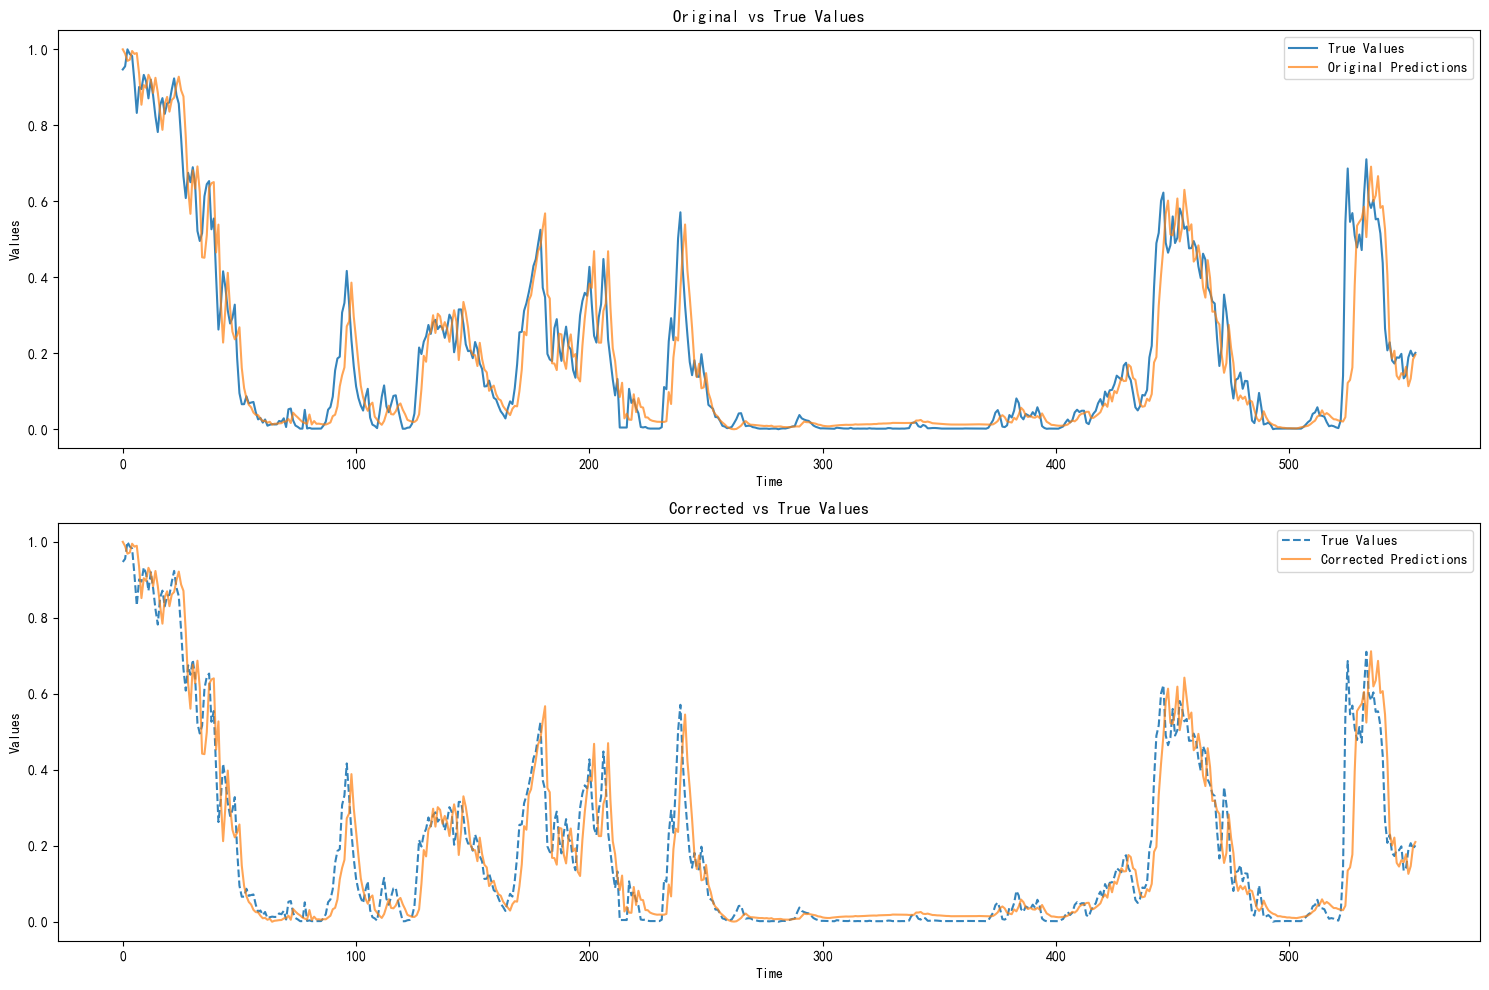

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.linalg import svd, inv

np.random.seed(0)

# ==================== DMD工具函数 ====================

def build_hankel(series, m):
    N = len(series)
    H = np.zeros((m, N - m + 1))
    for i in range(m):
        H[i, :] = series[i:i + N - m + 1]
    return H

def dmd_fit(X_train, rank):
    X1 = X_train[:, :-1]
    X2 = X_train[:, 1:]
    U, S, Vh = svd(X1, full_matrices=False)
    U_r = U[:, :rank]
    S_r = np.diag(S[:rank])
    Vh_r = Vh[:rank, :]
    A_tilde = U_r.T @ X2 @ Vh_r.T @ inv(S_r)
    eigenvalues, eigenvectors = np.linalg.eig(A_tilde)
    phi = X2 @ Vh_r.T @ inv(S_r) @ eigenvectors
    b = np.linalg.pinv(phi) @ X1[:, 0]
    return phi, eigenvalues, b

def dmd_step_predict(phi, eigenvalues, current_state):
    proj = np.linalg.pinv(phi) @ current_state
    next_proj = eigenvalues * proj
    return phi @ next_proj

scaler = MinMaxScaler()
scaler.fit(train_lstm_error.reshape(-1, 1))

train_error_norm = scaler.transform(train_lstm_error.reshape(-1, 1)).flatten()
test_error_norm = scaler.transform(spring_lstm_error.values.reshape(-1, 1)).flatten()
y_pre_norm = scaler.transform(y_pre_lstm.values.reshape(-1, 1)).flatten()
y_test_norm = scaler.transform(y_spring_test.values.reshape(-1, 1)).flatten()

# 拟合DMD算子
m = 12   # 嵌入维度
r = 5    # 截断秩（与论文一致）

X_train_hankel = build_hankel(train_error_norm, m)
phi, eigenvalues, b = dmd_fit(X_train_hankel, rank=r)

# 逐点因果修正
n_test = len(test_error_norm)
corrected_test_error = np.zeros(n_test)
corrected_test_error[:m] = test_error_norm[:m]

correction_strength = 0.2

for t in range(m, n_test):
    current_state = test_error_norm[t - m:t]
    dmd_pred = dmd_step_predict(phi, eigenvalues, current_state)
    corrected_test_error[t] = test_error_norm[t] + correction_strength * dmd_pred[-1]

corrected_predictions_norm = y_pre_norm + corrected_test_error
corrected_predictions = scaler.inverse_transform(corrected_predictions_norm.reshape(-1, 1)).flatten()

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.title("Original vs True Values")
plt.plot(y_test_norm, label='True Values', alpha=0.9)
plt.plot(y_pre_norm, label='Original Predictions', alpha=0.7)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Values")

plt.subplot(2, 1, 2)
plt.title("Corrected vs True Values")
plt.plot(y_test_norm, label='True Values', linestyle='--', alpha=0.9)
plt.plot(corrected_predictions_norm, label='Corrected Predictions', alpha=0.7)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Values")

plt.tight_layout()
plt.show()

In [90]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 建议用原始量纲计算
original_R2 = r2_score(y_spring_test.values, y_pre_lstm.values)
original_mse = mean_squared_error(y_spring_test.values, y_pre_lstm.values)
original_rmse = np.sqrt(original_mse)
original_mae = mean_absolute_error(y_spring_test.values, y_pre_lstm.values)

# 修正后（corrected_predictions 是反归一化后的结果）
corrected_R2 = r2_score(y_spring_test.values, corrected_predictions)
corrected_mse = mean_squared_error(y_spring_test.values, corrected_predictions)
corrected_rmse = np.sqrt(corrected_mse)
corrected_mae = mean_absolute_error(y_spring_test.values, corrected_predictions)

print(f"Original - R2: {original_R2:.4f}, MSE: {original_mse:.4f}, RMSE: {original_rmse:.4f}, MAE: {original_mae:.4f}")
print(f"Corrected - R2: {corrected_R2:.4f}, MSE: {corrected_mse:.4f}, RMSE: {corrected_rmse:.4f}, MAE: {corrected_mae:.4f}")

# R2是越大越好，算提升率
R2_improvement = ((corrected_R2 - original_R2) / abs(original_R2)) * 100
# 误差指标越小越好，算减少率
mse_reduction = ((original_mse - corrected_mse) / original_mse) * 100
rmse_reduction = ((original_rmse - corrected_rmse) / original_rmse) * 100
mae_reduction = ((original_mae - corrected_mae) / original_mae) * 100

print(f"\nR2 Improvement: {R2_improvement:.2f}%")
print(f"MSE Reduction: {mse_reduction:.2f}%")
print(f"RMSE Reduction: {rmse_reduction:.2f}%")
print(f"MAE Reduction: {mae_reduction:.2f}%")

Original Predictions - R2: 0.887965447696412,MSE: 0.006204958156617076, RMSE: 0.07877155677411153, MAE: 0.04641979388330639
Corrected Predictions - R2: 0.8880921733314233, MSE: 0.006197939542747976, RMSE: 0.07872699373625273, MAE: 0.047264403005460545
R2 Reduction: -0.014271460149730674%
MSE Reduction: 0.11311299273815419%
RMSE Reduction: 0.05657249860706403%
MAE Reduction: -1.8195020948981393%


In [91]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 取出各列
y_pre_tcn = point_prediction_error_df.iloc[:, 4].to_frame(name='y_pre_tcn')
spring_tcn_error = point_prediction_error_df.iloc[:, 5].to_frame(name='spring_tcn_error')
y_spring_test = point_prediction_error_df.iloc[:, -1].to_frame(name='y_spring_test')

scaler = MinMaxScaler()
scaler.fit(train_tcn_error.reshape(-1, 1))

# 所有变量都用同一个scaler transform
y_pre_tcn_normalized = pd.DataFrame(scaler.transform(y_pre_tcn), columns=y_pre_tcn.columns, index=y_pre_tcn.index)
spring_tcn_error_normalized = pd.DataFrame(scaler.transform(spring_tcn_error), columns=spring_tcn_error.columns, index=spring_tcn_error.index)
y_spring_test_normalized = pd.DataFrame(scaler.transform(y_spring_test), columns=y_spring_test.columns, index=y_spring_test.index)

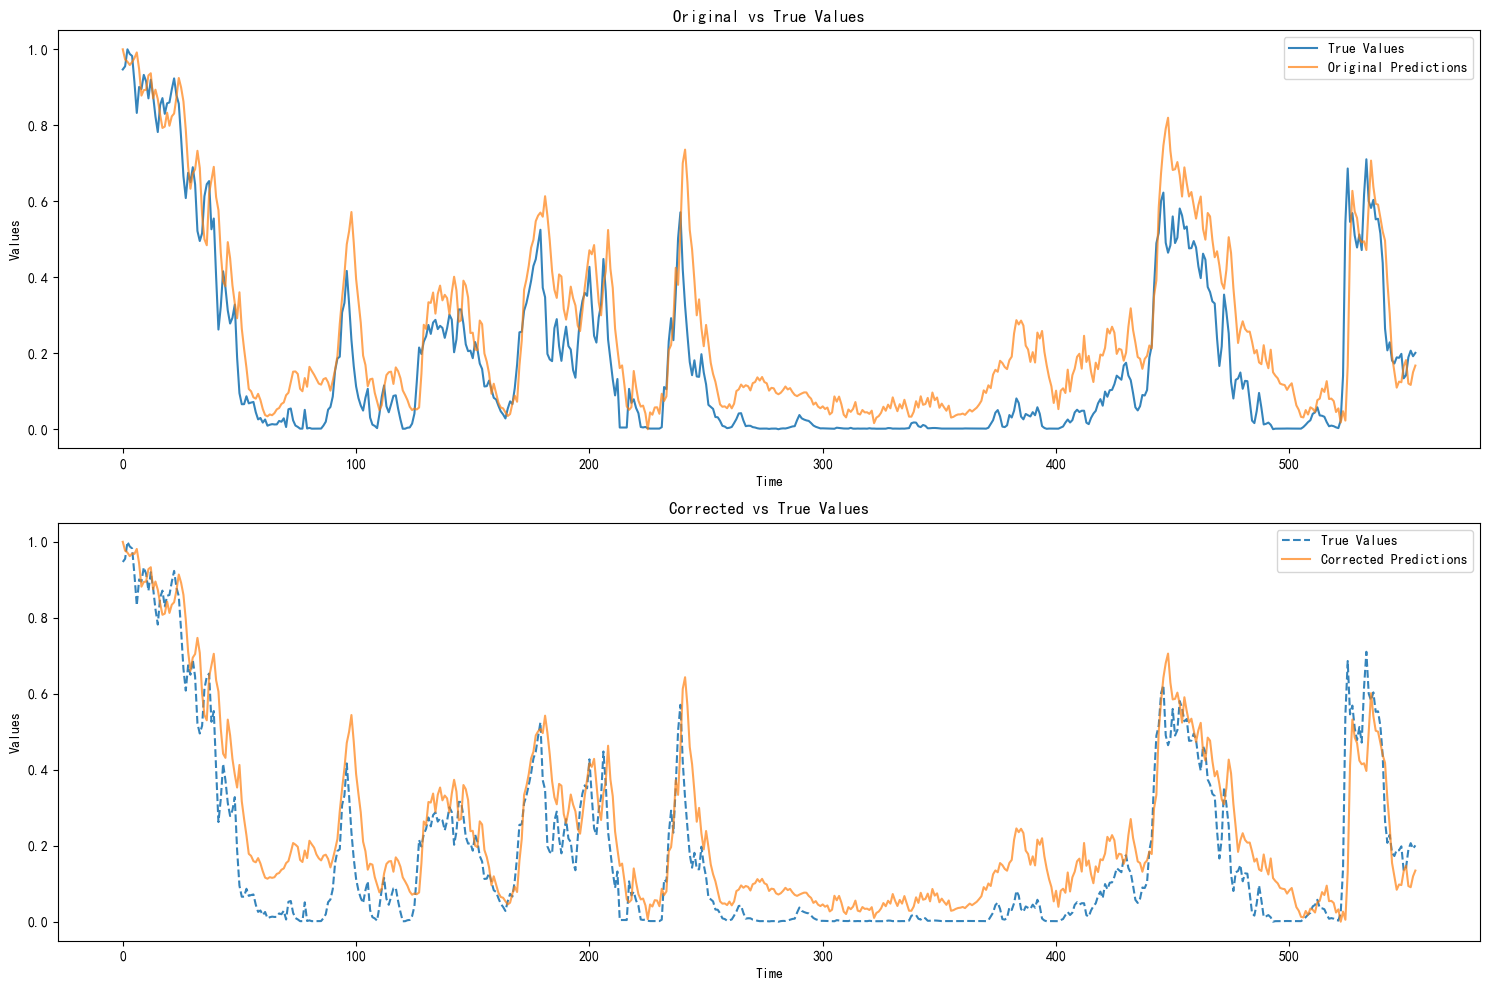

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.linalg import svd, inv

np.random.seed(0)

def build_hankel(series, m):
    N = len(series)
    H = np.zeros((m, N - m + 1))
    for i in range(m):
        H[i, :] = series[i:i + N - m + 1]
    return H

def dmd_fit(X_train, rank):
    X1 = X_train[:, :-1]
    X2 = X_train[:, 1:]
    U, S, Vh = svd(X1, full_matrices=False)
    U_r = U[:, :rank]
    S_r = np.diag(S[:rank])
    Vh_r = Vh[:rank, :]
    A_tilde = U_r.T @ X2 @ Vh_r.T @ inv(S_r)
    eigenvalues, eigenvectors = np.linalg.eig(A_tilde)
    phi = X2 @ Vh_r.T @ inv(S_r) @ eigenvectors
    return phi, eigenvalues

def dmd_step_predict(phi, eigenvalues, current_state):
    proj = np.linalg.pinv(phi) @ current_state
    next_proj = eigenvalues * proj
    return phi @ next_proj

# 归一化
scaler = MinMaxScaler()
scaler.fit(train_tcn_error.reshape(-1, 1))  # train_tcn_error替换成你的训练集残差

train_error_norm = scaler.transform(train_tcn_error.reshape(-1, 1)).flatten()
test_error_norm = scaler.transform(spring_tcn_error.values.reshape(-1, 1)).flatten()
y_pre_norm = scaler.transform(y_pre_tcn.values.reshape(-1, 1)).flatten()
y_test_norm = scaler.transform(y_spring_test.values.reshape(-1, 1)).flatten()

#训练集拟合DMD
m, r = 12, 5
X_train_hankel = build_hankel(train_error_norm, m)
phi, eigenvalues = dmd_fit(X_train_hankel, rank=r)

#测试集因果修正
n_test = len(test_error_norm)
corrected_test_error = np.zeros(n_test)
corrected_test_error[:m] = test_error_norm[:m]
correction_strength = 0.2

for t in range(m, n_test):
    current_state = test_error_norm[t - m:t]
    dmd_pred = dmd_step_predict(phi, eigenvalues, current_state)
    corrected_test_error[t] = test_error_norm[t] + correction_strength * dmd_pred[-1]

#修正后预测值
corrected_predictions_norm = y_pre_norm + corrected_test_error
corrected_predictions = scaler.inverse_transform(corrected_predictions_norm.reshape(-1, 1)).flatten()

#画图
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)
plt.plot(y_test_norm, label='True Values', alpha=0.9)
plt.plot(y_pre_norm, label='Original Predictions', alpha=0.7)
plt.title("Original vs True Values")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(y_test_norm, label='True Values', linestyle='--', alpha=0.9)
plt.plot(corrected_predictions_norm, label='Corrected Predictions', alpha=0.7)
plt.title("Corrected vs True Values")
plt.legend()
plt.tight_layout()
plt.show()

In [93]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 用原始量纲计算
original_R2 = r2_score(y_spring_test.values, y_pre_tcn.values)
original_mse = mean_squared_error(y_spring_test.values, y_pre_tcn.values)
original_rmse = np.sqrt(original_mse)
original_mae = mean_absolute_error(y_spring_test.values, y_pre_tcn.values)

# 修正后
corrected_R2 = r2_score(y_spring_test.values, corrected_predictions)
corrected_mse = mean_squared_error(y_spring_test.values, corrected_predictions)
corrected_rmse = np.sqrt(corrected_mse)
corrected_mae = mean_absolute_error(y_spring_test.values, corrected_predictions)

print(f"Original - R2: {original_R2:.4f}, MSE: {original_mse:.4f}, RMSE: {original_rmse:.4f}, MAE: {original_mae:.4f}")
print(f"Corrected - R2: {corrected_R2:.4f}, MSE: {corrected_mse:.4f}, RMSE: {corrected_rmse:.4f}, MAE: {corrected_mae:.4f}")

# R2越大越好，算提升率
R2_improvement = ((corrected_R2 - original_R2) / abs(original_R2)) * 100
# 误差越小越好，算减少率
mse_reduction = ((original_mse - corrected_mse) / original_mse) * 100
rmse_reduction = ((original_rmse - corrected_rmse) / original_rmse) * 100
mae_reduction = ((original_mae - corrected_mae) / original_mae) * 100

print(f"\nR2 Improvement: {R2_improvement:.2f}%")
print(f"MSE Reduction: {mse_reduction:.2f}%")
print(f"RMSE Reduction: {rmse_reduction:.2f}%")
print(f"MAE Reduction: {mae_reduction:.2f}%")

Original Predictions - R2: 0.7257931650948066,MSE: 0.015186760707844948, RMSE: 0.12323457594297531, MAE: 0.097328163052734
Corrected Predictions - R2: 0.7811297098624117, MSE: 0.01212198347836732, RMSE: 0.11009987955655229, MAE: 0.08577782930349621
R2 Reduction: -7.624285737159946%
MSE Reduction: 20.180585500991473%
RMSE Reduction: 10.658288297677817%
MAE Reduction: 11.867411638067834%


In [94]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

y_pre_gru = point_prediction_error_df.iloc[:, 6].to_frame(name='y_pre_gru')
spring_gru_error = point_prediction_error_df.iloc[:, 7].to_frame(name='spring_gru_error')
y_spring_test = point_prediction_error_df.iloc[:, -1].to_frame(name='y_spring_test')

# 只用训练集fit scaler
scaler = MinMaxScaler()
scaler.fit(train_gru_error.reshape(-1, 1))

y_pre_gru_normalized = pd.DataFrame(scaler.transform(y_pre_gru), columns=y_pre_gru.columns, index=y_pre_gru.index)
spring_gru_error_normalized = pd.DataFrame(scaler.transform(spring_gru_error), columns=spring_gru_error.columns, index=spring_gru_error.index)
y_spring_test_normalized = pd.DataFrame(scaler.transform(y_spring_test), columns=y_spring_test.columns, index=y_spring_test.index)

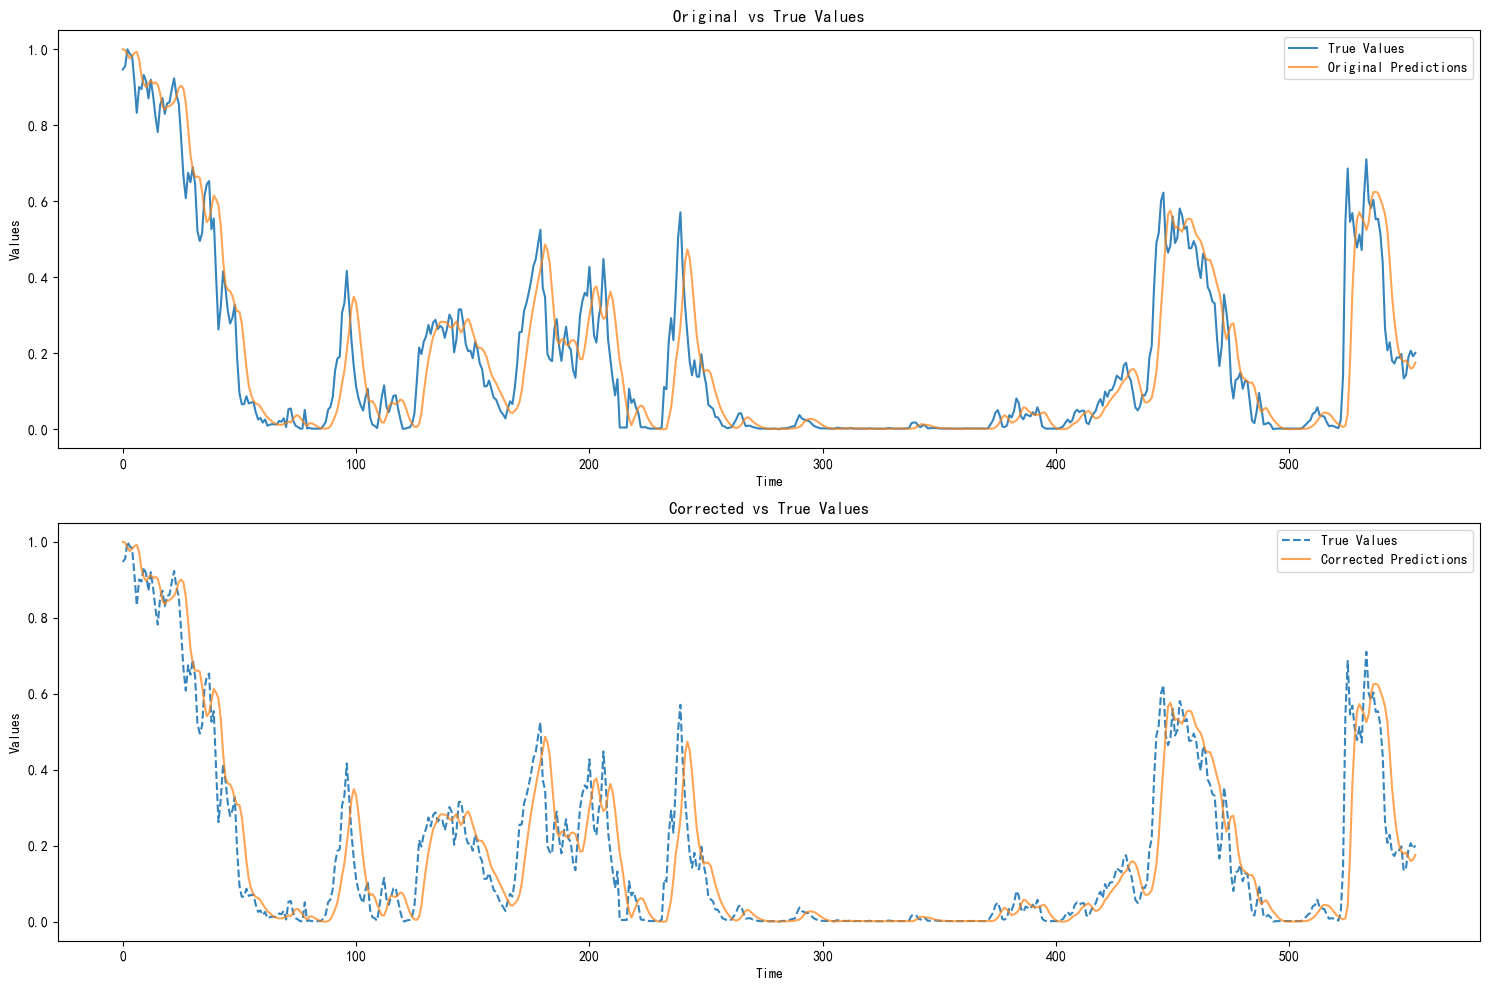

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.linalg import svd, inv

np.random.seed(0)

def build_hankel(series, m):
    N = len(series)
    H = np.zeros((m, N - m + 1))
    for i in range(m):
        H[i, :] = series[i:i + N - m + 1]
    return H

def dmd_fit(X_train, rank):
    X1 = X_train[:, :-1]
    X2 = X_train[:, 1:]
    U, S, Vh = svd(X1, full_matrices=False)
    U_r = U[:, :rank]
    S_r = np.diag(S[:rank])
    Vh_r = Vh[:rank, :]
    A_tilde = U_r.T @ X2 @ Vh_r.T @ inv(S_r)
    eigenvalues, eigenvectors = np.linalg.eig(A_tilde)
    phi = X2 @ Vh_r.T @ inv(S_r) @ eigenvectors
    return phi, eigenvalues

def dmd_step_predict(phi, eigenvalues, current_state):
    proj = np.linalg.pinv(phi) @ current_state
    next_proj = eigenvalues * proj
    return phi @ next_proj

#归一化
scaler = MinMaxScaler()
scaler.fit(train_gru_error.reshape(-1, 1))  # train_gru_error替换成你的训练集残差

train_error_norm = scaler.transform(train_gru_error.reshape(-1, 1)).flatten()
test_error_norm = scaler.transform(spring_gru_error.values.reshape(-1, 1)).flatten()
y_pre_norm = scaler.transform(y_pre_gru.values.reshape(-1, 1)).flatten()
y_test_norm = scaler.transform(y_spring_test.values.reshape(-1, 1)).flatten()

#训练集拟合DMD
m, r = 12, 5
X_train_hankel = build_hankel(train_error_norm, m)
phi, eigenvalues = dmd_fit(X_train_hankel, rank=r)

#测试集因果修正
n_test = len(test_error_norm)
corrected_test_error = np.zeros(n_test)
corrected_test_error[:m] = test_error_norm[:m]
correction_strength = 0.2

for t in range(m, n_test):
    current_state = test_error_norm[t - m:t]
    dmd_pred = dmd_step_predict(phi, eigenvalues, current_state)
    corrected_test_error[t] = test_error_norm[t] + correction_strength * dmd_pred[-1]

# 修正后预测值
corrected_predictions_norm = y_pre_norm + corrected_test_error
corrected_predictions = scaler.inverse_transform(corrected_predictions_norm.reshape(-1, 1)).flatten()

# 画图
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)
plt.plot(y_test_norm, label='True Values', alpha=0.9)
plt.plot(y_pre_norm, label='Original Predictions', alpha=0.7)
plt.title("Original vs True Values")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(y_test_norm, label='True Values', linestyle='--', alpha=0.9)
plt.plot(corrected_predictions_norm, label='Corrected Predictions', alpha=0.7)
plt.title("Corrected vs True Values")
plt.legend()
plt.tight_layout()
plt.show()

In [96]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# 原始预测指标
original_R2_gru = r2_score(y_spring_test.values, y_pre_gru.values)
original_gru_mse = mean_squared_error(y_spring_test.values, y_pre_gru.values)
original_gru_rmse = np.sqrt(original_gru_mse)
original_gru_mae = mean_absolute_error(y_spring_test.values, y_pre_gru.values)

# 修正后预测指标
corrected_R2_gru = r2_score(y_spring_test.values, corrected_gru_predictions)
corrected_gru_mse = mean_squared_error(y_spring_test.values, corrected_gru_predictions)
corrected_gru_rmse = np.sqrt(corrected_gru_mse)
corrected_gru_mae = mean_absolute_error(y_spring_test.values, corrected_gru_predictions)

print(f"Original - R2: {original_R2_gru:.4f}, MSE: {original_gru_mse:.4f}, RMSE: {original_gru_rmse:.4f}, MAE: {original_gru_mae:.4f}")
print(f"Corrected - R2: {corrected_R2_gru:.4f}, MSE: {corrected_gru_mse:.4f}, RMSE: {corrected_gru_rmse:.4f}, MAE: {corrected_gru_mae:.4f}")

# R2越大越好，算提升率
R2_gru_improvement = ((corrected_R2_gru - original_R2_gru) / abs(original_R2_gru)) * 100
# 误差指标越小越好，算减少率
mse_gru_reduction = ((original_gru_mse - corrected_gru_mse) / original_gru_mse) * 100
rmse_gru_reduction = ((original_gru_rmse - corrected_gru_rmse) / original_gru_rmse) * 100
mae_gru_reduction = ((original_gru_mae - corrected_gru_mae) / original_gru_mae) * 100

print(f"\nR2 Improvement: {R2_gru_improvement:.2f}%")
print(f"MSE Reduction: {mse_gru_reduction:.2f}%")
print(f"RMSE Reduction: {rmse_gru_reduction:.2f}%")
print(f"MAE Reduction: {mae_gru_reduction:.2f}%")

Original Predictions - R2: 0.8464352081832776,MSE: 0.008505082476433999, RMSE: 0.09222300405231874, MAE: 0.05484987294508237
Corrected Predictions - R2: 0.8468025961780671, MSE: 0.008484734939999565, RMSE: 0.09211262095934283, MAE: 0.05475729078034003
R2 Reduction: -0.043404148508668285%
MSE Reduction: 0.2392397309586708%
RMSE Reduction: 0.11969149575011592%
MAE Reduction: 0.168791940202004%


In [97]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 提取对应列
y_pre_rnn = point_prediction_error_df.iloc[:, 8].to_frame(name='y_pre_rnn')
spring_rnn_error = point_prediction_error_df.iloc[:, 9].to_frame(name='spring_rnn_error')
y_spring_test = point_prediction_error_df.iloc[:, -1].to_frame(name='y_spring_test')

# 测试集归一化
scaler = MinMaxScaler()
scaler.fit(train_rnn_error.reshape(-1, 1))

# 统一使用训练集scaler归一化所有测试数据
y_pre_rnn_normalized = pd.DataFrame(
    scaler.transform(y_pre_rnn),
    columns=y_pre_rnn.columns,
    index=y_pre_rnn.index
)
spring_rnn_error_normalized = pd.DataFrame(
    scaler.transform(spring_rnn_error),
    columns=spring_rnn_error.columns,
    index=spring_rnn_error.index
)
y_spring_test_normalized = pd.DataFrame(
    scaler.transform(y_spring_test),
    columns=y_spring_test.columns,
    index=y_spring_test.index
)

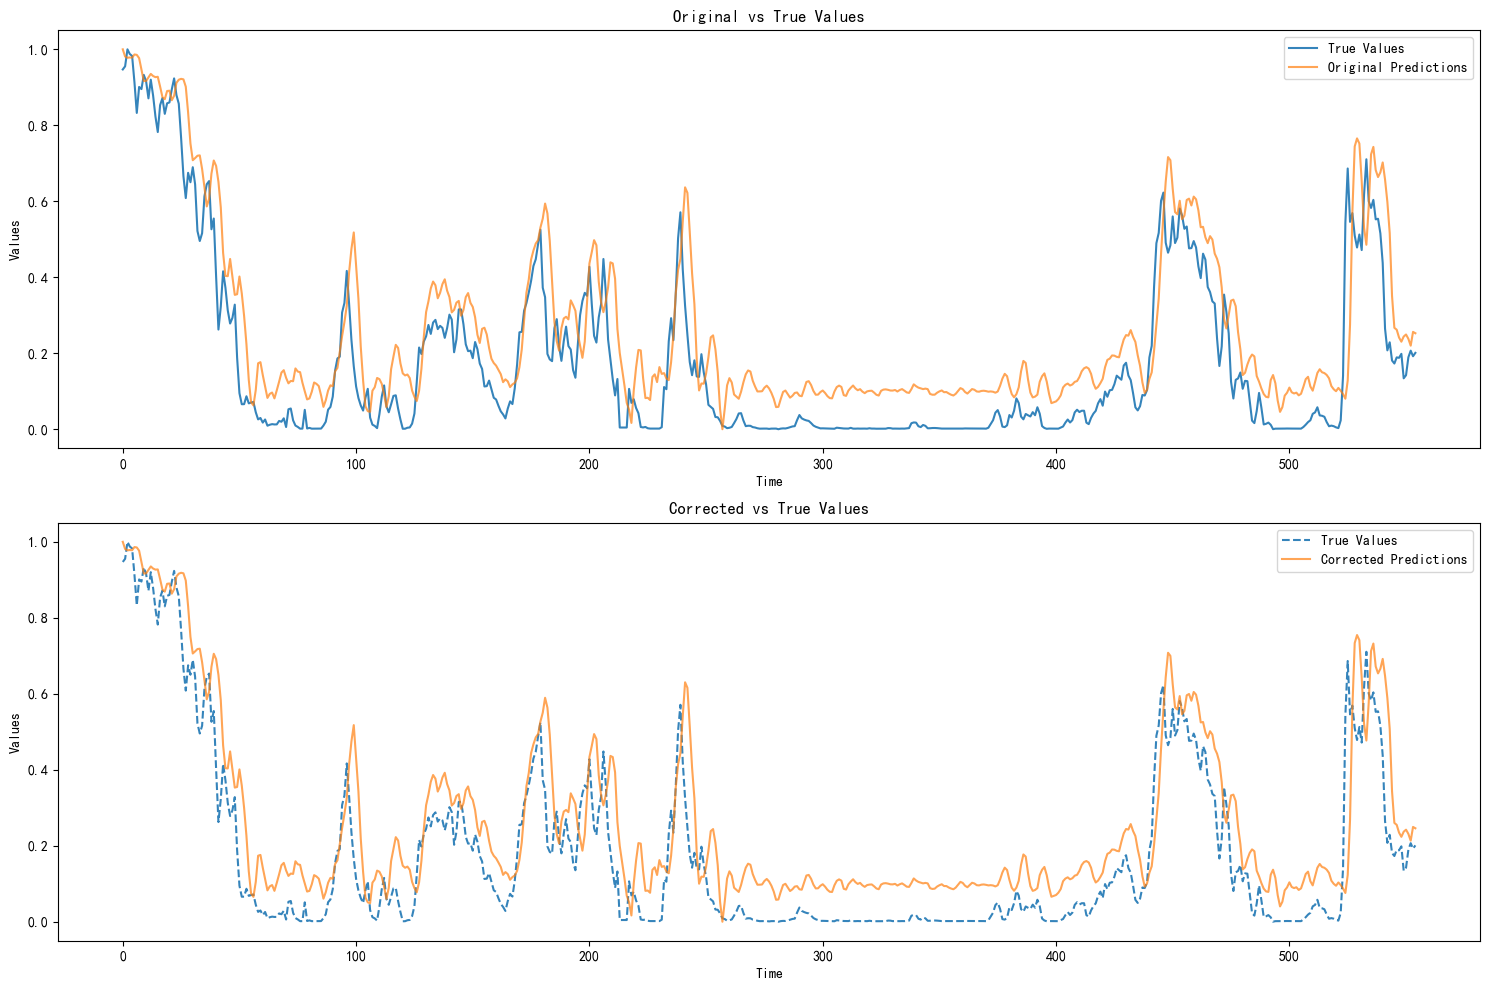

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.linalg import svd, inv

np.random.seed(0)

# 标准DMD工具函数（仅训练集拟合）
def build_hankel(series, m):
    N = len(series)
    H = np.zeros((m, N - m + 1))
    for i in range(m):
        H[i, :] = series[i:i + N - m + 1]
    return H

def dmd_fit(X_train, rank):
    X1 = X_train[:, :-1]
    X2 = X_train[:, 1:]
    U, S, Vh = svd(X1, full_matrices=False)
    U_r = U[:, :rank]
    S_r = np.diag(S[:rank])
    Vh_r = Vh[:rank, :]
    A_tilde = U_r.T @ X2 @ Vh_r.T @ inv(S_r)
    eigenvalues, eigenvectors = np.linalg.eig(A_tilde)
    phi = X2 @ Vh_r.T @ inv(S_r) @ eigenvectors
    return phi, eigenvalues

def dmd_step_predict(phi, eigenvalues, current_state):
    proj = np.linalg.pinv(phi) @ current_state
    next_proj = eigenvalues * proj
    return phi @ next_proj

# 归一化
scaler = MinMaxScaler()
scaler.fit(train_rnn_error.reshape(-1, 1))

train_error_norm = scaler.transform(train_rnn_error.reshape(-1, 1)).flatten()
test_error_norm = scaler.transform(spring_rnn_error.values.reshape(-1, 1)).flatten()
y_pre_norm = scaler.transform(y_pre_rnn.values.reshape(-1, 1)).flatten()
y_test_norm = scaler.transform(y_spring_test.values.reshape(-1, 1)).flatten()

# 拟合DMD算子
m = 12   # 嵌入维度
r = 5    # 截断秩，和论文保持一致
X_train_hankel = build_hankel(train_error_norm)
phi, eigenvalues = dmd_fit(X_train_hankel, rank=r)

# 逐点因果修正
n_test = len(test_error_norm)
corrected_test_error = np.zeros(n_test)
corrected_test_error[:m] = test_error_norm[:m]
correction_strength = 0.2

for t in range(m, n_test):
    current_state = test_error_norm[t - m:t]
    dmd_pred = dmd_step_predict(phi, eigenvalues, current_state)
    corrected_test_error[t] = test_error_norm[t] + correction_strength * dmd_pred[-1]

corrected_predictions_norm = y_pre_norm + corrected_test_error
corrected_predictions = scaler.inverse_transform(corrected_predictions_norm.reshape(-1, 1)).flatten()

plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)
plt.title("Original vs True Values")
plt.plot(y_test_norm, label='True Values', alpha=0.9)
plt.plot(y_pre_norm, label='Original Predictions', alpha=0.7)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Values")

plt.subplot(2, 1, 2)
plt.title("Corrected vs True Values")
plt.plot(y_test_norm, label='True Values', linestyle='--', alpha=0.9)
plt.plot(corrected_predictions_norm, label='Corrected Predictions', alpha=0.7)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Values")
plt.tight_layout()
plt.show()

In [99]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

original_R2_rnn = r2_score(y_spring_test.values, y_pre_rnn.values)
original_rnn_mse = mean_squared_error(y_spring_test.values, y_pre_rnn.values)
original_rnn_rmse = np.sqrt(original_rnn_mse)
original_rnn_mae = mean_absolute_error(y_spring_test.values, y_pre_rnn.values)

corrected_R2_rnn = r2_score(y_spring_test.values, corrected_predictions)
corrected_rnn_mse = mean_squared_error(y_spring_test.values, corrected_predictions)
corrected_rnn_rmse = np.sqrt(corrected_rnn_mse)
corrected_rnn_mae = mean_absolute_error(y_spring_test.values, corrected_predictions)

print(f"Original - R2: {original_R2_rnn:.4f}, MSE: {original_rnn_mse:.4f}, RMSE: {original_rnn_rmse:.4f}, MAE: {original_rnn_mae:.4f}")
print(f"Corrected - R2: {corrected_R2_rnn:.4f}, MSE: {corrected_rnn_mse:.4f}, RMSE: {corrected_rnn_rmse:.4f}, MAE: {corrected_rnn_mae:.4f}")

# R2越大越好，计算提升比例；误差指标越小越好，计算下降比例
R2_rnn_improvement = ((corrected_R2_rnn - original_R2_rnn) / abs(original_R2_rnn)) * 100
mse_rnn_reduction = ((original_rnn_mse - corrected_rnn_mse) / original_rnn_mse) * 100
rmse_rnn_reduction = ((original_rnn_rmse - corrected_rnn_rmse) / original_rnn_rmse) * 100
mae_rnn_reduction = ((original_rnn_mae - corrected_rnn_mae) / original_rnn_mae) * 100

print(f"\nR2 Improvement: {R2_rnn_improvement:.2f}%")
print(f"MSE Reduction: {mse_rnn_reduction:.2f}%")
print(f"RMSE Reduction: {rmse_rnn_reduction:.2f}%")
print(f"MAE Reduction: {mae_rnn_reduction:.2f}%")

Original Predictions - R2: 0.7135943564186453,MSE: 0.015862383503132665, RMSE: 0.1259459546914178, MAE: 0.10398349206064092
Corrected Predictions - R2: 0.723674881444677, MSE: 0.015304080419868107, RMSE: 0.123709661788674, MAE: 0.10160014115631888
R2 Reduction: -1.4126408001071231%
MSE Reduction: 3.5196670358795616%
RMSE Reduction: 1.7755972458369054%
MAE Reduction: 2.29204737895523%


In [101]:
#将DMD修正后的预测值进行反归一化
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import os

# 对归一化后的预测值进行反归一化
corrected_itransformer_predictions = scaler.inverse_transform(corrected_itransformer_predictions_normalized)
corrected_lstm_predictions = scaler.inverse_transform(corrected_lstm_predictions_normalized)
corrected_tcn_predictions = scaler.inverse_transform(corrected_tcn_predictions_normalized)
corrected_gru_predictions = scaler.inverse_transform(corrected_gru_predictions_normalized)
corrected_rnn_predictions = scaler.inverse_transform(corrected_rnn_predictions_normalized)

y_pre_itransformer_dmd = corrected_itransformer_predictions.flatten()
y_pre_lstm_dmd = corrected_lstm_predictions.flatten()
y_pre_tcn_dmd = corrected_tcn_predictions.flatten()
y_pre_gru_dmd = corrected_gru_predictions.flatten()
y_pre_rnn_dmd = corrected_rnn_predictions.flatten()

# 创建一个DataFrame
dmd_df = pd.DataFrame({
    'itranformer_DMD': y_pre_itransformer_dmd,
    'LSTM_DMD': y_pre_lstm_dmd,
    'TCN_DMD': y_pre_tcn_dmd,
    'GRU_DMD': y_pre_gru_dmd,
    'RNN_DMD': y_pre_rnn_dmd,
    'True_power': y_spring_test.values.flatten()
})

# 将合并后的 DataFrame 保存到 Excel 文件中
directory = 'D:\\article'
if not os.path.exists(directory):
    os.makedirs(directory)

file_path = os.path.join(directory, 'DMD_Corrected_Predictions.xlsx')
dmd_df.to_excel(file_path, index=False)

# 显示 DataFrame
dmd_df

,itranformer_DMD,LSTM_DMD,TCN_DMD,GRU_DMD,RNN_DMD
0,79.770902,79.770902,79.770902,79.770902,79.770902
1,80.374739,80.442530,80.430654,80.452016,80.435087
2,84.086216,84.126633,84.129473,84.143378,84.135589
3,83.070894,83.112904,83.103387,83.116834,83.119620
4,82.609437,82.707705,82.681730,82.694217,82.690477
...,...,...,...,...,...
550,12.266073,12.268810,12.238122,12.272810,12.333879
551,16.191032,16.127498,16.095288,16.172949,16.233688
552,17.622399,17.582713,17.526765,17.596472,17.650354
553,16.380238,16.422957,16.344176,16.388315,16.475288


In [44]:
import numpy as np
import pandas as pd
import os

# 生成随机数数据，并确保所有值都大于0
wind_power_cost = np.random.normal(0.033, 0.0165, 555)
wind_power_cost[wind_power_cost <= 0] = np.random.normal(0.033, 0.0165, np.sum(wind_power_cost <= 0))

# 确保可再生能源的成本高于风力发电的成本
renewable_energy_cost = np.maximum(wind_power_cost + np.random.normal(0.015, 0.01, 555), wind_power_cost)
renewable_energy_cost[renewable_energy_cost <= 0] = np.random.normal(0.048, 0.024, np.sum(renewable_energy_cost <= 0))

coal_power_cost = np.maximum(renewable_energy_cost + np.random.normal(0.05, 0.025, 555), renewable_energy_cost)
coal_power_cost[coal_power_cost <= 0] = np.random.normal(0.05, 0.025, np.sum(coal_power_cost <= 0))

# 确保放电成本是所有成本中最低的
storage_discharge_cost = np.min([wind_power_cost, renewable_energy_cost, coal_power_cost, np.random.normal(0.015, 0.008, 555)])
storage_discharge_cost = np.maximum(storage_discharge_cost - 0.001, np.random.normal(0.015, 0.008, 555))  # 确保放电成本大于0并且是最低的
storage_discharge_cost[storage_discharge_cost <= 0] = np.random.normal(0.010, 0.005, np.sum(storage_discharge_cost <= 0))

# 充电成本可以是放电成本的倍数，这里假设是放电成本的3倍
storage_charge_cost = np.random.normal(0.388, 0.144,555)
storage_charge_cost[storage_charge_cost <= 0] = np.random.normal(0.288, 0.144, np.sum(storage_charge_cost <= 0))

# 创建一个DataFrame来保存数据
cost_data = {
    "wind_power_cost": wind_power_cost,
    "renewable_energy_cost": renewable_energy_cost,
    "coal_power_cost": coal_power_cost,
    "storage_discharge_cost": storage_discharge_cost,
    "storage_charge_cost": storage_charge_cost
}

cost_df = pd.DataFrame(cost_data)

# 将合并后的 DataFrame 保存到 Excel 文件中
directory = 'D:\\article'
file_path = os.path.join(directory, 'energy_costs.xlsx')
cost_df.to_excel(file_path, index=False)

In [102]:
#电力调度成本缩减
#导入文件
dispatch_data = pd.read_excel(r'D:\article\DMD_Corrected_Predictions1.xlsx', sheet_name=None)
dispatch_df = pd.concat(dispatch_data.values(), ignore_index=True)
dispatch_df

,wind_power_cost,renewable_energy_cost,coal_power_cost,storage_discharge_cost,storage_charge_cost,itransformer_DMD,y_pre_itransformer,itransformer_Lower_Bound,itransformer_Upper_Bound,LSTM_DMD,...,GRU_DMD,y_pre_gru,GRU_Lower_Bound,GRU_Upper_Bound,RNN_DMD,y_pre_rnn,RNN_Lower_Bound,RNN_Upper_Bound,load,y_spring_test
0,0.053782,0.060699,0.076495,0.003037,0.210347,79.770902,75.677200,29.862971,134.547322,79.770861,...,79.770902,78.604202,62.050389,83.670261,79.770902,78.190704,56.448061,83.735502,4353.886528,78.106528
1,0.021940,0.024459,0.029540,0.014507,0.243904,80.374739,68.949440,30.702031,134.248468,80.437136,...,80.451859,78.429367,60.688471,82.889852,80.435087,76.561218,55.931985,85.260721,4284.965344,78.789757
2,0.015536,0.015536,0.098318,0.012281,0.409694,84.086216,69.585251,31.074451,133.885278,84.115132,...,84.142397,77.487946,58.461023,81.801159,84.135589,76.294029,54.526589,82.848317,4206.121600,82.493731
3,0.017652,0.059853,0.090693,0.012900,0.099487,83.070894,69.701553,32.537690,133.428576,83.106266,...,83.114640,76.636887,58.846859,82.394629,83.119620,76.356155,52.956227,83.860101,4154.520160,81.477037
4,0.027436,0.039884,0.067455,0.011544,0.316224,82.609437,66.923439,36.718644,133.616519,82.717497,...,82.690121,76.983727,62.093216,84.110339,82.690477,76.315895,53.931765,85.188052,4101.861280,81.048365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550,0.028602,0.046789,0.081994,0.019032,0.535989,12.266073,12.225561,-3.041801,59.383746,12.307748,...,12.262736,14.192083,8.113984,24.762123,12.333879,13.969067,4.605280,29.061845,6990.885184,11.433560
551,0.045980,0.046322,0.090314,0.023124,0.299182,16.191032,13.410572,-4.040455,54.539595,16.152211,...,16.166916,13.678093,5.268178,19.043601,16.233688,12.992872,4.506112,24.873773,6589.038880,15.344536
552,0.053142,0.068037,0.073581,0.008226,0.240339,17.622399,13.132576,-4.850466,50.065266,17.627177,...,17.593315,13.037642,5.301256,21.041311,17.650354,11.447824,4.169138,23.350247,6495.045184,16.779260
553,0.031901,0.050293,0.118162,0.023605,0.394483,16.380238,10.536007,-7.229394,41.674992,16.452289,...,16.385799,13.345627,7.407626,25.272812,16.475288,14.548521,5.500161,32.735445,6553.640320,15.567741


In [103]:
#itransformer电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_itransformer = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['itransformer_Lower_Bound'], upBound=row['itransformer_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['y_pre_itransformer'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['y_pre_itransformer'] + renewable_power + thermal_power == row.iloc[-2]

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_itransformer.append(pulp.value(problem.objective))

#     # 输出决策变量的最优解
#     print(f"Row {index}:")
#     print(f"Wind Power Optimal Value: {pulp.value(wind_power)}")
#     print(f"Renewable Power Optimal Value: {pulp.value(renewable_power)}")
#     print(f"Thermal Power Optimal Value: {pulp.value(thermal_power)}")
#     print(f"Energy Discharge Optimal Value: {pulp.value(energy_discharge)}")
#     print(f"Energy Charge Optimal Value: {pulp.value(energy_charge)}\n")

# 创建一个DataFrame来存储Total Cost结果
total_costs_itransformer_df = pd.DataFrame(total_costs_itransformer, columns=["itransformer Cost"])

# 输出结果DataFrame
print(total_costs_itransformer_df)

     itransformer Cost
0           320.684285
1           139.823384
2           264.000286
3           334.276654
4           243.644805
..                 ...
550         474.922091
551         474.387725
552         483.788033
553         576.356988
554         659.371067

[555 rows x 1 columns]


In [107]:
# ===================== 新增：Excel保存功能 =====================
# 确保保存目录存在
directory = 'D:\\article'
if not os.path.exists(directory):
    os.makedirs(directory)

# 定义Excel文件保存路径
file_path = os.path.join(directory, 'iTransformer_Power_Dispatch_Total_Costs.xlsx')

# 保存DataFrame到Excel
total_costs_itransformer_df.to_excel(file_path, index=False)

# 输出保存结果
print(f"✅ iTransformer电力调度成本结果已保存至：{file_path}")

✅ iTransformer电力调度成本结果已保存至：D:\article\iTransformer_Power_Dispatch_Total_Costs.xlsx


In [104]:
#itransformer_dmd电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_itransformer_dmd = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['itransformer_Lower_Bound'], upBound=row['itransformer_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['itransformer_DMD'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem +=row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['itransformer_DMD'] + renewable_power + thermal_power == row.iloc[-2]
   # problem +=renewable_power +row['y_spring_test']== row.iloc[-2]*0.5

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_itransformer_dmd.append(pulp.value(problem.objective))

#     # 输出决策变量的最优解
#     print(f"Row {index}:")
#     print(f"Wind Power Optimal Value: {pulp.value(wind_power)}")
#     print(f"Renewable Power Optimal Value: {pulp.value(renewable_power)}")
#     print(f"Thermal Power Optimal Value: {pulp.value(thermal_power)}")
#     print(f"Energy Discharge Optimal Value: {pulp.value(energy_discharge)}")
#     print(f"Energy Charge Optimal Value: {pulp.value(energy_charge)}\n")

# 创建一个DataFrame来存储Total Cost结果
total_costs_itransformer_dmd = pd.DataFrame(total_costs_itransformer_dmd, columns=["itransformer Cost"])

# 输出结果DataFrame
print(total_costs_itransformer_dmd)

     itransformer Cost
0           320.778520
1           139.787755
2           264.268908
3           333.483129
4           243.349779
..                 ...
550         474.941910
551         474.467462
552         483.655199
553         576.264803
554         659.042932

[555 rows x 1 columns]


In [108]:
# ===================== 新增：Excel保存功能 =====================
# 确保保存目录存在
directory = 'D:\\article'
if not os.path.exists(directory):
    os.makedirs(directory)

# 定义Excel文件保存路径
file_path = os.path.join(directory, 'total_costs_itransformer_dmd.xlsx')

# 保存DataFrame到Excel
total_costs_itransformer_dmd.to_excel(file_path, index=False)

# 输出保存结果
print(f"✅ iTransformer_DMD电力调度成本结果已保存至：{file_path}")

✅ iTransformer_DMD电力调度成本结果已保存至：D:\article\total_costs_itransformer_dmd.xlsx


In [5]:
#lstm电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_LSTM = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['LSTM_Lower_Bound'], upBound=row['LSTM_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['y_pre_lstm'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['y_pre_lstm'] + renewable_power + thermal_power == row.iloc[-2]

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_LSTM.append(pulp.value(problem.objective))

#     # 输出决策变量的最优解
#     print(f"Row {index}:")
#     print(f"Wind Power Optimal Value: {pulp.value(wind_power)}")
#     print(f"Renewable Power Optimal Value: {pulp.value(renewable_power)}")
#     print(f"Thermal Power Optimal Value: {pulp.value(thermal_power)}")
#     print(f"Energy Discharge Optimal Value: {pulp.value(energy_discharge)}")
#     print(f"Energy Charge Optimal Value: {pulp.value(energy_charge)}\n")

# 创建一个DataFrame来存储Total Cost结果
total_costs_LSTM_df = pd.DataFrame(total_costs_LSTM, columns=["LSTM Cost"])

# 输出结果DataFrame
print(total_costs_LSTM_df)

      LSTM Cost
0    322.912501
1    141.105315
2    263.966103
3    333.788210
4    244.329260
..          ...
550  475.083741
551  475.096682
552  484.462499
553  576.444264
554  659.631332

[555 rows x 1 columns]


In [6]:
#lstm_dmd电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_LSTM_dmd = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['LSTM_Lower_Bound'], upBound=row['LSTM_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['LSTM_DMD'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem +=row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['LSTM_DMD'] + renewable_power + thermal_power == row.iloc[-2]
   # problem +=renewable_power +row['y_spring_test']== row.iloc[-2]*0.5

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_LSTM_dmd.append(pulp.value(problem.objective))

#     # 输出决策变量的最优解
#     print(f"Row {index}:")
#     print(f"Wind Power Optimal Value: {pulp.value(wind_power)}")
#     print(f"Renewable Power Optimal Value: {pulp.value(renewable_power)}")
#     print(f"Thermal Power Optimal Value: {pulp.value(thermal_power)}")
#     print(f"Energy Discharge Optimal Value: {pulp.value(energy_discharge)}")
#     print(f"Energy Charge Optimal Value: {pulp.value(energy_charge)}\n")

# 创建一个DataFrame来存储Total Cost结果
total_costs_LSTM_dmd = pd.DataFrame(total_costs_LSTM_dmd, columns=["LSTM Cost"])

# 输出结果DataFrame
print(total_costs_LSTM_dmd)

      LSTM Cost
0    322.120046
1    140.307050
2    264.603114
3    333.805399
4    243.786023
..          ...
550  475.147366
551  474.770655
552  484.050423
553  576.624304
554  659.788106

[555 rows x 1 columns]


In [7]:
#TCN 电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_TCN  = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['TCN_Lower_Bound'], upBound=row['TCN_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['y_pre_tcn'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['y_pre_tcn'] + renewable_power + thermal_power == row.iloc[-2]
   # problem +=renewable_power +row['y_spring_test']== row.iloc[-2]*0.5

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_TCN .append(pulp.value(problem.objective))

total_costs_TCN  = pd.DataFrame(total_costs_TCN , columns=["TCN Cost"])

# 输出结果DataFrame
print(total_costs_TCN )

       TCN Cost
0    322.829410
1    140.758933
2    264.678908
3    335.953938
4    244.659456
..          ...
550  475.259028
551  474.854912
552  484.313089
553  576.779744
554  660.086727

[555 rows x 1 columns]


In [8]:
#TCN_DMD电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_TCN_dmd = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['TCN_Lower_Bound'], upBound=row['TCN_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['TCN_DMD'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['TCN_DMD'] + renewable_power + thermal_power == row.iloc[-2]
    #problem +=renewable_power +row['y_spring_test']== row.iloc[-2]*0.5

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_TCN_dmd.append(pulp.value(problem.objective))

total_costs_TCN_dmd = pd.DataFrame(total_costs_TCN_dmd, columns=["TCN Cost"])

# 输出结果DataFrame
print(total_costs_TCN_dmd)

       TCN Cost
0    321.384990
1    140.035662
2    264.399527
3    333.588070
4    243.422124
..          ...
550  475.144174
551  474.718826
552  483.933876
553  576.580429
554  659.795230

[555 rows x 1 columns]


In [9]:
#GRU 电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_GRU  = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['GRU_Lower_Bound'], upBound=row['GRU_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['y_pre_gru'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['y_pre_gru'] + renewable_power + thermal_power == row.iloc[-2]
    #problem +=renewable_power +row['y_spring_test']== row.iloc[-2]*0.5

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_GRU .append(pulp.value(problem.objective))

total_costs_GRU  = pd.DataFrame(total_costs_GRU , columns=["GRU Cost"])

# 输出结果DataFrame
print(total_costs_GRU )

       GRU Cost
0    322.335044
1    140.111892
2    264.205926
3    334.236490
4    243.823600
..          ...
550  476.203196
551  474.797151
552  484.334761
553  576.616296
554  659.947640

[555 rows x 1 columns]


In [10]:
#GRU_DMD电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_GRU_dmd = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['GRU_Lower_Bound'], upBound=row['GRU_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['GRU_DMD'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['GRU_DMD'] + renewable_power + thermal_power == row.iloc[-2]
    #problem +=renewable_power +row['y_spring_test']== row.iloc[-2]*0.5

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_GRU_dmd.append(pulp.value(problem.objective))

total_costs_GRU_dmd = pd.DataFrame(total_costs_GRU_dmd, columns=["GRU Cost"])

# 输出结果DataFrame
print(total_costs_GRU_dmd)

       GRU Cost
0    322.509638
1    140.462587
2    264.716517
3    333.949259
4    244.068248
..          ...
550  475.259362
551  474.889371
552  484.189672
553  576.733657
554  660.036799

[555 rows x 1 columns]


In [11]:
#RNN 电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_RNN  = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['RNN_Lower_Bound'], upBound=row['RNN_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['y_pre_rnn'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['y_pre_rnn'] + renewable_power + thermal_power == row.iloc[-2]
    #problem +=renewable_power +row['y_spring_test']== row.iloc[-2]*0.5

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_RNN .append(pulp.value(problem.objective))

total_costs_RNN  = pd.DataFrame(total_costs_RNN , columns=["RNN Cost"])

# 输出结果DataFrame
print(total_costs_RNN )

       RNN Cost
0    321.971858
1    140.080330
2    264.178013
3    334.152933
4    243.634027
..          ...
550  475.993738
551  474.809701
552  484.395842
553  576.466554
554  659.792003

[555 rows x 1 columns]


In [12]:
#RNN_DMD电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_RNN_dmd = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['RNN_Lower_Bound'], upBound=row['RNN_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['RNN_DMD'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['RNN_DMD'] + renewable_power + thermal_power == row.iloc[-2]

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_RNN_dmd.append(pulp.value(problem.objective))

total_costs_RNN_dmd = pd.DataFrame(total_costs_RNN_dmd, columns=["RNN Cost"])

# 输出结果DataFrame
print(total_costs_RNN_dmd)

       RNN Cost
0    322.208331
1    140.354549
2    264.652710
3    333.845482
4    243.844432
..          ...
550  475.193805
551  474.871219
552  484.139333
553  576.703608
554  659.893269

[555 rows x 1 columns]


In [13]:
import pandas as pd
# 合并DataFrame
combined_df = pd.concat([total_costs_LSTM_dmd, total_costs_LSTM_df,total_costs_TCN_dmd, total_costs_TCN,total_costs_GRU_dmd, total_costs_GRU,total_costs_RNN_dmd, total_costs_RNN], axis=1)
# 为列命名，以便区分
combined_df.columns = ['LSTM_DMD Cost', 'LSTM Cost','TCN_DMD Cost', 'TCN Cost','GRU_DMD Cost', 'GRU Cost','RNN_DMD Cost', 'RNN Cost']
# 保存到Excel文件
output_file_path = r'D:\article\Wind farm1_Total_Costs1.xlsx'
combined_df.to_excel(output_file_path, index=False)